# 📱 **Smartphone Price Prediction**

### From Data Exploration to Business Recommendations

*A complete machine learning workflow for smartphone price estimation using explainable AI and business-oriented insights.*

---

**Author**  : Yousuf S. R. Sakkaf

**Status**  : Completed

**File**    : smartphone_price_prediction_v4.1.ipynb

**Dataset** : Processed_Flipdata.csv

**Date**    : 1st July 2026

---


## 📌 Introduction

<div style="margin-left: 20px; max-width: 90%">

This project develops a machine learning-based price prediction system for mobile phones using real-world product data containing detailed hardware specifications across a wide range of devices. The dataset includes attributes such as RAM, memory, battery capacity, camera quality, processor, and other key specifications.

The core objective is twofold — first, to identify which features most significantly drive mobile phone pricing, and second, to build and compare multiple predictive models to determine the most accurate approach for price estimation.

The project follows a structured ML pipeline: from raw data inspection and preprocessing, through feature engineering and extraction, to model training, evaluation, and final business recommendations.

</div>

## 🎯 Objectives

<div style="margin-left: 20px; max-width: 90%">

- Perform thorough data preprocessing and handle inconsistencies in the raw dataset
- Extract meaningful features from raw specifications to make the dataset model-ready
- Identify the most influential features affecting mobile phone prices using statistical and model-based techniques
- Build and evaluate multiple machine learning models for price prediction
- Compare model performance using MAE, RMSE, and R² metrics to determine the best-fit model
- Provide actionable business recommendations based on feature analysis findings

</div>

## 🛠 Environment Setup
### 📌 Import Libraries

In [1]:
import os                                                           # Operating system interactions (file/folder management)
import joblib
import warnings                                                     # Warning management
import numpy as np                                                  # Mathematical operations and array handling
import pandas as pd                                                 # Data manipulation and DataFrame structuring
import matplotlib.pyplot as plt                                     # Core plotting and static chart rendering
import seaborn as sns                                               # Statistical visualizations and advanced plotting
import plotly.express as px                                         # Interactive charts for model comparison dashboard
import plotly.graph_objects as go                                   # Advanced custom plotting and dual-axis layered charts
from scipy.stats import skew, kurtosis, probplot, zscore            # Statistical profiling: skewness, kurtosis, Q-Q plots, z-score
from IPython.display import display, HTML                           # Enhanced notebook display and HTML formatting
from sklearn.preprocessing import LabelEncoder, StandardScaler      # Encoding and feature scaling
from sklearn.feature_selection import SelectKBest, f_regression     # Statistical feature selection and significance testing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV  # Model selection utilities
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score        # Regression evaluation metrics
from sklearn.linear_model import LinearRegression                   # Baseline linear model
from sklearn.tree import DecisionTreeRegressor                      # Decision tree regression model
from sklearn.ensemble import RandomForestRegressor                  # Ensemble tree-based model
from xgboost import XGBRegressor                                    # Gradient boosting model
from sklearn.inspection import permutation_importance               # Model-agnostic feature importance via random shuffling
print("✅ All libraries imported successfully")

✅ All libraries imported successfully


### 📌 Global Visualization Settings

In [2]:
#   Display Settings
pd.set_option('display.max_columns', None);pd.set_option('display.max_rows', 100);pd.set_option('display.float_format', '{:.3f}'.format)

#   Visualization Style Configuration
sns.set_theme(style="whitegrid", palette="viridis")

#   Text and Label Scaling
plt.rcParams.update({'figure.figsize': (12, 6),'figure.dpi': 150,'axes.titlesize': 18,'axes.labelsize': 14,'xtick.labelsize': 12,'ytick.labelsize': 12,'legend.fontsize': 12,'legend.frameon': True,'axes.spines.top': False,'axes.spines.right': False,'font.family': 'Segoe UI'})

#   The Environment Setup
os.makedirs('Assets', exist_ok=True)
print("✅ Global visualization settings as well as 'Assets' directory are ready.")

✅ Global visualization settings as well as 'Assets' directory are ready.


<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 01. Understanding the Problem and the Data

<div style="margin-left: 20px; max-width: 90%">

### 📌 The Business Problem
Organizations selling mobile phones need a reliable way to price their products competitively. Manual pricing based on intuition is inconsistent and leaves money on the table. This project addresses that gap by building a data-driven pricing model that estimates a phone's market price purely from its hardware specifications.

The central question we are answering:
> *"Which hardware specifications drive mobile phone prices — and can we predict price accurately from specs alone?"*



### 📌 Dataset Overview
| Column | Description |
|---|---|
| (Unnamed) | Appears to be a row index from the original dataset. Removal confirmation pending |
| Model | Mobile phone model name |
| Colour | Available colour variant |
| Memory | Internal storage capacity (GB) |
| RAM | RAM size (GB) |
| Battery_ | Battery capacity (mAh) |
| Rear Camera | Rear camera resolution |
| Front Camera | Front camera resolution |
| AI Lens | Presence of AI lens (1 = Yes, 0 = No) |
| Mobile Height | Physical height of the device |
| Processor_ | Full processor name |
| Prize | Selling price in INR — target variable for prediction |

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>


## 02. Importing and Inspecting the Data
### 📌 Dataset Loading
<div style="margin-left: 20px;">
We define a robust loading function to ingest the dataset from the local `Assets/` directory.
</div>

In [3]:
#   Define the path pointing to the "Assets" folder
DATA_PATH = 'Assets/Processed_Flipdata.csv'
GITHUB_URL = 'https://raw.githubusercontent.com/S-Yousuf-S/NHIS_Project4/refs/heads/main/Assets/Processed_Flipdata.csv'

#   Define the Loading Function
def load_data(file_path, fallback_url):
    """Loads data locally, with a GitHub fallback that automatically repairs the local directory."""
    try:
        df = pd.read_csv(file_path)
        print(f"✅ Success: Data loaded locally from '{file_path}'")
        return df
    except FileNotFoundError:
        print(f"⚠️ Local file not found. Fetching directly from GitHub...")
        try:
            df = pd.read_csv(fallback_url)
            print(f"✅ Success: Data downloaded from GitHub into memory.")
            
            df.to_csv(file_path, index=False)
            print(f"💾 Data physically saved to '{file_path}' for future runs.")
            return df
        except Exception as e:
            print(f"❌ Error fetching from GitHub: {e}")
            return None

# Load the data
df = load_data(DATA_PATH, GITHUB_URL)
if df is not None:
    print(f"📊 Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
raw_shape = df.shape

✅ Success: Data loaded locally from 'Assets/Processed_Flipdata.csv'
📊 Dataset Shape: 541 rows, 12 columns


### 📌 Basic Inspection
<div style="margin-left: 20px;">

Initial structural check to verify column types, memory usage, and data ranges before any transformation begins.

</div>

In [4]:
#   Detailed info for data types and memory
print("="*45)
print("DETAILED INFO")
print("="*45)
df.info()

DETAILED INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 50.8+ KB


In [5]:
#   Preview of the dataset 
print("="*45)
print("DATA PREVIEW (Head & Tail)")
print("="*45)
display(df)
print("\n✅ Success: Data structure and datatypes inspected.")

DATA PREVIEW (Head & Tail)


,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.760,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.760,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.640,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.560,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.760,G37,"8,999"
...,...,...,...,...,...,...,...,...,...,...,...,...
536,637,SAMSUNG Galaxy S23 5G,Cream,256,8,3900,50MP,12MP,0,15.490,Qualcomm Snapdragon 8 Gen 2,"79,999"
537,638,LAVA Z21,Cyan,32,2,3100,5MP,2MP,0,12.700,Octa Core,"5,998"
538,639,Tecno Spark 8T,Turquoise Cyan,64,4,5000,50MP,8MP,0,16.760,MediaTek Helio G35,"9,990"
539,641,SAMSUNG Galaxy A54 5G,Awesome Lime,128,8,5000,50MP,32MP,0,16.260,"Exynos 1380, Octa Core","38,999"



✅ Success: Data structure and datatypes inspected.


<div style="margin-left: 20px; max-width: 90%">

💡 **Interpretation — Importing and Inspecting:**
- Dataset loaded successfully: **541** rows, **12** columns
- Columns `RAM`, `Memory`, `Battery_`, and `Mobile Height` are already in numeric format
- `AI Lens` is stored as binary integer (0 = No, 1 = Yes) — no transformation required
- `Prize`, `Rear Camera`, and `Front Camera` are stored as strings — numeric values cannot be directly extracted in their current state
- `Processor_`, `Model`, and `Colour` are object type with high cardinality
- One unnamed column is present — which needs to be eliminated in next phase.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 03. Data Preprocessing

<div style="margin-left: 20px; max-width: 90%">

Raw data rarely arrives in a model-ready state. This section addresses all structural and quality issues in the dataset before any analysis or modelling begins.

### 📌 Missing Values Audit
<div style="margin-left: 20px;max-width: 90%">

Initial part of preprocessing pipeline required for checking missing values.

</div>
</div>



In [6]:
#   Configuration set to TRUE if you want to see everything, False for just problems
SHOW_ALL_COLUMNS = True

#   Check the total count of missing values per column
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

#   Calculate status of all columns
missing_df = pd.DataFrame({'Values': missing_data, 'Percentage (%)': missing_percentage})

#   Keep the ones with problems
problems_df = missing_df[missing_df['Values'] > 0]

#   Only sort and display if there is actually a problem
if not problems_df.empty:
    problems_df = problems_df.sort_values(by='Values', ascending=False)
    #   Custom Red Warning Header
    html_content = '''
    <div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
        <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">⚠️ DATA QUALITY ALERT <span style="opacity: 0.5; margin: 0 10px;">|</span> 
            <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Missing Values Detected</i>
        </h2>
    </div>
    '''
    html_content += f'<div style="display: flex; justify-content: center; margin-bottom: 15px;">{problems_df.to_html(border=1, justify="center")}</div>'
    display(HTML(html_content))
    
else:
    print("✅ Data Quality Check: No missing values found.")
    
#   Only show full list if the toggle is True
if SHOW_ALL_COLUMNS:
    html_content = '''
        <div style="text-align: center; padding: 12px;  margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
            <h2 style="margin: 0; letter-spacing: 1px;color: #4FB9AF;">DATA QUALITY ALERT <span style="opacity: 0.5; margin: 0 10px;">|</span> 
                <i style="opacity: 0.8; font-weight: normal;font-size: 0.9em;">Missing Values Check</i>
            </h2>
        </div>
        '''
    html_content += f'<div style="display: flex; justify-content: center; margin-bottom: 15px;">{missing_df.to_html(border=1, justify="center")}</div>'
    display(HTML(html_content))


✅ Data Quality Check: No missing values found.


,Values,Percentage (%)
Unnamed: 0,0,0.000
Model,0,0.000
Colour,0,0.000
Memory,0,0.000
RAM,0,0.000
Battery_,0,0.000
Rear Camera,0,0.000
Front Camera,0,0.000
AI Lens,0,0.000
Mobile Height,0,0.000


<div style="margin-left: 20px;max-width: 90%">

### 📌 Duplicate Records Audit
<div style="margin-left: 20px;max-width: 90%">

Initial part of preprocessing pipeline required for checking if there are any duplicate values.

</div>
</div>

In [7]:
# Configuration set to True if you want to see everything, False for just problems
SHOW_DUPLICATE_COLUMNS = True 

# --- Duplicate Records Audit ---
duplicate_count = df.drop(columns=['Unnamed: 0']).duplicated().sum()
duplicate_df = pd.DataFrame({'Values': [duplicate_count]}, index=['Total Duplicates'])

if duplicate_count > 0:
    #   Custom Red Warning Header ONLY (No table rendered)
    html_content = f'''
    <div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #ff4444; border-radius: 6px; background: rgba(255, 68, 68, 0.05);">
        <h2 style="margin: 0; letter-spacing: 1px; color: #F0324C;">⚠️ DATA QUALITY AUDIT <span style="opacity: 0.5; margin: 0 10px; color: inherit;">|</span> 
            <i style="opacity: 0.8; font-weight: normal; color: inherit;">{duplicate_count} Duplicate Rows Detected!</i>
        </h2>
    </div>
    '''
    display(HTML(html_content))

#   Render Logic for Clean Data (No Duplicates)
else:
    print("✅ Data Quality Check: No duplicate rows found.\n")
    
    # Only show full list if the toggle is True
    if SHOW_DUPLICATE_COLUMNS:
        html_content = '''
        <div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
            <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">DATA QUALITY AUDIT <span style="opacity: 0.5; margin: 0 10px;">|</span> 
                <i style="opacity: 0.8; font-weight: normal;">Duplicate Records Check</i>
            </h2>
        </div>
        '''
        html_content += f'<div style="display: flex; justify-content: center; margin-bottom: 15px;">{duplicate_df.to_html(border=1, justify="center")}</div>'
        display(HTML(html_content))

### 📌 Data Integrity Check

In [8]:
#   DATA INTEGRITY CHECK
needs_cleaning = False

#   Handle Missing Values
if not problems_df.empty:
    print("⚠️ Intervention Required: Addressing missing values...")
    
    #   STRATEGY A: If the missingness is small (< 5%), drop the rows
    #   df.dropna(subset=['column_name'], inplace=True)
    
    #   STRATEGY B: If numerical, fill with median
    #   df['column_name'] = df['column_name'].fillna(df['column_name'].median())
    
    #   STRATEGY C: If categorical, fill with mode
    #   df['column_name'] = df['column_name'].fillna(df['column_name'].mode()[0])
    
    print("✅ Missing values have been addressed.")
    needs_cleaning = True

#   Handle Duplicates
if duplicate_count > 0:
    print("⚠️ Intervention Required: Dropping duplicate rows...")
    
    #STRATEGY D: Drop duplicates
    df.drop_duplicates(subset=df.columns.difference(['Unnamed: 0']), inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    print("✅ Duplicates have been removed.")
    needs_cleaning = True

#   Final Check
if not needs_cleaning:
    print("✅ No integrity interventions required. Data is completely clean (no missing values or duplicates).")
else:
    print("✅ All required data integrity interventions have been successfully applied.")

⚠️ Intervention Required: Dropping duplicate rows...
✅ Duplicates have been removed.
✅ All required data integrity interventions have been successfully applied.


<div style="margin-left: 20px;max-width: 90%">

### 📌 Cleaning

<div style="margin-left: 20px;max-width: 90%">

Initial preprocessing to fix structural issues in the dataset:
- `Prize` column contains commas — converted to clean integer `Price`
- `Rear Camera` and `Front Camera` store values as strings — numeric MP values extracted
- `Battery_` renamed to `Battery_mAh` for clarity
- Unnamed index column removed pending supervisor confirmation

</div>
</div>


In [9]:
#   Create copy of the dataset to perform preprocessing analysis 
df_sanitized = df.copy()
#   Drop non-analytical columns
df_sanitized.drop(columns=['Unnamed: 0'], inplace=True)
print("✅ Success: Index column 'Unnamed: 0' dropped.")


✅ Success: Index column 'Unnamed: 0' dropped.


In [10]:
#   Battery Columns: Rename it and add mAh
df_sanitized.rename(columns={'Battery_': 'Battery_mAh'}, inplace=True)
print("✅ Success: The Column header 'Battery_' renamed to 'Battery_mAh'.")

✅ Success: The Column header 'Battery_' renamed to 'Battery_mAh'.


In [11]:
#   Camera Columns: Extract numeric MP values
df_sanitized['Rear_Camera_MP'] = df_sanitized['Rear Camera'].str.extract(r'(\d+)').astype(int)
df_sanitized['Front_Camera_MP'] = df_sanitized['Front Camera'].str.extract(r'(\d+)').astype(int)
df_sanitized.drop(columns=['Rear Camera', 'Front Camera'], inplace=True)
print("✅ Success: Camera MP values extracted")
print(f"Rear Camera nulls: {df_sanitized['Rear_Camera_MP'].isnull().sum()}")
print(f"Front Camera nulls: {df_sanitized['Front_Camera_MP'].isnull().sum()}")

✅ Success: Camera MP values extracted
Rear Camera nulls: 0
Front Camera nulls: 0


In [12]:
#   Prize Column: Remove commas and convert to integer
df_sanitized['Price'] = df_sanitized['Prize'].str.replace(',', '').astype(int)
df_sanitized.drop(columns=['Prize'], inplace=True)
print("✅ Success: 'Prize' column cleaned and renamed to 'Price'.")

✅ Success: 'Prize' column cleaned and renamed to 'Price'.


<div style="margin-left: 40px;max-width: 90%">

💡 **Interpretation — Cleaning:**
- 10 duplicate rows got dropped.
- Unnamed index column removed — confirmed as non-analytical artifact
- `Battery_` successfully renamed to `Battery_mAh` for unit clarity
- Rear and Front Camera MP values extracted cleanly — zero null values produced
- `Prize` column cleaned — commas removed and successfully converted to integer `Price`

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>

<div style="margin-left: 20px;max-width: 90%">

### 📌 Feature Engineering

<div style="margin-left: 20px;max-width: 90%">

Initial part of preprocessing pipeline required for extracting processor brand, categorizing model and colour columns. 

</div>
</div>

In [13]:
#   Processor Brand: Extract from full processor string
def get_processor_brand(proc_name):
    proc_name = str(proc_name).lower()
    if 'qualcomm' in proc_name or 'snapdragon' in proc_name:
        return 'Qualcomm'
    elif 'mediatek' in proc_name or 'helio' in proc_name or 'dimensity' in proc_name or 'mt' in proc_name or 'g37' in proc_name:
        return 'Mediatek'
    elif 'unisoc' in proc_name or 'spreadtrum' in proc_name or 'sc' in proc_name :
        return 'Unisoc'
    elif 'apple' in proc_name or 'bionic' in proc_name:
        return 'Apple'
    elif 'exynos' in proc_name:
        return 'Exynos'
    elif 'google' in proc_name or 'tensor' in proc_name:
        return 'Google'
    else:
        return 'Unknown'

df_sanitized['Processor_Brand'] = df_sanitized['Processor_'].apply(get_processor_brand)
#   Verify Unknown entries before dropping original column
unknown_entries = df_sanitized[df_sanitized['Processor_Brand'] == 'Unknown']['Processor_'].unique()
print(f"\nEntries classified as Unknown ({len(unknown_entries)} types):")
print(unknown_entries)
df_sanitized['Processor_Brand']=df_sanitized['Processor_Brand'].astype('category')
df_sanitized.drop(columns=['Processor_'], inplace=True)
print("\n✅ Success: 'Processor_Brand' extracted from 'Processor_' and converted into 'category' datatype")


Entries classified as Unknown (9 types):
['0 0 0 208MHz' 'Octa Core' 'Android' '2GHz, Quad Core ' 'Oxygen OS' 'ios'
 'IOS' 'Octa-core' '6 Core']

✅ Success: 'Processor_Brand' extracted from 'Processor_' and converted into 'category' datatype


In [14]:
#   Model Category: Group individuals into corresponding model brand families
def get_model_category(model_name):
    model_name = str(model_name).lower().strip()
    
    if 'iphone' in model_name:
        return 'Apple'
    elif 'galaxy' in model_name or 'samsung' in model_name:
        return 'Samsung'
    elif 'redmi' in model_name or 'poco' in model_name or 'xiaomi' in model_name or 'mi ' in model_name:
        return 'Xiaomi'
    elif 'realme' in model_name:
        return 'Realme'
    elif 'oneplus' in model_name:
        return 'OnePlus'
    elif 'vivo' in model_name:
        return 'Vivo'
    elif 'oppo' in model_name:
        return 'Oppo'
    elif 'pixel' in model_name or 'google' in model_name:
        return 'Google'       
    elif 'motorola' in model_name or 'moto' in model_name:
        return 'Motorola'
    elif 'infinix' in model_name:
        return 'Infinix'
    elif 'micromax' in model_name:
        return 'Micromax'
    elif 'nokia' in model_name:
        return 'Nokia'
    else:
        return 'Other'

df_sanitized['Model_Category'] = df_sanitized['Model'].apply(get_model_category)
others_entries = df_sanitized[df_sanitized['Model_Category'] == 'Other']['Model'].unique()
print(f"\nEntries classified as Others({len(others_entries)} types):")
print(others_entries)
df_sanitized['Model_Category'] = df_sanitized['Model_Category'].astype('category')
print("✅ Success: 'Model_Category' extracted from 'Model' and converted into 'category' datatype.")        



Entries classified as Others(13 types):
['Tecno Spark 9' 'nothing phone 1' 'I Kall Z19Pro Flash blue'
 'Tecno Spark 9T' 'I Kall Z19Pro' 'Tecno Spark Go 2023' 'itel A60'
 'Tecno Pop 5 Pro' 'IQOO Neo 7 5G' 'Tecno Pova 3' 'LAVA Z2' 'LAVA Z21'
 'Tecno Spark 8T']
✅ Success: 'Model_Category' extracted from 'Model' and converted into 'category' datatype.


In [15]:
#   Colour Category: Group individual shades into base colour families
def get_colour_category(colour_name):
    colour = str(colour_name).lower().strip()
    
    if any(w in colour for w in ['grey', 'gray', 'silver', 'fog']):
        return 'Silver/Grey'
    elif any(w in colour for w in ['green', 'rainforest', 'lemongrass', 'lime']):
        return 'Green'
    elif any(w in colour for w in ['blue', 'aqua', 'cyan', 'azure']):
        return 'Blue'
    elif 'purple' in colour or 'violet' in colour:
        return 'Purple'
    elif any(w in colour for w in ['white', 'snow', 'ice', 'chalk']):
        return 'White'
    elif any(w in colour for w in ['gold', 'champagne', 'sunshower', 'marigold','cream']):
        return 'Gold'
    elif any(w in colour for w in ['black', 'charcoal', 'graphite', 'night', 'obsidian', 'slate', 'onyx', 'shadow', 'stealth', 'matte']):
        return 'Black'
    elif 'sea' in colour or 'ocean' in colour:
        return 'Blue'          
    elif 'red' in colour:
        return 'Red'
    elif 'rose' in colour or 'peach' in colour:
        return 'Pink'
    elif 'yellow' in colour:
        return 'Yellow'
    elif any(w in colour for w in ['orange', 'copper', 'brown']):
        return 'Orange/Brown'
    else:
        return 'Other'

df_sanitized['Colour_Category'] = df_sanitized['Colour'].apply(get_colour_category)
other_entries = df_sanitized[df_sanitized['Colour_Category'] == 'Other']['Colour'].unique()
print(f"\nEntries classified as Other({len(other_entries)} types):")
print(other_entries)
df_sanitized['Colour_Category'] = df_sanitized['Colour_Category'].astype('category')
print("✅ Success: 'Colour_Category' extracted from 'Colour' and converted into 'category' datatype")



Entries classified as Other(11 types):
['Velocity Wave' 'Nitro Blaze' 'Hyperspace' 'Starry Glow' 'Starry Sky'
 'M3)' 'Sky Mirror' 'VertMenthe' 'Dancing waves' 'Interstellar Glow'
 'Starlight']
✅ Success: 'Colour_Category' extracted from 'Colour' and converted into 'category' datatype


In [16]:
#   Feature Engineering | Extracting Categoricals — Combined Distribution Summary
categorical_features = {
    'Processor_Brand'  : 'Processor Brand',
    'Model_Category'   : 'Model Category',
    'Colour_Category'  : 'Colour Category'
}

html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">
        FEATURE ENGINEERING
        <span style="opacity: 0.5; margin: 0 10px;">|</span>
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Extracting Categoricals</i>
    </h2>
</div>
'''

html_content += '<div style="display: flex; flex-wrap: wrap; gap: 30px; justify-content: center;">'

for col, display_title in categorical_features.items():
    dist_df = df_sanitized[col].value_counts().reset_index()
    dist_df.columns = [display_title, 'Device Count']

    html_content += f'''
    <div style="flex: 0 1 28%; min-width: 250px; margin-bottom: 15px;">
        <h4 style="margin-bottom: 8px; color: #DECD31;">📌 {display_title}</h4>{dist_df.to_html(index=False, border=1, justify='center')}
    </div>
    '''
html_content += '</div>'
display(HTML(html_content))
print("✅ Success: Categorical distribution summary generated — Processor Brand, Model Category, Colour Category")

Processor Brand,Device Count
Mediatek,280
Qualcomm,129
Unisoc,69
Exynos,28
Unknown,17
Google,8
Model Category,Device Count
Xiaomi,132
Realme,97
Infinix,65


✅ Success: Categorical distribution summary generated — Processor Brand, Model Category, Colour Category


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Feature Engineering:**
- Processor manufacturer successfully extracted from full processor strings — Mediatek dominates with 280 devices, followed by Qualcomm (129), Unisoc (69), Exynos (28), and Google (8). 17 entries containing unidentifiable values like "Android" or "Octa Core" were classified as Unknown — a small fraction that will not meaningfully impact model performance.
- Model names were grouped into 12 brand categories. Xiaomi leads the dataset (132 devices), followed by Realme (97) and Infinix (65) — confirming this dataset skews toward budget and mid-range smartphone brands rather than global premium brands like Apple (5) and Samsung (53).
- Colour names were grouped into 9 base colour families. Black (157) and Blue (139) together account for over half the dataset, consistent with these being the most universally preferred smartphone colours across price segments.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>

<div style="margin-left: 20px; max-width: 90%">

### 📌 Preprocessing Summary

<div style="margin-left: 20px; max-width: 90%">

A final structural audit of the cleaned dataset before analysis begins. This confirms all transformations were applied correctly and the dataset is fully numeric and model-ready.

</div>
</div>

In [17]:
#   Shape Change
print("=" * 40)
print(f"Total Records : {len(df_sanitized)}")
print(f"Shape Change  : {raw_shape} → {df_sanitized.shape}")
print("=" * 40)

Total Records : 531
Shape Change  : (541, 12) → (531, 13)


In [18]:
#   Preprocessing Summary

info_summary = pd.DataFrame({'Column Name': df_sanitized.columns,'Total Count': df_sanitized.count().values,'Data Type': df_sanitized.dtypes.astype(str).values})
html_content = '''
        <div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
            <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">PREPROCESSING SUMMARY<span style="opacity: 0.5; margin: 0 10px;">|</span> 
                <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">DataSet Info</i>
            </h2>
        </div>
        <div style="display: flex; justify-content: center;">
'''
# Temporarily remove row limits to ensure all ~25 columns show up in the table
with pd.option_context('display.max_rows', None):
    html_content += f'<div style="display: flex; justify-content: center; margin-bottom: 15px;">{info_summary.to_html(index=True,border=1, justify="center")}</div>'
    display(HTML(html_content))
print("\n✅ Success: Preprocessing summary table for whole dataset generated.")
    

,Column Name,Total Count,Data Type
0,Model,531,object
1,Colour,531,object
2,Memory,531,int64
3,RAM,531,int64
4,Battery_mAh,531,int64
5,AI Lens,531,int64
6,Mobile Height,531,float64
7,Rear_Camera_MP,531,int64
8,Front_Camera_MP,531,int64
9,Price,531,int64



✅ Success: Preprocessing summary table for whole dataset generated.


In [19]:
#   Descriptive Statistics 

html_content = '''
        <div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
            <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">DESCRIPTIVE STATISTICS<span style="opacity: 0.5; margin: 0 10px;">|</span> 
                <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">All Columns Summary</i>
            </h2>
        </div>
        <div style="display: flex; justify-content: center;">
'''

with pd.option_context('display.max_rows', None):
    html_content += f'<div style="display: flex; justify-content: center; margin-bottom: 15px;">{df_sanitized.describe().T.to_html(border=1, justify="center")}</div>'
display(HTML(html_content))
print("\n✅ Success: Descriptive statistics for numerical features generated.")

,count,mean,std,min,25%,50%,75%,max
Memory,531.000,110.915,60.873,16.000,64.000,128.000,128.000,256.000
RAM,531.000,5.401,1.991,2.000,4.000,6.000,8.000,8.000
Battery_mAh,531.000,4873.878,765.883,800.000,5000.000,5000.000,5000.000,7000.000
AI Lens,531.000,0.064,0.245,0.000,0.000,0.000,0.000,1.000
Mobile Height,531.000,16.450,2.494,4.500,16.510,16.710,16.940,41.940
Rear_Camera_MP,531.000,46.228,31.392,0.000,13.000,50.000,50.000,200.000
Front_Camera_MP,531.000,12.045,9.105,0.000,5.000,8.000,16.000,60.000
Price,531.000,16305.776,10847.038,920.000,9368.000,13999.000,19338.500,80999.000



✅ Success: Descriptive statistics for numerical features generated.


In [20]:
#   Full Preview 

print("="*45)
print("Final Dataset Preview (First 5 Rows):")
print("="*45)
with pd.option_context('display.max_columns', None):
    display(df_sanitized.head())

print("\n✅ Success: Preprocessing complete. Dataset is EDA analysis ready.")

Final Dataset Preview (First 5 Rows):


,Model,Colour,Memory,RAM,Battery_mAh,AI Lens,Mobile Height,Rear_Camera_MP,Front_Camera_MP,Price,Processor_Brand,Model_Category,Colour_Category
0,Infinix SMART 7,Night Black,64,4,6000,1,16.760,13,5,7299,Unisoc,Infinix,Black
1,Infinix SMART 7,Azure Blue,64,4,6000,1,16.760,13,5,7299,Unisoc,Infinix,Blue
2,MOTOROLA G32,Mineral Gray,128,8,5000,0,16.640,50,16,11999,Qualcomm,Motorola,Silver/Grey
3,POCO C50,Royal Blue,32,2,5000,0,16.560,8,5,5649,Mediatek,Xiaomi,Blue
4,Infinix HOT 30i,Marigold,128,8,5000,1,16.760,50,5,8999,Mediatek,Infinix,Gold



✅ Success: Preprocessing complete. Dataset is EDA analysis ready.


<div style="margin-left: 20px; max-width: 90%;">

💡**Interpretation — Preprocessing Summary**

- **Data Integrity Verified:** The raw dataset was refined through the removal of 10 duplicate records, resulting in a finalized dataset of **531 observations**.

- **Structural Integrity Maintained:** The dataset retains comprehensive information for all remaining records while expanding through feature engineering with additional analytical attributes such as `Processor_Brand`, `Model_Category`, and `Colour_Category`.

</div>
<div style="text-align: center; margin-top: 50px; margin-bottom: 30px;">
    <h3 style="color:#4CAF50; letter-spacing:1px;"><b>Checkpoint: Dataset Preparation Complete</b></h3>
    <p style="font-style:italic; opacity:0.85; font-size:1.05em;">
        Cleaning, feature engineering, and structural verification have been completed successfully.<br>
        The dataset is now prepared for exploratory analysis, where distributions, anomalies, and feature relationships will be investigated before model development.
    </p>
<hr style="width:45%; border:none; border-top:1px solid #555; margin-top:20px;">
</div>

## 04. Exploratory Data Analysis

<div style="margin-left: 20px; max-width: 90%">

Before building models, we must understand the data visually. This section explores how price is distributed, which features correlate with price, and whether any patterns or anomalies are visible that should inform our modelling decisions. We will also see high-level view of brands and colour group composition.

### 📌 Univariate Analysis — Categorical Features

<div style="margin-left: 20px; max-width: 90%">

Before examining relationships between features, we examine the categorical features first to understand the composition of the dataset. The Brand and Colour distributions reveal the dominant market segments and provide useful context for subsequent analyses of price and device specifications.

</div>
</div>


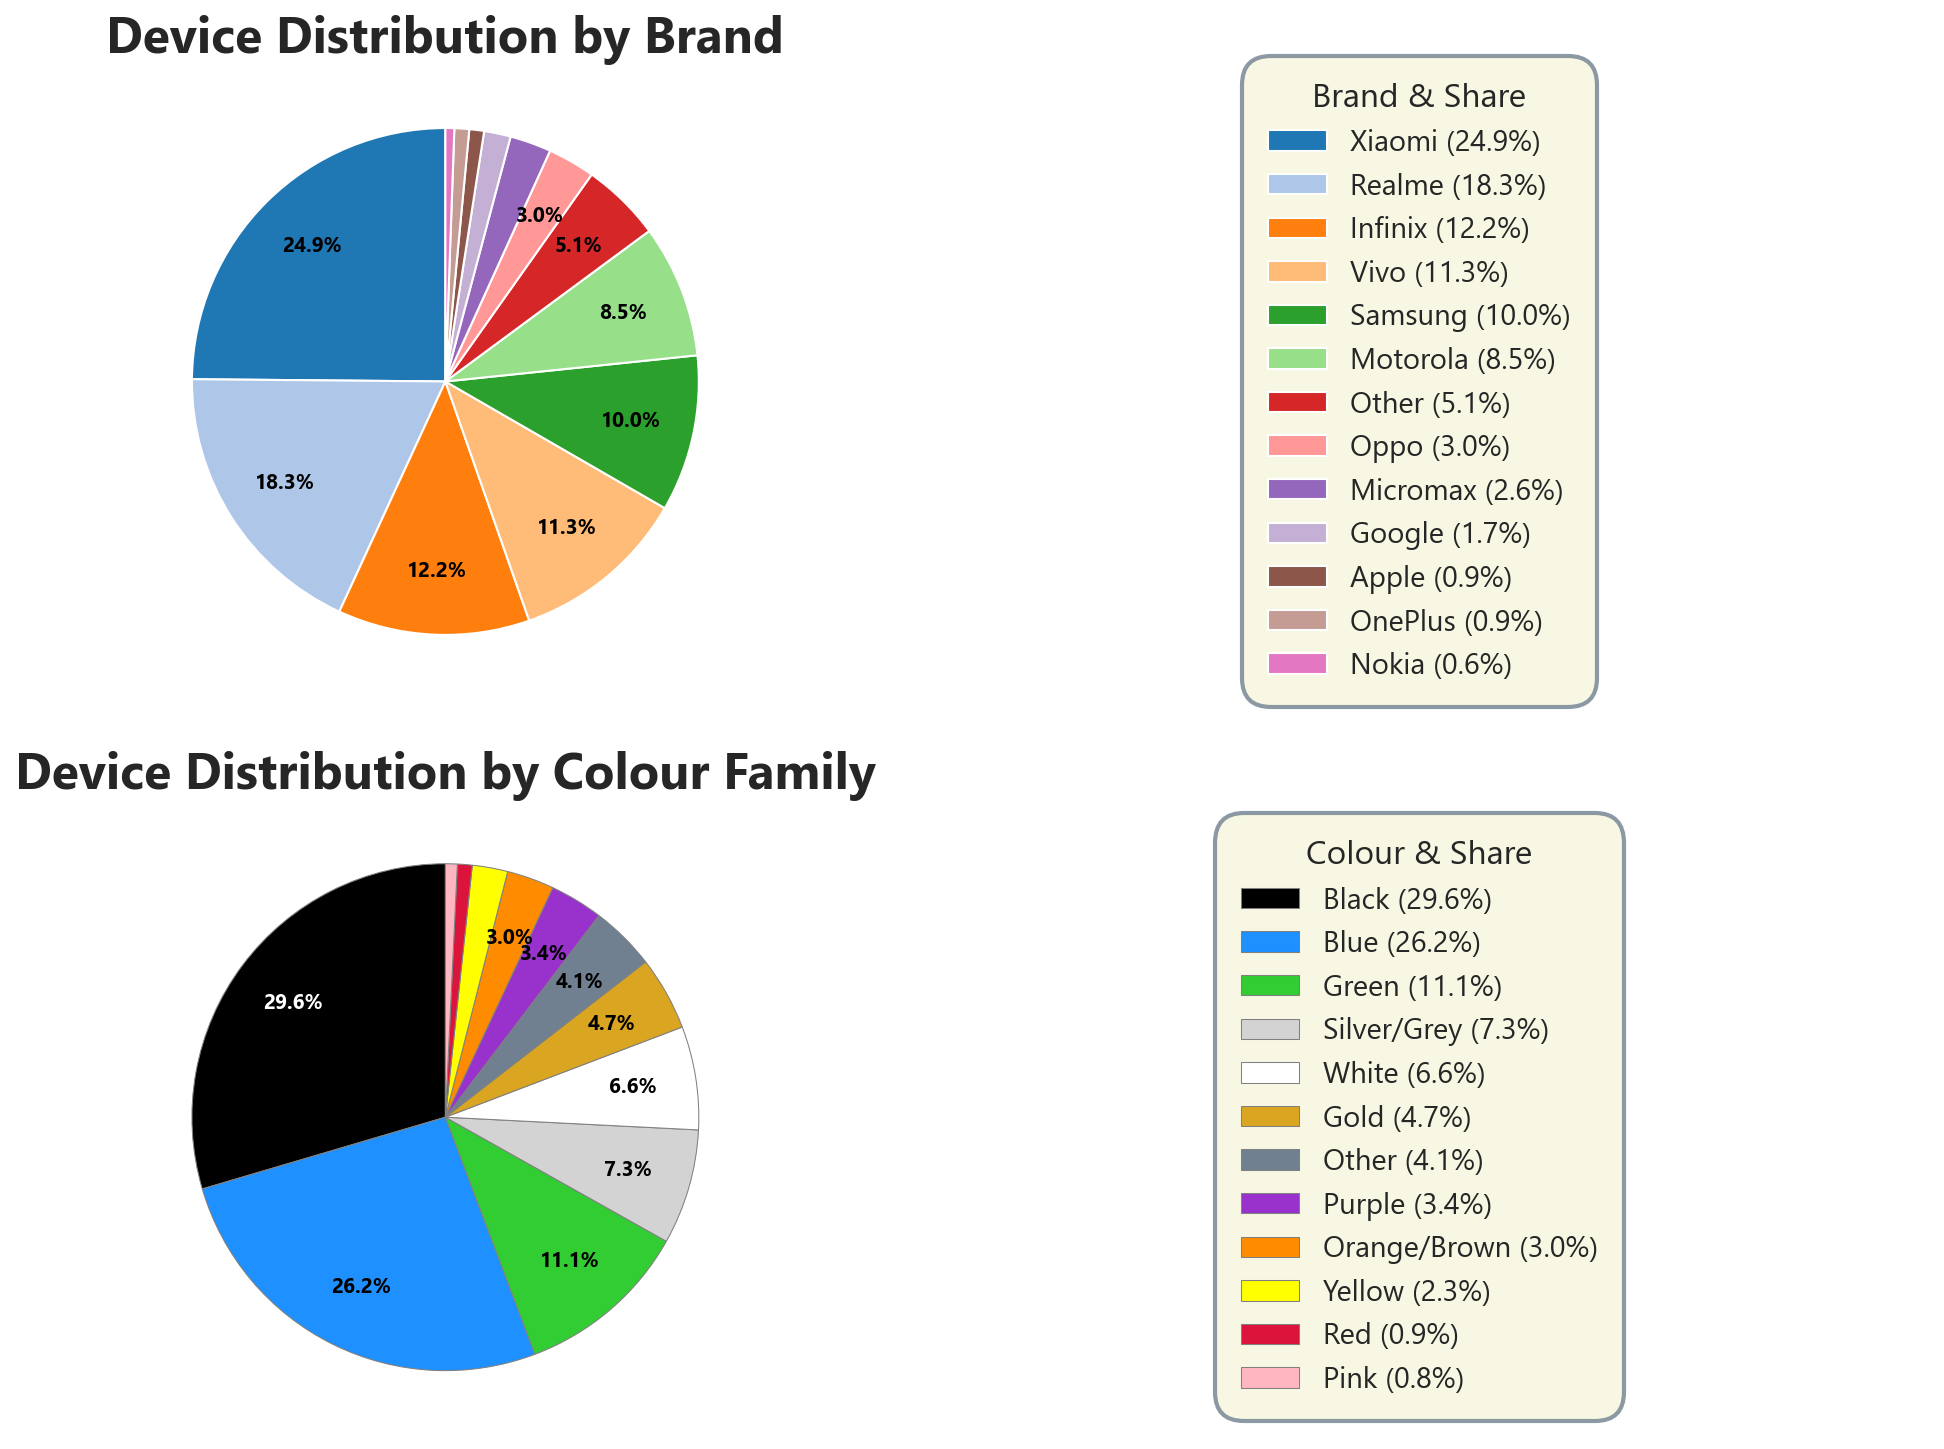

✅ Success: Pie charts generated with dynamic text coloring.


In [21]:
#   Create a 2x2 grid for pie chart

fig, axes = plt.subplots(2, 2, figsize=(14, 10), gridspec_kw={'width_ratios': [1.1, 1]})

def autopct_filter(pct):
    return f'{pct:.1f}%' if pct > 3 else ''

#   Plot1: Brand Distribution
model_dist = df_sanitized['Model_Category'].value_counts()
brand_palette = sns.color_palette('tab20', n_colors=len(model_dist))

total_brands = model_dist.sum()
brand_legend_labels = [f"{brand} ({count/total_brands*100:.1f}%)" for brand, count in model_dist.items()]

wedges1, _, autotexts1 = axes[0, 0].pie(model_dist.values, autopct=autopct_filter,colors=brand_palette, startangle=90, pctdistance=0.75,wedgeprops=dict(edgecolor='white', linewidth=1),textprops=dict(fontweight='bold', fontsize=10, color='black'))

axes[0, 0].set_title('Device Distribution by Brand', fontweight='bold', fontsize=24,va='center');axes[0, 1].axis('off') 
upper_axes=axes[0, 1].legend(wedges1, brand_legend_labels, title='Brand & Share',loc='center', fontsize=14, title_fontsize=16, frameon=True)
upper_axes.get_frame().set_facecolor('beige');upper_axes.get_frame().set_edgecolor('slategray');upper_axes.get_frame().set_linewidth(2);upper_axes.get_frame().set_boxstyle('round,pad=0.5,rounding_size=1.0')

#   Plot2: Colour Distribution
colour_dist = df_sanitized['Colour_Category'].value_counts()

total_colours = colour_dist.sum()
colour_legend_labels = [f"{colour} ({count/total_colours*100:.1f}%)" for colour, count in colour_dist.items()]

colour_palette_map = {'Black': 'black', 'Blue': 'dodgerblue', 'Green': 'limegreen', 'Silver/Grey': 'lightgrey','White': 'white', 'Gold': 'goldenrod', 'Red': 'crimson', 'Purple': 'darkorchid','Pink': 'lightpink', 'Yellow': 'yellow', 'Orange/Brown': 'darkorange', 'Other': 'slategray'}
mapped_colors = [colour_palette_map.get(cat, '#CCCCCC') for cat in colour_dist.index]

wedges2, texts2, autotexts2 = axes[1, 0].pie(colour_dist.values, autopct=autopct_filter,colors=mapped_colors, startangle=90, pctdistance=0.75,wedgeprops=dict(edgecolor='gray', linewidth=0.5),textprops=dict(fontweight='bold', fontsize=10) )

for i, autotext in enumerate(autotexts2):
    category_name = colour_dist.index[i]
    if category_name == 'Black':
        autotext.set_color('white')
    else:
        autotext.set_color('black')

axes[1, 0].set_title('Device Distribution by Colour Family', fontweight='bold',fontsize=24,va='center');axes[1, 1].axis('off') 
lower_axes = axes[1, 1].legend(wedges2, colour_legend_labels, title='Colour & Share',loc='center', fontsize=14, title_fontsize=16, frameon=True)
lower_axes.get_frame().set_facecolor('beige');lower_axes.get_frame().set_edgecolor('slategray');lower_axes.get_frame().set_linewidth(2);lower_axes.get_frame().set_boxstyle('round,pad=0.5,rounding_size=1.0')

plt.tight_layout();plt.savefig('Assets/univariate_pie_categories.png', dpi=150, bbox_inches='tight');plt.show();
print("✅ Success: Pie charts generated with dynamic text coloring.")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Brand & Colour Distribution:**
- Xiaomi dominates the dataset at 24.9% of devices, followed by Realme (18.3%) and Infinix (12.2%) — together these three budget-to-mid-range Indian-market brands account for over half the dataset.
- Premium global brands are minimally represented — Samsung (10%), Apple/iPhone, and Google together make up a small fraction.
- Black (29.6%) and Blue (26.2%) together account for over 56% of all devices — by far the most common colour choices, consistent with these being safe, universally marketable smartphone colours.
- Niche colours (Pink, Red, Yellow) each represent under 3% of devices — confirming colour is a minor differentiator rather than a meaningful price or demand driver in this market.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>

<div style="margin-left: 20px; max-width: 90%">

### 📌 Univariate Analysis — Numerical Features

<div style="margin-left: 20px; max-width: 90%">

 Now we inspect each numerical column individually. This gives us a baseline understanding of each feature's distribution, spread, and potential data quality issues — and directly informs the outlier detection step that follows.

The seven numerical features are visualised as histograms (with skewness and kurtosis annotated) and box plots. Together, these two views reveal the shape of each distribution and flag any columns containing suspicious extreme values.

</div>

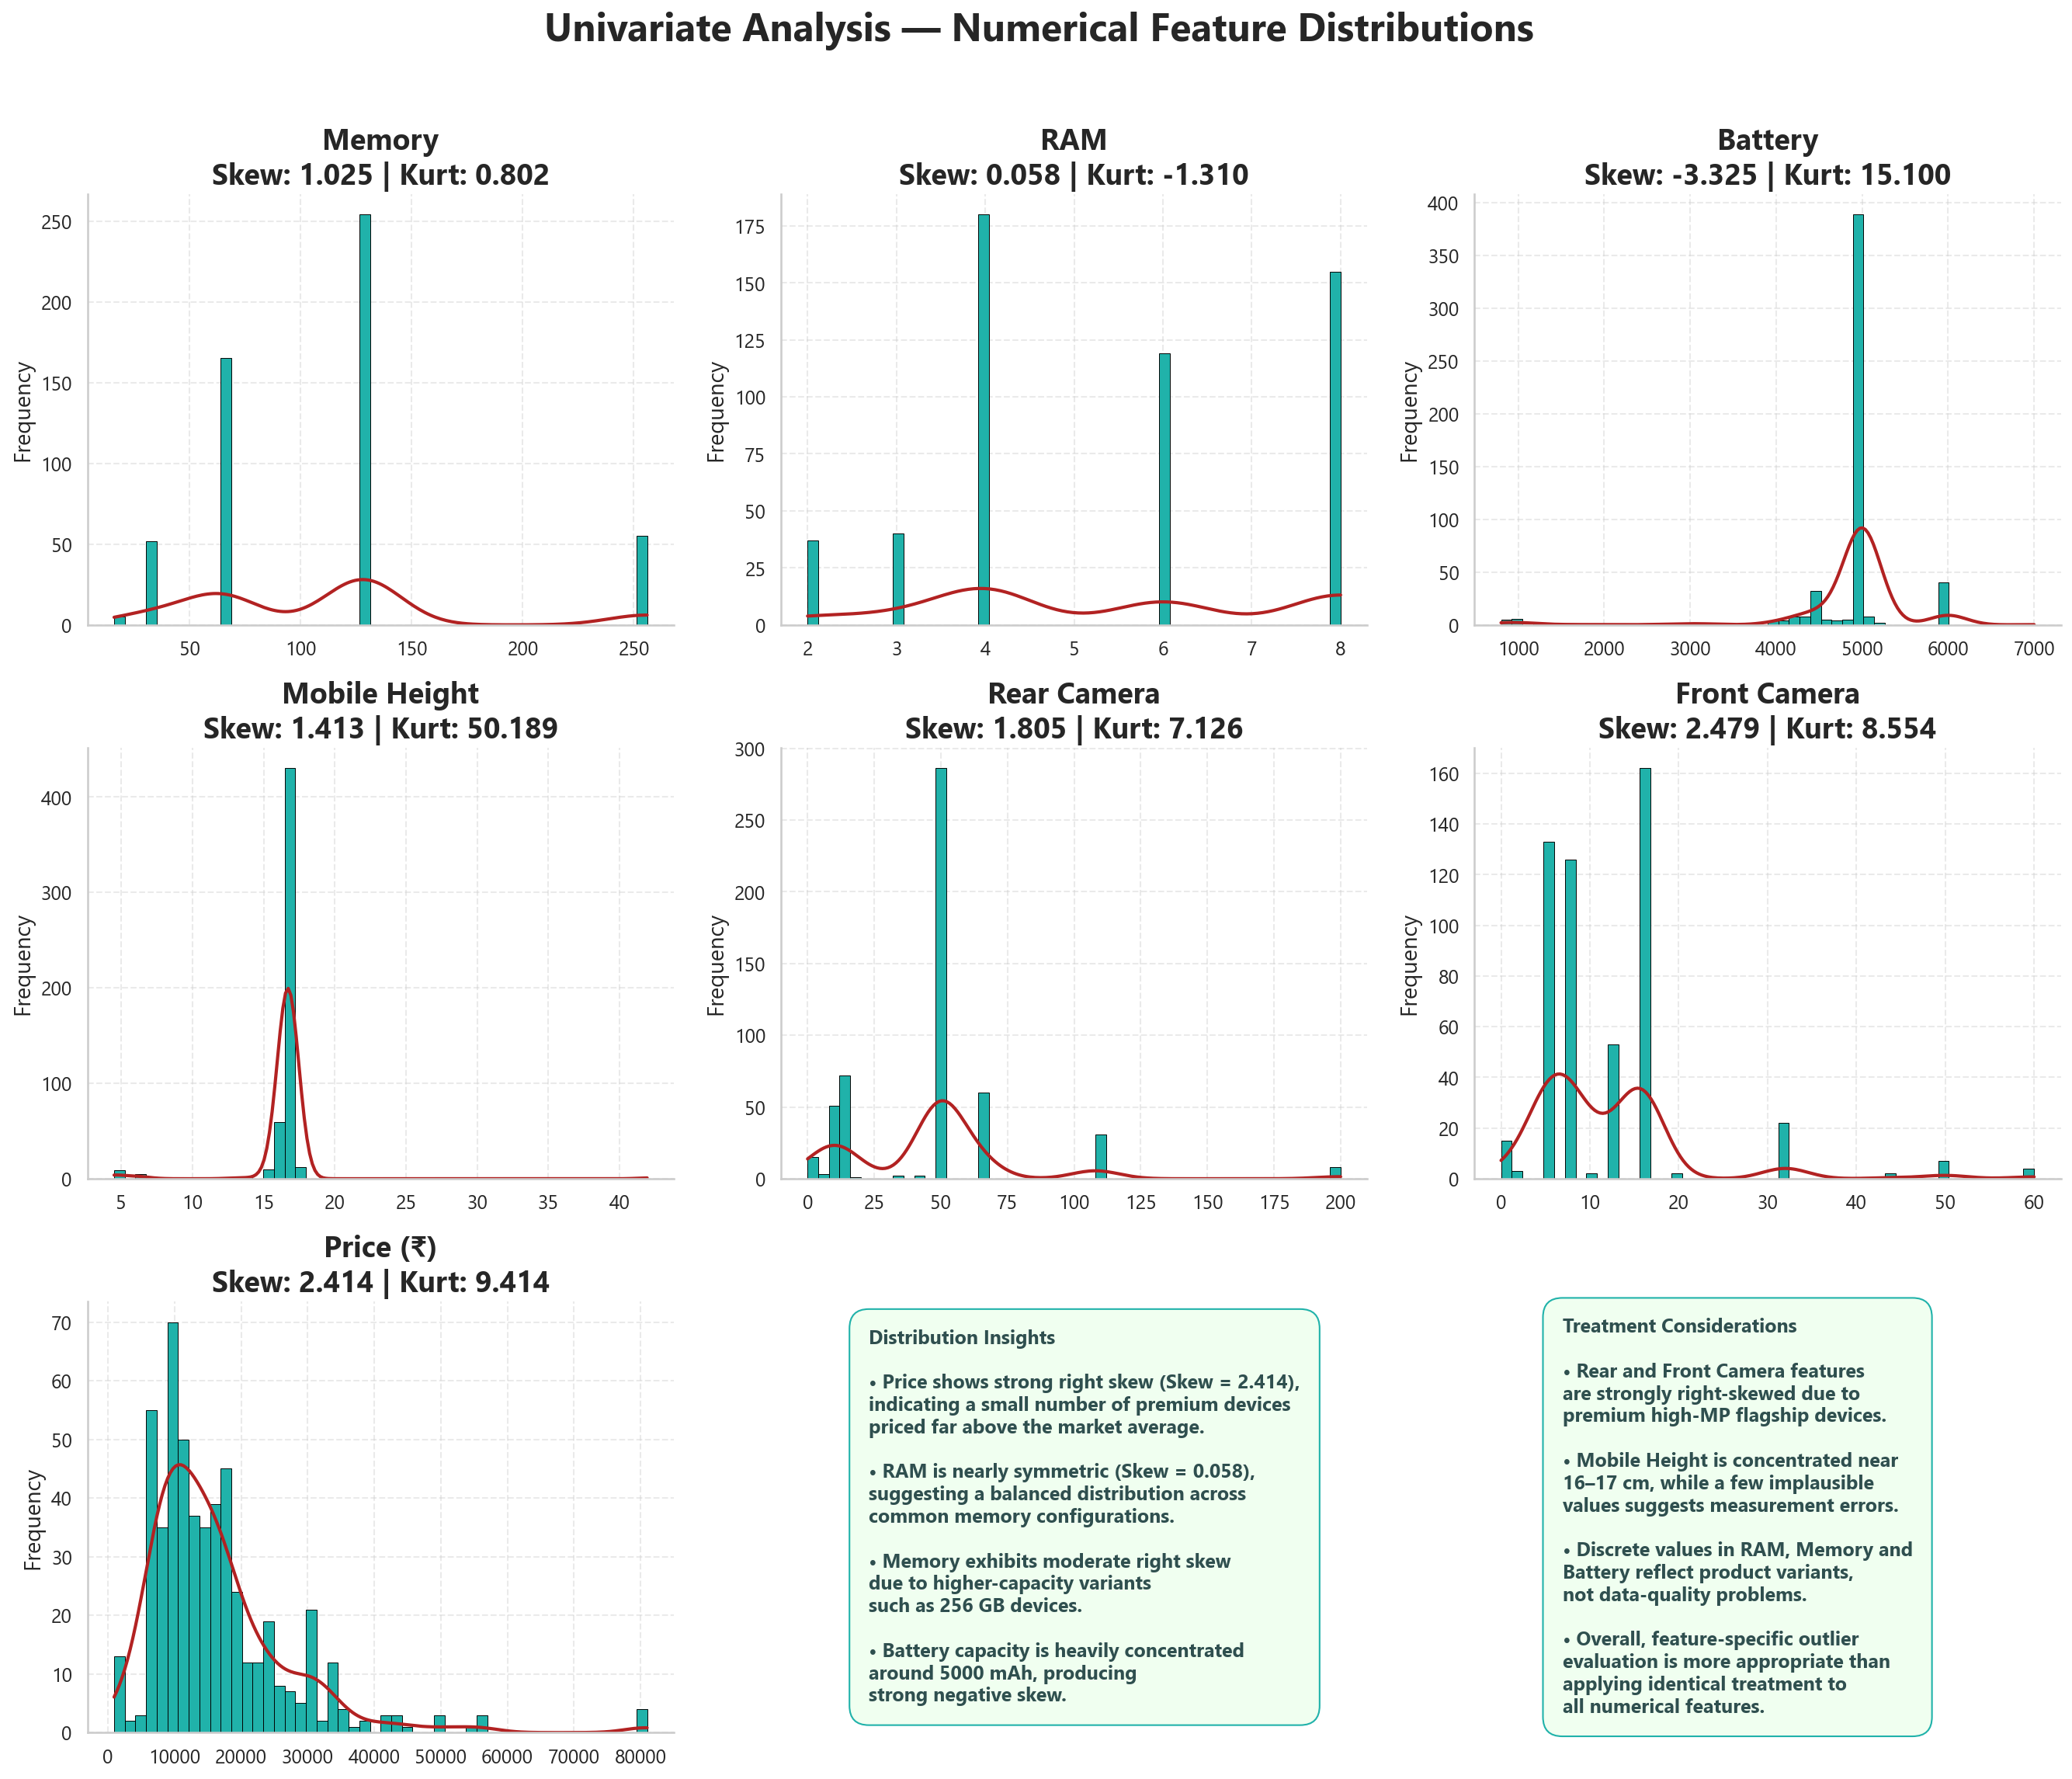


✅ Success: Univariate numerical histogram plotting complete with insights.


In [22]:
#   Univariate Analysis — Numerical Feature Distributions (Before Treatment)

numerical_cols = (df_sanitized.select_dtypes(include="number").drop(columns=["AI Lens"], errors="ignore").columns.tolist())
title_cols = []
for col in numerical_cols:
    if col == "Price":
        title_cols.append("Price (₹)")
    else:
        title_cols.append(col.replace("_mAh", "").replace("_MP", "").replace("_", " "))
fig, axes = plt.subplots(3, 3, figsize=(18, 15));fig.suptitle('Univariate Analysis — Numerical Feature Distributions', fontweight='bold', fontsize=24, y=1.02);fig.subplots_adjust(wspace=0.5, hspace=0.6);axes= axes.flatten()

for i, (ncol,tcol) in enumerate(zip(numerical_cols,title_cols)):
    before_values = df_sanitized[ncol].dropna()
    sk_val, kt_val = skew(before_values), kurtosis(before_values)
    sns.histplot(before_values, kde=True, ax=axes[i], color='firebrick', facecolor='lightseagreen', bins=50, edgecolor='black', line_kws={'linewidth': 2})
    axes[i].set_title(f'{tcol}\nSkew: {sk_val:.3f} | Kurt: {kt_val:.3f}', fontweight='bold', fontsize=18);axes[i].set_xlabel('');axes[i].set_ylabel('Frequency');axes[i].grid(True, linestyle='--', alpha=0.4)

axes[7].axis('off');axes[8].axis('off') 

insights_part1 = ("Distribution Insights\n\n• Price shows strong right skew (Skew = 2.414),\nindicating a small number of premium devices\npriced far above the market average.\n\n• RAM is nearly symmetric (Skew = 0.058),\nsuggesting a balanced distribution across\ncommon memory configurations.\n\n• Memory exhibits moderate right skew \ndue to higher-capacity variants\nsuch as 256 GB devices.\n\n• Battery capacity is heavily concentrated\naround 5000 mAh, producing\nstrong negative skew.")
insights_part2 = ("Treatment Considerations\n\n• Rear and Front Camera features\nare strongly right-skewed due to\npremium high-MP flagship devices.\n\n• Mobile Height is concentrated near \n16–17 cm, while a few implausible \nvalues suggests measurement errors.\n\n• Discrete values in RAM, Memory and\nBattery reflect product variants,\nnot data-quality problems.\n\n• Overall, feature-specific outlier\nevaluation is more appropriate than\napplying identical treatment to\nall numerical features.")

axes[7].text(0.15, 0.5, insights_part1, color='darkslategray',fontsize=12, va='center',ha='left',weight='bold',bbox=dict(boxstyle='round,pad=1', facecolor='honeydew',edgecolor='lightseagreen'))
axes[8].text(0.15, 0.5, insights_part2, color='darkslategray',fontsize=12, va='center',ha='left',weight='bold',bbox=dict(boxstyle='round,pad=1', facecolor='honeydew',edgecolor='lightseagreen'))
plt.tight_layout();plt.savefig('Assets/univariate_histogram_before.png', dpi=150, bbox_inches='tight');plt.show()
print("\n✅ Success: Univariate numerical histogram plotting complete with insights.")

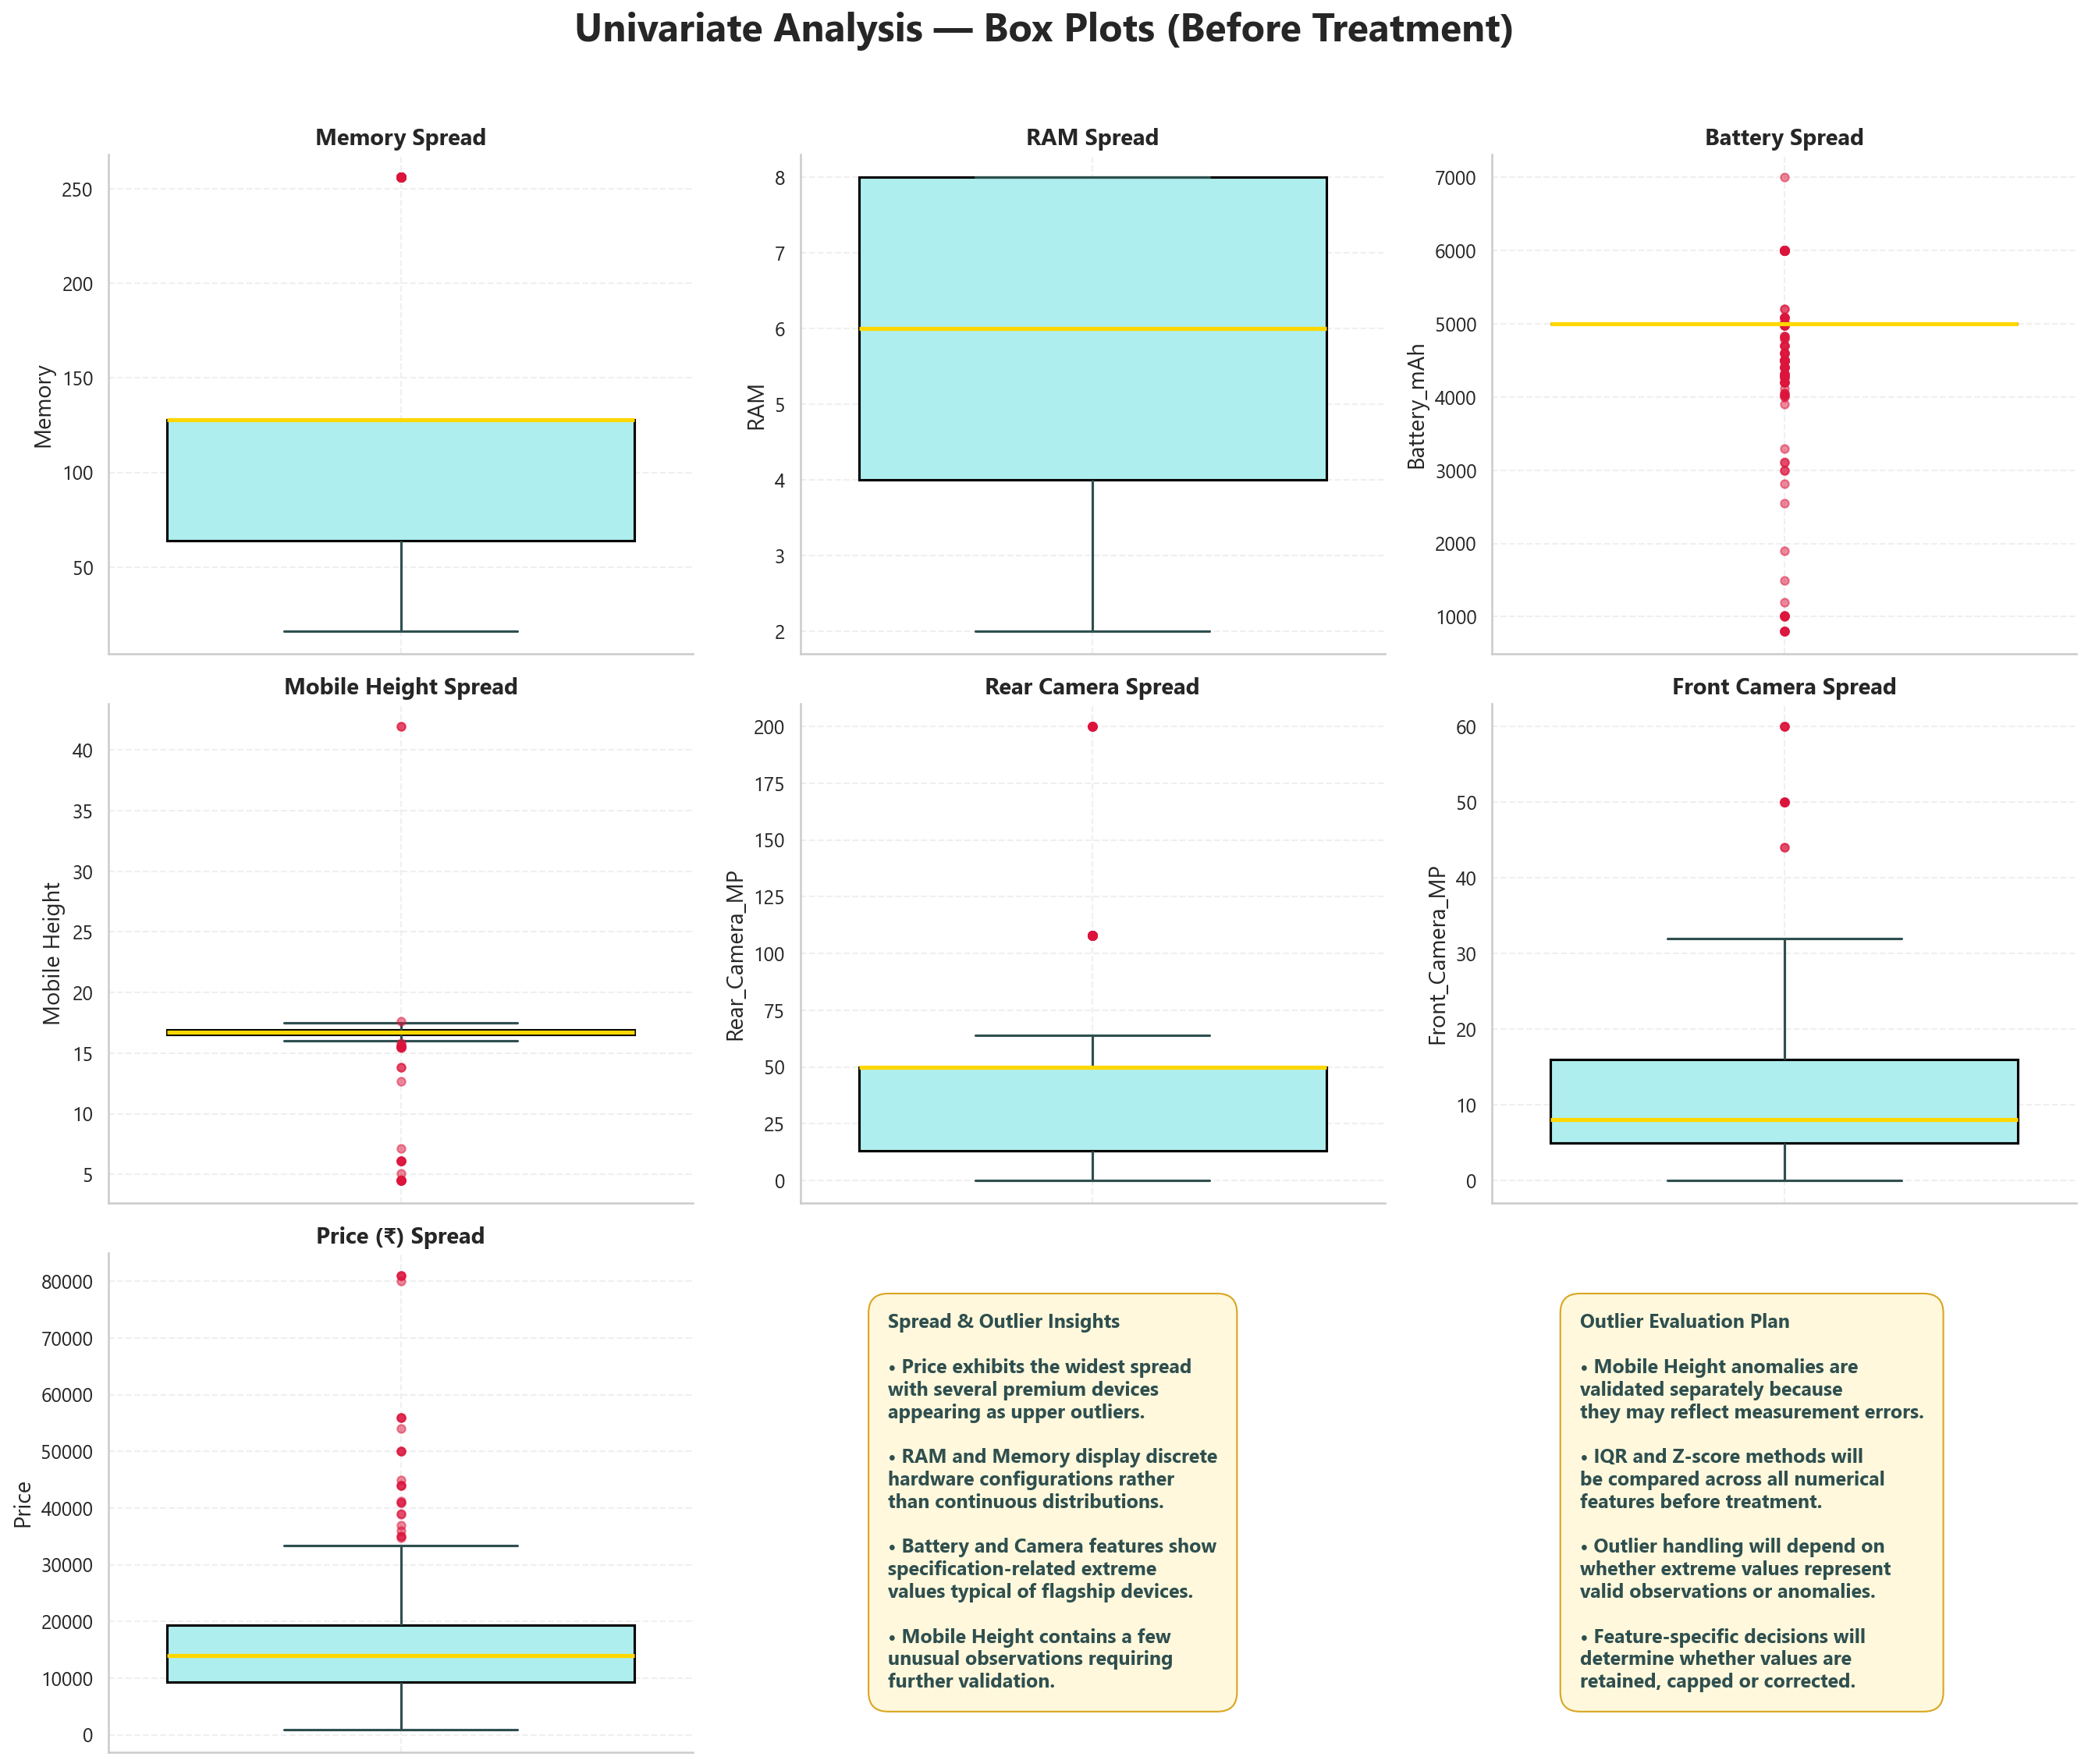

✅ Success: Univariate numerical box plot generated with insights.


In [23]:
#   Univariate Analysis — Box Plots (Before Treatment)
numerical_cols = (df_sanitized.select_dtypes(include="number").drop(columns=["AI Lens"], errors="ignore").columns.tolist())
title_cols = []
for col in numerical_cols:
    if col == "Price":
        title_cols.append("Price (₹)")
    else:
        title_cols.append(col.replace("_mAh", "").replace("_MP", "").replace("_", " "))
fig, axes = plt.subplots(3, 3, figsize=(18, 15));fig.suptitle('Univariate Analysis — Box Plots (Before Treatment)', fontweight='bold', fontsize=24, y=1.02);fig.subplots_adjust(wspace=0.5, hspace=0.6);axes= axes.flatten()

for i,(ncol,tcol) in enumerate(zip(numerical_cols,title_cols)):
    before_values = df_sanitized[ncol].dropna()
    custom_box = dict(facecolor='paleturquoise', edgecolor='black', linewidth=1.5);custom_whisker = dict(color='darkslategray', linewidth=1.5);custom_cap = dict(color='darkslategray', linewidth=1.5);custom_median = dict(color='gold', linewidth=2.5);custom_fliers = dict(marker='o', markerfacecolor='crimson', markeredgecolor='crimson', markersize=5, alpha=0.5)
    sns.boxplot(y=before_values,ax=axes[i],boxprops=custom_box, whiskerprops=custom_whisker,flierprops=custom_fliers,medianprops=custom_median,capprops=custom_cap)
    axes[i].set_title(f'{tcol} Spread', fontsize=14, weight='bold');axes[i].grid(True, linestyle='--', alpha=0.3);axes[i].set_xlabel('');axes[i].set_ylabel(f'{ncol}')

axes[7].axis('off');axes[8].axis('off') 

insights_part1 = ("Spread & Outlier Insights\n\n• Price exhibits the widest spread\nwith several premium devices\nappearing as upper outliers.\n\n• RAM and Memory display discrete\nhardware configurations rather\nthan continuous distributions.\n\n• Battery and Camera features show\nspecification-related extreme\nvalues typical of flagship devices.\n\n• Mobile Height contains a few\nunusual observations requiring\nfurther validation.")
insights_part2 = ("Outlier Evaluation Plan\n\n• Mobile Height anomalies are\nvalidated separately because\nthey may reflect measurement errors.\n\n• IQR and Z-score methods will\nbe compared across all numerical\nfeatures before treatment.\n\n• Outlier handling will depend on\nwhether extreme values represent\nvalid observations or anomalies.\n\n• Feature-specific decisions will\ndetermine whether values are\nretained, capped or corrected.")

axes[7].text(0.15, 0.5, insights_part1, color='darkslategray',fontsize=12, va='center',ha='left',weight='bold',bbox=dict(boxstyle='round,pad=1', facecolor='cornsilk',edgecolor='goldenrod'))
axes[8].text(0.15, 0.5, insights_part2, color='darkslategray',fontsize=12, va='center',ha='left',weight='bold',bbox=dict(boxstyle='round,pad=1', facecolor='cornsilk',edgecolor='goldenrod'))
plt.tight_layout();plt.savefig('Assets/univariate_boxplot_before.png', dpi=150, bbox_inches='tight');plt.show()
print("✅ Success: Univariate numerical box plot generated with insights.")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Numerical Feature Distributions & Spread:**

- **Price** shows the strongest right skew (2.414) with extreme kurtosis (9.414) — a small number of premium devices pull the upper tail significantly, confirming outlier treatment is required.
- **Battery_mAh** shows a strong negative skew (−3.325) with very high kurtosis (15.100) — the distribution is heavily concentrated around 5,000 mAh with a long lower tail of older/budget devices.
- **Mobile Height** shows unusually high kurtosis (50.189) — almost all devices cluster tightly around 16–17 cm, with a handful of physically implausible values visible at both extremes. These will be corrected through median imputation.
- **RAM and Memory** show discrete step distributions — not continuous, so standard outlier detection is less meaningful here. These values reflect real hardware tiers.
- **Rear and Front Camera MPs** are both right-skewed — majority of devices have lower MP counts, with a visible tail of high-resolution flagship devices.
- **AI Lens** is stored as a numeric (0/1) field but represents a binary categorical feature rather than a continuous measurement. Since its standalone frequency distribution provides limited analytical value, it is excluded from the numerical univariate analysis and is instead examined directly against the target variable `Price` in the **Bivariate Analysis** section.

</div>

In [24]:
#   Capture before-treatment stats
before_price_skew  = skew(df_sanitized['Price'])
before_price_kurt  = kurtosis(df_sanitized['Price'])
before_height_skew = skew(df_sanitized['Mobile Height'])
before_height_kurt = kurtosis(df_sanitized['Mobile Height'])
print("✅ Success: Skewness & Kurtosis captured before treatment for 'Mobile Height' and 'Price'.")

✅ Success: Skewness & Kurtosis captured before treatment for 'Mobile Height' and 'Price'.


<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>
<div style="margin-left: 20px;max-width: 90%">

### 📌 Mobile Height Validation & Correction

<div style="margin-left: 20px;max-width: 90%">

A data quality audit was conducted on the Mobile Height feature prior to feature engineering.

While the majority of devices fell within the expected smartphone height range, a small subset contained physically unrealistic measurements that were inconsistent with the overall distribution.

To maintain data integrity and preserve all observations, anomalous values were identified and corrected before proceeding with downstream analysis.

</div>
</div>

In [25]:
#   Mobile Height Validation & Correction

height_anomalies = df_sanitized[(df_sanitized['Mobile Height'] < 10) |(df_sanitized['Mobile Height'] > 25)].copy()
anomaly_table = (height_anomalies[['Model', 'Mobile Height']].sort_values('Mobile Height'))
kpi_content = f"""
    <div style='display:flex; gap:20px; justify-content:center;'><div style='padding:15px; border:1px solid #555;border-radius:8px; width:220px;text-align:center;'>
        <h3 style='margin:0;color:#4FB9AF;'>{len(height_anomalies)}</h3><p>Anomalies Detected</p></div>
    <div style='padding:15px; border:1px solid #555;border-radius:8px; width:220px;text-align:center;'><h3 style='margin:0;color:#4FB9AF;'>531</h3><p>Records Retained</p></div>
    <div style='padding:15px; border:1px solid #555;border-radius:8px; width:220px;text-align:center;'><h3 style='margin:0;color:#4FB9AF;'>Median</h3><p>Imputation Strategy</p></div></div>
"""
html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px;border: 1px solid #555; border-radius: 6px;background: rgba(128,128,128,0.05);">
    <h2 style="margin:0; letter-spacing:1px; color:#4FB9AF;">MOBILE HEIGHT VALIDATION<span style="opacity:0.5; margin:0 10px;">|</span>
        <i style="opacity:0.8; font-weight:normal; font-size:0.9em;">Anomalous Records</i>
    </h2>
</div>
<div style="display:flex; justify-content:center;">
'''
html_content += (f'<div style="display:flex; justify-content:center;">{anomaly_table.to_html(index=True, border=1, justify="center")}</div>')

display(HTML(kpi_content))
display(HTML(html_content))

,Model,Mobile Height
95,Micromax IN 2C,4.500
113,micromax,4.500
115,micromax 1,4.500
151,micromax 2,4.500
241,redmi mono,4.500
178,micromax1,4.500
177,micromax,4.500
242,redmi min,4.570
148,micromax 3,5.080
152,micromax 3,6.100


In [26]:
#   Replace anomalous values with median

valid_height_median = df_sanitized.loc[
    (df_sanitized['Mobile Height'] >= 10) &(df_sanitized['Mobile Height'] <= 25),'Mobile Height'].median()
anomaly_mask = ((df_sanitized['Mobile Height'] < 10) |(df_sanitized['Mobile Height'] > 25))
#median_mobile_height = valid_height_median
df_sanitized['Mobile Height'] = (df_sanitized['Mobile Height'].mask(anomaly_mask, valid_height_median))
print("✅ Success: Mobile Height validation completed.")

✅ Success: Mobile Height validation completed.


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Mobile Height Validation**

- Quality inspection identified **17 anomalous Mobile Height values** outside the plausible smartphone dimension range.
- Most devices were concentrated between approximately **12 cm and 18 cm**, while a small subset contained measurements below **10 cm** and one extreme value of **41.94 cm**.
- Because the original measurement source could not be independently verified, these observations were treated as data quality anomalies rather than unit-conversion errors.
- To preserve all **531 records**, anomalous values were replaced using the **median height (16.76 cm)** calculated from valid observations.
- This approach improved feature consistency while avoiding unsupported assumptions regarding the original units of measurement.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>

<div style="margin-left: 20px; max-width: 90%">

### 📌 Outlier Detection & Treatment

<div style="margin-left: 20px; max-width: 90%">

Building on the distributions observed in the univariate analysis, we now formally detect and address outliers across all seven numerical features. The approach follows a two-stage process:

1. **Statistical Outlier Detection** — applying IQR and Z-Score methods to flag extreme values across all numerical features
2. **Treatment Decisions** — deciding whether to cap, impute, or retain flagged values based on context and magnitude

Only features where treatment is analytically justified will be modified. Flagged values that represent genuine market observations — such as premium-priced devices or high-specification phones — are retained as real data points.

</div>
</div>

In [27]:
#   Outlier Detection: IQR Method — All Numerical Features

numerical_cols = (df_sanitized.select_dtypes(include="number").drop(columns=["AI Lens", "Mobile Height"]).columns.tolist())

title_cols = [];units = []

for col in numerical_cols:
    if col == "Price":
        title_cols.append("Price (₹)");units.append("₹")
    elif col == "Battery_mAh":
        title_cols.append("Battery");units.append("mAh")
    elif col in ["Rear_Camera_MP", "Front_Camera_MP"]:
        title_cols.append(col.replace("_MP", "").replace("_", " "));units.append("MP")
    elif col in ["Memory", "RAM"]:
        title_cols.append(col);units.append("GB")

tables_html = ''
for ncol, tcol, unit in zip(numerical_cols, title_cols, units):
    before_iqr_values = df_sanitized[ncol].dropna()
    Q1,Q3 = before_iqr_values.quantile(0.25),before_iqr_values.quantile(0.75)
    IQR = Q3 - Q1
    iqr_lower = Q1 - 1.5 * IQR
    iqr_upper = Q3 + 1.5 * IQR
    iqr_outliers   = df_sanitized[(df_sanitized[ncol] < iqr_lower) | (df_sanitized[ncol] > iqr_upper)]

    if unit == '₹':
        lower_fmt = f'₹{iqr_lower:,.0f}'
        upper_fmt = f'₹{iqr_upper:,.0f}'
        iqr_fmt   = f'{IQR:,.0f}'
    elif unit == 'cm':
        lower_fmt = f'{iqr_lower:,.2f} cm'
        upper_fmt = f'{iqr_upper:,.2f} cm'
        iqr_fmt   = f'{IQR:,.0f}'      
    else:
        lower_fmt = f'{iqr_lower:,.1f} {unit}'
        upper_fmt = f'{iqr_upper:,.1f} {unit}'
        iqr_fmt   = f'{IQR:.1f}'

    tables_html += f'''
    <div style="background-color: #1E1E1E; border: 1px solid #333;border-radius: 8px; padding: 16px 20px; width: 260px;color: #CCCCCC; font-size: 0.92em;">
        <div style="color: #4FB9AF; font-weight: bold; font-size: 1.05em;margin-bottom: 12px;">📌 {tcol}</div>
        <table style="width: 100%; border-collapse: collapse;">
            <tr><td style="padding: 7px 0; text-align: left;border-bottom: 1px solid #333;">IQR:</td><td style="padding: 7px 0; text-align: right;border-bottom: 1px solid #333;">{iqr_fmt}</td></tr>
            <tr><td style="padding: 7px 0; text-align: left;border-bottom: 1px solid #333;">Lower Bound:</td><td style="padding: 7px 0; text-align: right;border-bottom: 1px solid #333;">{lower_fmt}</td></tr>
            <tr><td style="padding: 7px 0; text-align: left;border-bottom: 1px solid #333;">Upper Bound:</td><td style="padding: 7px 0; text-align: right;border-bottom: 1px solid #333;">{upper_fmt}</td></tr>
            <tr><td style="padding: 7px 0; text-align: left;font-weight: bold; color: #FFFFFF;">Outliers Flagged:</td><td style="padding: 7px 0; text-align: right;font-weight: bold; color: #FFFFFF;">{len(iqr_outliers)} rows</td></tr>
        </table>
    </div>
    '''
    
html_content = f'''
<div style="text-align: center; padding: 12px; margin-bottom: 20px;border: 1px solid #555; border-radius: 6px;background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">IQR METHOD<span style="opacity: 0.5; margin: 0 10px;">|</span>
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Outlier Thresholds — All Numerical Features</i>
    </h2>
</div>
<div style="display: flex; flex-wrap: wrap; justify-content: center;gap: 20px; margin-bottom: 20px;">{tables_html}</div>
'''
display(HTML(html_content))
print("✅ Success: IQR outlier detection complete for all numerical features.")

IQR:,64.0
Lower Bound:,-32.0 GB
Upper Bound:,224.0 GB
Outliers Flagged:,55 rows
IQR:,4.0
Lower Bound:,-2.0 GB
Upper Bound:,14.0 GB
Outliers Flagged:,0 rows
IQR:,0.0
Lower Bound:,"5,000.0 mAh"
Upper Bound:,"5,000.0 mAh"


✅ Success: IQR outlier detection complete for all numerical features.


In [28]:
#   Outlier Detection: Z-Score Method — All Numerical Features

numerical_cols = (df_sanitized.select_dtypes(include="number").drop(columns=["AI Lens", "Mobile Height"]).columns.tolist())

title_cols = [];units = []

for col in numerical_cols:
    if col == "Price":
        title_cols.append("Price (₹)");units.append("₹")
    elif col == "Battery_mAh":
        title_cols.append("Battery");units.append("mAh")
    elif col in ["Rear_Camera_MP", "Front_Camera_MP"]:
        title_cols.append(col.replace("_MP", "").replace("_", " "));units.append("MP")
    elif col in ["Memory", "RAM"]:
        title_cols.append(col);units.append("GB")

tables_html = ''
for ncol, tcol, unit in zip(numerical_cols, title_cols, units):
    vals        = df_sanitized[ncol].dropna()
    z_scores    = zscore(vals)
    z_outliers  = df_sanitized.loc[vals.index][abs(z_scores) > 3]
    max_zscore  = abs(z_scores).max()

    if len(z_outliers) > 0:
        min_val,max_val = z_outliers[ncol].min(),z_outliers[ncol].max()
        if unit == '₹':
            range_fmt = f'₹{min_val:,.0f} — ₹{max_val:,.0f}'
        else:
            range_fmt = f'{min_val:,.1f} — {max_val:,.1f} {unit}'
    else:
        range_fmt = 'None'

    tables_html += f'''
    <div style="background-color: #1E1E1E; border: 1px solid #333;border-radius: 8px; padding: 16px 20px; width: 260px;color: #CCCCCC; font-size: 0.92em;">
        <div style="color: #4FB9AF; font-weight: bold; font-size: 1.05em;margin-bottom: 12px;">📌 {tcol}</div>
        <table style="width: 100%; border-collapse: collapse;">
            <tr><td style="padding: 7px 0; text-align: left;border-bottom: 1px solid #333;">Threshold:</td><td style="padding: 7px 0; text-align: right;border-bottom: 1px solid #333;">± 3σ (Empirical Rule)</td></tr>
            <tr><td style="padding: 7px 0; text-align: left;border-bottom: 1px solid #333;">Max Z-Score:</td><td style="padding: 7px 0; text-align: right;border-bottom: 1px solid #333;">{max_zscore:.3f}</td></tr>
            <tr><td style="padding: 7px 0; text-align: left;border-bottom: 1px solid #333;">Flagged Range:</td><td style="padding: 7px 0; text-align: right;border-bottom: 1px solid #333;">{range_fmt}</td></tr>
            <tr><td style="padding: 7px 0; text-align: left;font-weight: bold; color: #FFFFFF;">Outliers Flagged:</td><td style="padding: 7px 0; text-align: right;font-weight: bold; color: #FFFFFF;">{len(z_outliers)} rows</td></tr>
        </table>
    </div>
    '''

html_content = f'''
<div style="text-align: center; padding: 12px; margin-bottom: 20px;border: 1px solid #555; border-radius: 6px;background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">Z-SCORE METHOD<span style="opacity: 0.5; margin: 0 10px;">|</span>
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Outlier Thresholds — All Numerical Features</i>
    </h2>
</div>
<div style="display: flex; flex-wrap: wrap; justify-content: center;gap: 20px; margin-bottom: 20px;">{tables_html}</div>
'''
display(HTML(html_content))
print("✅ Success: Z-Score outlier detection complete for all numerical features.")

Threshold:,± 3σ (Empirical Rule)
Max Z-Score:,2.386
Flagged Range:,None
Outliers Flagged:,0 rows
Threshold:,± 3σ (Empirical Rule)
Max Z-Score:,1.710
Flagged Range:,None
Outliers Flagged:,0 rows
Threshold:,± 3σ (Empirical Rule)
Max Z-Score:,5.324
Flagged Range:,"800.0 — 2,550.0 mAh"


✅ Success: Z-Score outlier detection complete for all numerical features.


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — IQR & Z-Score Outlier Detection:**
- **Memory (IQR: 55 rows, Z-Score: 0 rows)** — Although IQR flags 55 observations, Z-Score detects none. This discrepancy arises because storage capacities occur in discrete tiers (32GB–256GB) rather than continuous values. These observations represent legitimate product specifications rather than anomalous records.
- **RAM (IQR: 0, Z-Score: 0)** — Both methods agree: no outliers. Distribution is clean across discrete tiers. No treatment required.
- **Battery_mAh (IQR: 148 rows, Z-Score: 15 rows)** — The concentration of devices around 5000 mAh causes IQR to flag many observations, whereas Z-Score identifies only 15 statistically extreme values. Manual inspection confirms these values correspond to genuine smartphone specifications rather than data-entry errors. Since they represent valid market offerings, they are retained without treatment despite being statistically flagged.
- **Rear_Camera_MP (IQR: 39, Z-Score: 8)** — Z-Score flags only the single extreme value at 200MP. These are genuine flagship camera specifications. No treatment required.
- **Front_Camera_MP (IQR: 13, Z-Score: 13)** — Both methods agree on 13 rows (44–60MP). These are high-specification flagship devices, not data errors. No treatment required.
- **Price (IQR: 25, Z-Score: 11)** — Both methods confirm extreme upper values (₹49,999–₹80,999). These are genuine premium devices. Rather than removal, a **99th percentile cap** will be applied — preserving the premium segment while controlling the most extreme tail values.

</div>

In [29]:

#   Outlier Treatment — Decision Summary Table

treatment_data = {
    'Feature': ['Memory','RAM','Battery','Rear Camera','Front Camera','Mobile Height','Price (₹)'],
    'IQR Flags': [55,0,148,39,13,'—',25],
    'Z-Score Flags': [0,0,15,8,13,'—',11],
    'Decision': ['☑️ Retained','☑️ Retained','☑️ Retained','☑️ Retained','☑️ Retained','✅ Treated','⏳ Pending'],
    'Justification': ['Valid Storage Configurations','Valid Hardware Specifications','Valid Battery Capacities','Premium Camera Specifications','Premium Camera Specifications','Corrected During Validation','Awaiting 99th Percentile Capping']}

treatment_df = pd.DataFrame(treatment_data)
html_content = '''
            <div style="text-align:center;padding:12px;margin-bottom:25px;border:1px solid #555;border-radius:6px;background:rgba(128,128,128,0.05);">
                <h2 style="margin:0;letter-spacing:1px;color:#4FB9AF;">TREATMENT DECISION<span style="opacity:0.5;margin:0 10px;">|</span>
                    <i style="opacity:0.8;font-weight:normal;font-size:0.9em;">Feature-by-Feature Summary</i>
                </h2>
            </div>
'''
display(HTML(html_content))

def style_status(val):
    val = str(val)
    if "Treated" in val:
        return ("background-color:#163A22;color:#58D68D;font-weight:bold;text-align:center;")
    elif "Retained" in val:
        return ("background-color:#1B2D42;color:#4FD1C5;font-weight:bold;text-align:center;")
    elif "Pending" in val:
        return ("background-color:#4A3412;color:#FFD966;font-weight:bold;text-align:center;")
    return ""

display( treatment_df.style
    .hide(axis="index")
    .set_table_attributes('style="margin:auto; width:90%; border-collapse:collapse;"')
    .set_properties(**{"text-align": "center","font-size": "13px"})
    .set_properties(subset=["Justification"],**{"text-align": "left","font-style":"italic",'padding-right':'200px','white-space':'normal'})
    .set_table_styles([{"selector": "th","props": [("background-color", "#1A1A2E"),("color", "#5DB5C7"),("font-size", "13px"),("text-align", "center")]}])
    .map(style_status,subset=["Decision"]))
print("\n✅ Success: Treatment Decision summary table generated.")    

Feature,IQR Flags,Z-Score Flags,Decision,Justification
Memory,55,0,☑️ Retained,Valid Storage Configurations
RAM,0,0,☑️ Retained,Valid Hardware Specifications
Battery,148,15,☑️ Retained,Valid Battery Capacities
Rear Camera,39,8,☑️ Retained,Premium Camera Specifications
Front Camera,13,13,☑️ Retained,Premium Camera Specifications
Mobile Height,—,—,✅ Treated,Corrected During Validation
Price (₹),25,11,⏳ Pending,Awaiting 99th Percentile Capping



✅ Success: Treatment Decision summary table generated.


In [30]:
#   Apply 99th Percentile Cap for Price

cap_value = df_sanitized['Price'].quantile(0.99)
df_sanitized['Price'] = df_sanitized['Price'].clip(upper=cap_value)
cap_price = df_sanitized['Price'].max().round(0)
print(f"✅ Success: 'Price' capped at 99th percentile: ₹{cap_value:,.0f}")

✅ Success: 'Price' capped at 99th percentile: ₹55,999


In [31]:
#   Treatment Impact — Skewness & Kurtosis Before vs After

after_price_vals  = df_sanitized['Price'].dropna()
after_height_vals = df_sanitized['Mobile Height'].dropna()

comparison_data = [
    {'Feature':'Price (₹)','Treatment':'99th Percentile Cap','Skewness (Before)':round(before_price_skew, 3),'Skewness (After)': round(skew(after_price_vals), 3),'Kurtosis (Before)' : round(before_price_kurt, 3),'Kurtosis (After)': round(kurtosis(after_price_vals), 3),'Value Applied' : f'₹{cap_price}','Rows Affected' : f'{(df_sanitized['Price'] == cap_value).sum()}'},
    {'Feature': 'Mobile Height','Treatment': 'Median Imputation','Skewness (Before)' : round(before_height_skew, 3),'Skewness (After)': round(skew(after_height_vals), 3),'Kurtosis (Before)' : round(before_height_kurt, 3),'Kurtosis (After)'  : round(kurtosis(after_height_vals), 3),'Value Applied' : f'{valid_height_median:.2f} cm','Rows Affected' : len(height_anomalies)}
    ]
compare_df = pd.DataFrame(comparison_data)

html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px;border: 1px solid #555; border-radius: 6px;background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">TREATMENT IMPACT<span style="opacity: 0.5; margin: 0 10px;">|</span>
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Skewness & Kurtosis — Before vs After</i>
    </h2>
</div>
'''
display(HTML(html_content))
display(compare_df.style
    .hide(axis="index")
    .set_table_attributes('style="margin:auto; width:90%; border-collapse:collapse;"')
    .set_properties(**{'text-align': 'center', 'font-size': '13px'})
    .set_properties(subset=['Skewness (After)', 'Kurtosis (After)'],**{'font-weight': 'bold','color': '#12CC12'})
    .set_table_styles([{'selector': 'th','props': [('background-color', '#1a1a2e'), ('color', '#5DB5C7'),('font-size', '13px'), ('text-align', 'center')]}])
    .format({'Skewness (Before)': '{:.3f}','Skewness (After)' : '{:.3f}','Kurtosis (Before)': '{:.3f}','Kurtosis (After)' : '{:.3f}',}))
print("✅ Success: Skewness & Kurtosis comparison table generated.")

Feature,Treatment,Skewness (Before),Skewness (After),Kurtosis (Before),Kurtosis (After),Value Applied,Rows Affected
Price (₹),99th Percentile Cap,2.414,1.631,9.414,3.366,₹55999,7
Mobile Height,Median Imputation,1.413,-3.973,50.189,32.156,16.76 cm,17


✅ Success: Skewness & Kurtosis comparison table generated.


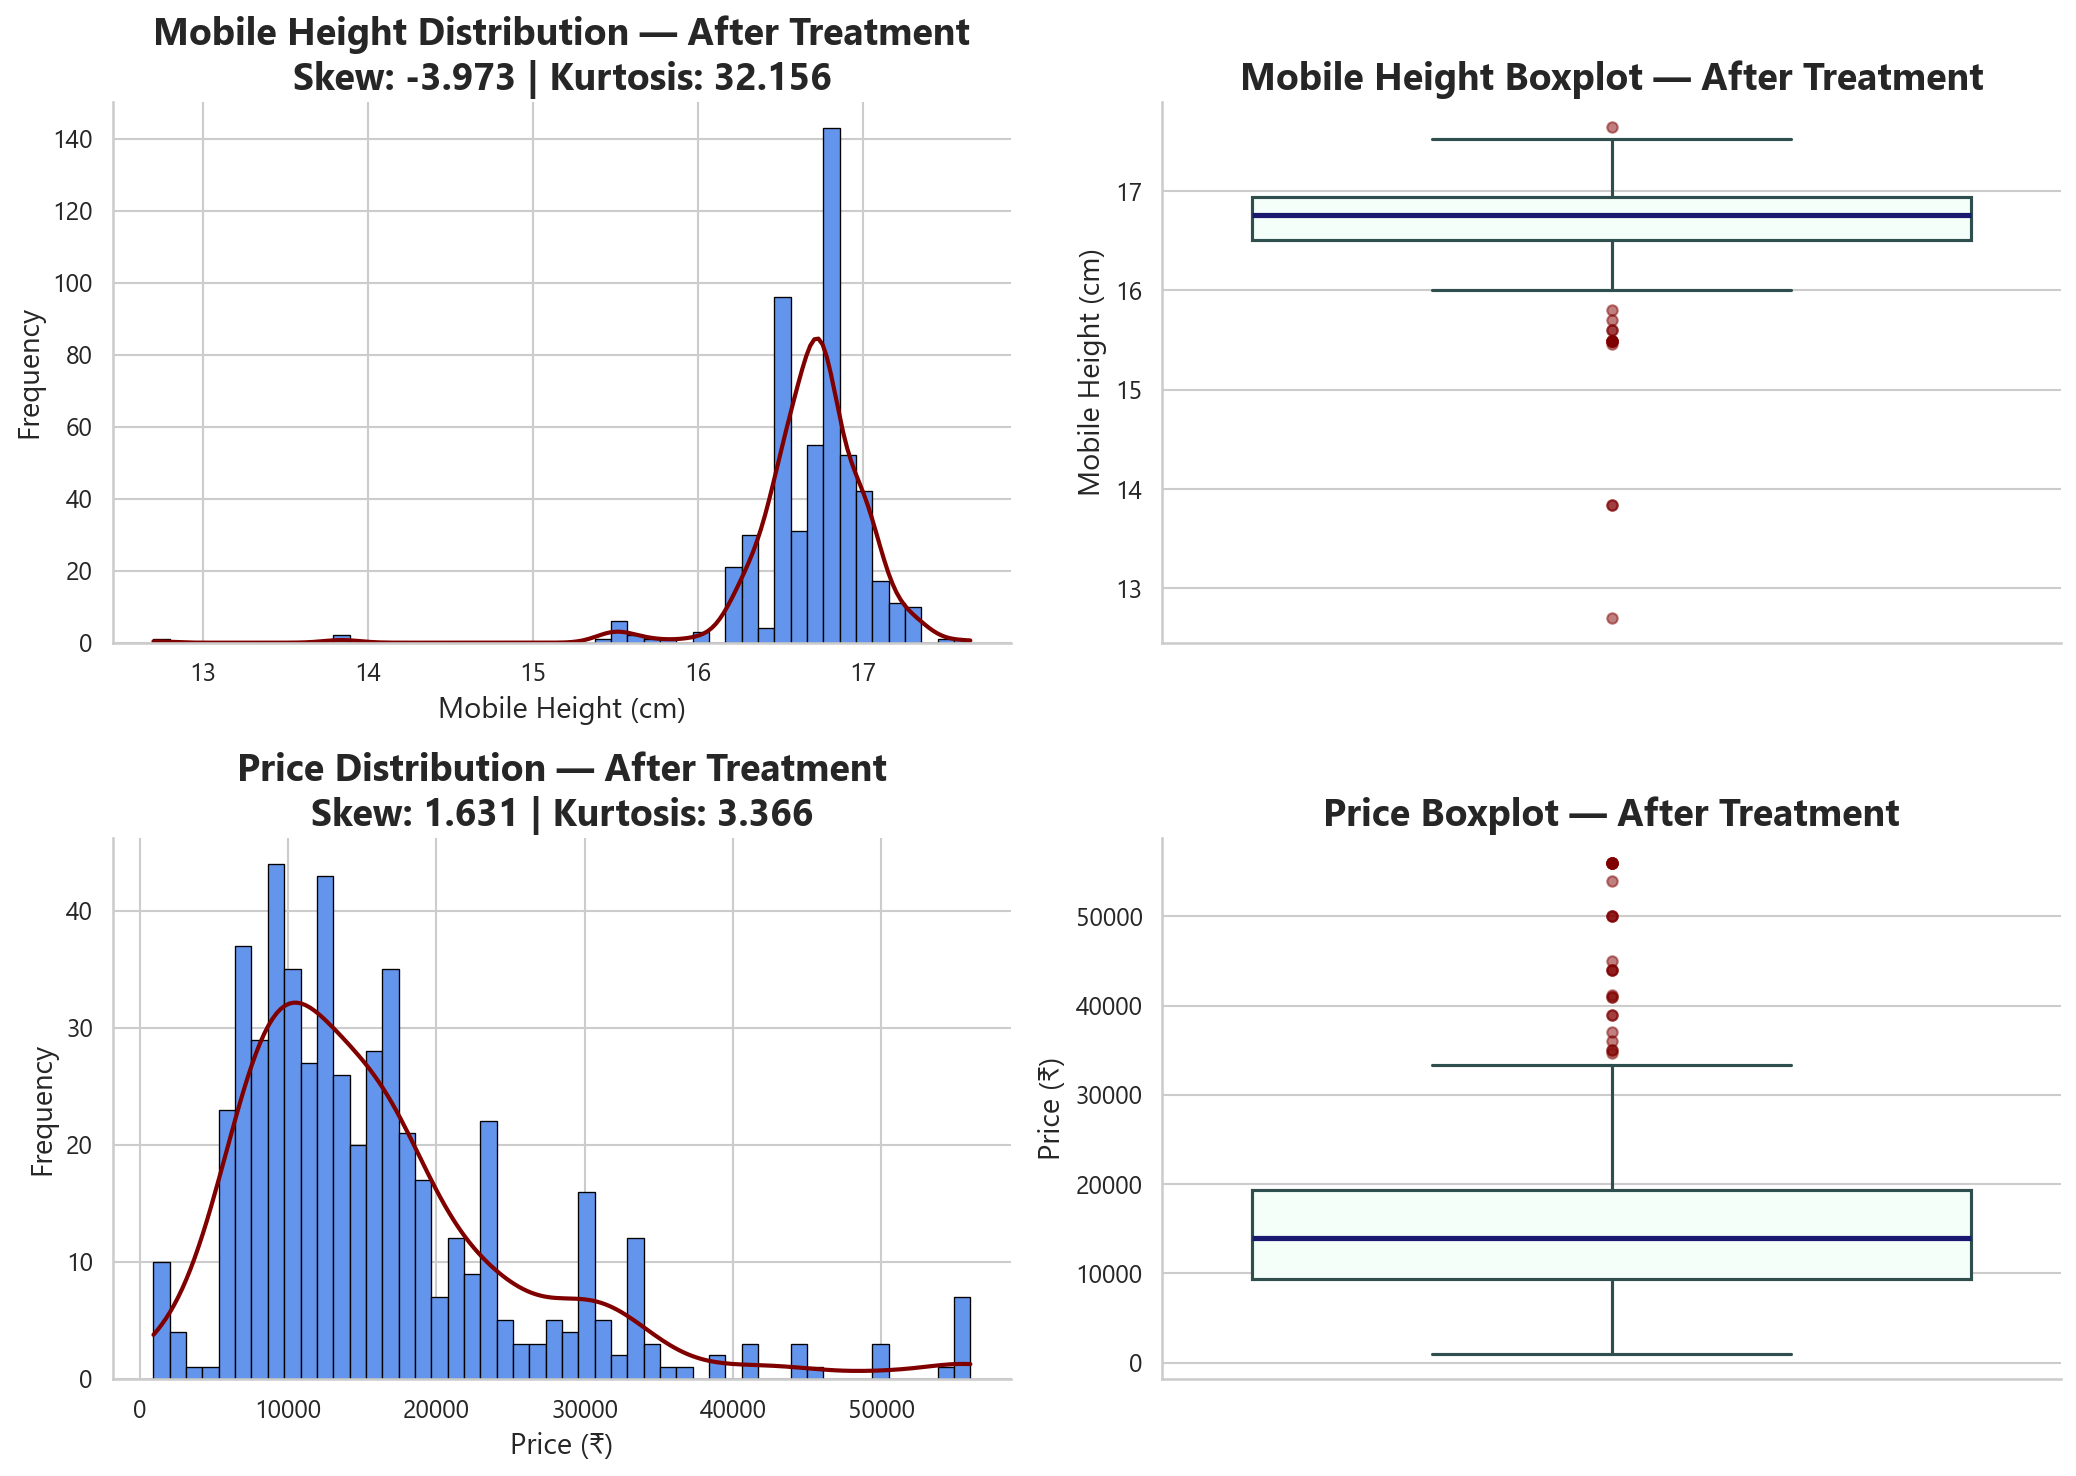


✅ Success: After treatment: Mobile Height — Skew: -3.973 | Kurtosis: 32.156
✅ Success: After treatment: Price — Skew: 1.631 | Kurtosis: 3.366


In [32]:
#   Visualize After Treatment — Mobile Height & Price (2×2 Grid)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

custom_box = dict(facecolor='mintcream', edgecolor='darkslategray', linewidth=1.5);custom_whisker = dict(color='darkslategray', linewidth=1.5);custom_cap     = dict(color='darkslategray', linewidth=1.5);custom_median  = dict(color='midnightblue', linewidth=2.5);custom_fliers  = dict(marker='o', markerfacecolor='maroon',markeredgecolor='maroon', markersize=5, alpha=0.5)

#   Mobile Height Row
height_vals= df_sanitized['Mobile Height'].dropna()
sk_h, kt_h = skew(height_vals), kurtosis(height_vals)

axes[0][0].set_title(f'Mobile Height Distribution — After Treatment\nSkew: {sk_h:.3f} | Kurtosis: {kt_h:.3f}',weight='bold');axes[0][0].set_xlabel('Mobile Height (cm)');axes[0][0].set_ylabel('Frequency')
sns.histplot(height_vals, bins=50, kde=True, ax=axes[0][0],facecolor='cornflowerblue', color='maroon',edgecolor='black', line_kws={'linewidth': 2})

axes[0][1].set_title('Mobile Height Boxplot — After Treatment', weight='bold');axes[0][1].set_ylabel('Mobile Height (cm)')
sns.boxplot(y=height_vals, ax=axes[0][1],boxprops=custom_box, whiskerprops=custom_whisker,flierprops=custom_fliers, medianprops=custom_median,capprops=custom_cap)

#   Price Row
price_vals = df_sanitized['Price'].dropna()
sk_p, kt_p = skew(price_vals), kurtosis(price_vals)

axes[1][0].set_title(f'Price Distribution — After Treatment\nSkew: {sk_p:.3f} | Kurtosis: {kt_p:.3f}',weight='bold');axes[1][0].set_xlabel('Price (₹)');axes[1][0].set_ylabel('Frequency')
sns.histplot(price_vals, bins=50, kde=True, ax=axes[1][0],facecolor='cornflowerblue', color='maroon',edgecolor='black', line_kws={'linewidth': 2})

axes[1][1].set_title('Price Boxplot — After Treatment', weight='bold');axes[1][1].set_ylabel('Price (₹)')
sns.boxplot(y=price_vals, ax=axes[1][1],boxprops=custom_box, whiskerprops=custom_whisker,flierprops=custom_fliers, medianprops=custom_median,capprops=custom_cap)

plt.tight_layout();plt.savefig('Assets/univariate_after_treatment.png', dpi=150, bbox_inches='tight');plt.show()
print(f"\n✅ Success: After treatment: Mobile Height — Skew: {sk_h:.3f} | Kurtosis: {kt_h:.3f}")
print(f"✅ Success: After treatment: Price — Skew: {sk_p:.3f} | Kurtosis: {kt_p:.3f}")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Outlier Detection & Treatment Summary**

- The outlier assessment distinguished between **feature-level validation** and **statistical outlier treatment**, ensuring each numerical feature received the most appropriate handling strategy.
- **Mobile Height** underwent feature-level validation, where **17 physically impossible measurements** were replaced with the valid median height of **16.76 cm**. This correction reduced kurtosis by removing extreme observations, while skewness became more negative **(−3.973)**, as the corrected values concentrated the distribution tightly around the central height range, creating a left-leaning tail. Since all remaining measurements were physically plausible, no further statistical treatment was applied.
- **Price** was the only feature requiring statistical outlier treatment. A **99th percentile cap** at **₹55,999** affected only **7 observations**, reducing skewness from **2.414 to 1.631** while preserving the premium smartphone segment.
- **Memory, RAM, Battery_mAh, Rear_Camera_MP, and Front_Camera_MP** were retained without modification. Although IQR and Z-Score identified some observations, these correspond to genuine storage tiers, hardware configurations, flagship camera specifications, and battery capacities rather than data quality errors.
- With feature validation and selective treatment complete, we now examine the post-treatment Price distribution through a **normality assessment** and **price range breakdown**, before progressing to **bivariate analysis**.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>

<div style="margin-left: 20px; max-width: 90%">

### 📌 Univariate Analysis — Price Distribution & Normality

<div style="margin-left: 20px; max-width: 90%;">

With outlier treatment complete, the target variable **Price** is examined from a distributional perspective.<br> 
The **Q-Q Plot** assesses how closely the treated price distribution follows a theoretical normal distribution, providing insight into distributional characteristics and the suitability of subsequent modelling approaches.

</div>
</div>

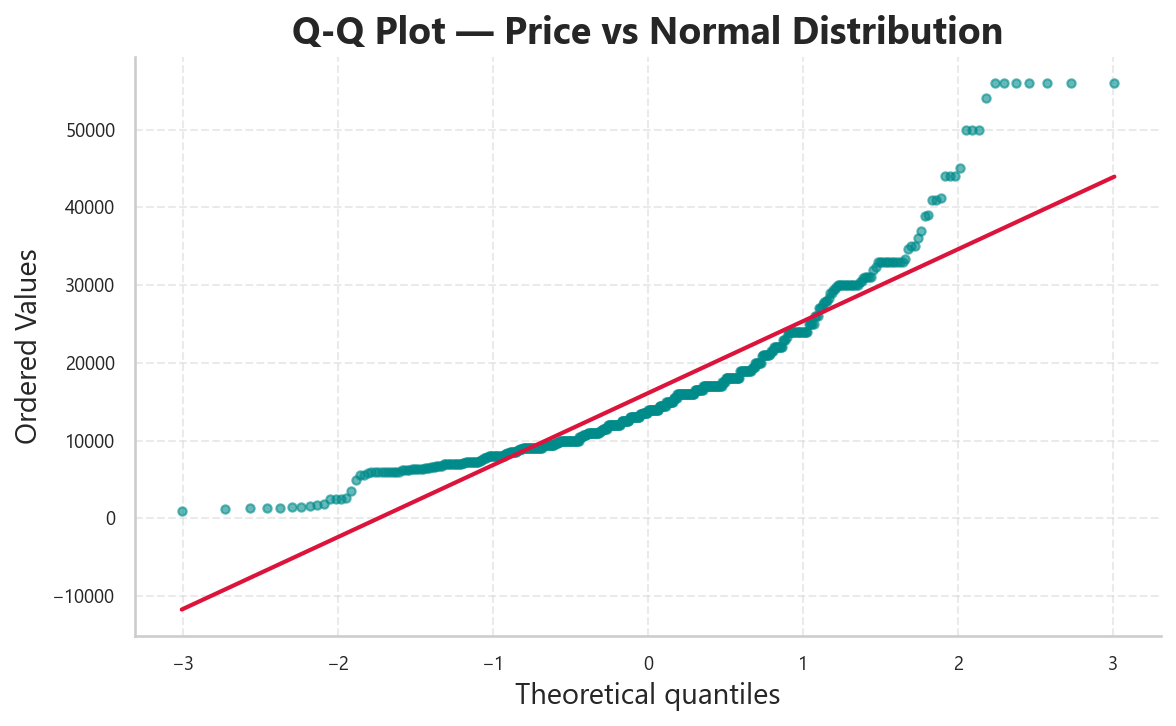

✅ Success: Univariate Analysis using Q-Q Plot generated for Price Distribution.


In [33]:

#   Q-Q Plot

fig, ax = plt.subplots(figsize=(8, 5))

probplot(df_sanitized['Price'], dist='norm', plot=ax)
ax.set_title('Q-Q Plot — Price vs Normal Distribution', fontweight='bold');ax.get_lines()[0].set(color='darkcyan', markersize=4, alpha=0.6);ax.get_lines()[1].set(color='crimson', linewidth=2);ax.tick_params(labelsize=9)
plt.grid(True, linestyle='--', alpha=0.4);plt.tight_layout();plt.savefig('Assets/univariate_qqplot_price.png', dpi=150, bbox_inches='tight');plt.show()
print("✅ Success: Univariate Analysis using Q-Q Plot generated for Price Distribution.")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Q-Q Plot:**

- Most points near the centre follow the red reference line closely, showing that **mid-range smartphone prices** are fairly close to a normal distribution.
- The points move away from the line at both ends, especially in the upper tail where a few expensive premium phones are present.
- This shows that **Price is still slightly right-skewed** even after outlier treatment, mainly because premium phones naturally cost much more than most devices.
- Since the price distribution is not perfectly normal, it is useful to compare both **Linear Regression** and **tree-based models** later to determine which model predicts prices more accurately.

</div>

<div style="margin-left: 20px; max-width: 90%">

### 📌 Univariate Analysis — Price Range Distribution

<div style="margin-left: 20px; max-width: 90%;">

Following numerical distribution analysis, the continuous **Price** variable is grouped into business-oriented price segments. This provides a high-level view of the dataset composition across different smartphone market categories before exploring relationships between features.

</div>
</div>

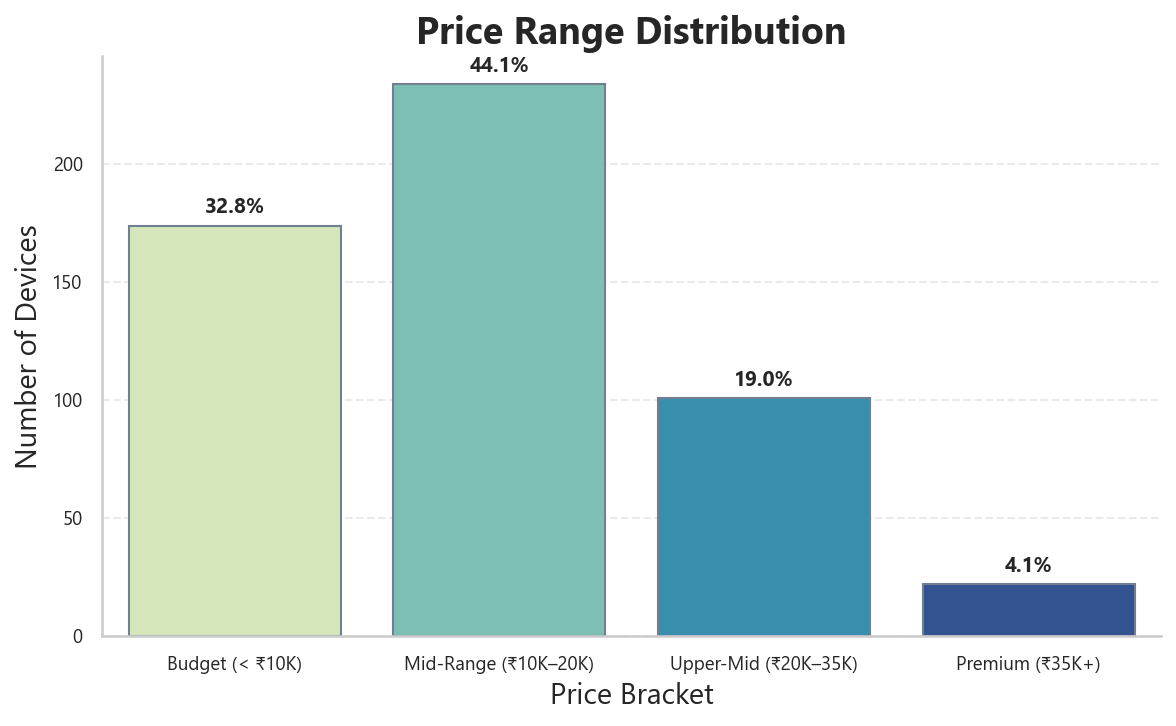

✅ Success: Univariate Analysis using Bar Plot generated for Price Distribution.


In [34]:
#   Bar Plot

bins   = [0, 10000, 20000, 35000, 60000]
labels = ['Budget (< ₹10K)', 'Mid-Range (₹10K–20K)', 'Upper-Mid (₹20K–35K)', 'Premium (₹35K+)']
df_sanitized['Price_Range'] = pd.cut(df_sanitized['Price'], bins=bins, labels=labels)
range_counts  = df_sanitized['Price_Range'].value_counts().sort_index()
range_percent = (range_counts / len(df_sanitized) * 100).round(1)
bar_df = pd.DataFrame({'Bracket': range_counts.index.astype(str),'Count'  : range_counts.values})

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=bar_df, x='Bracket', y='Count', palette='YlGnBu', ax=ax, edgecolor='slategray',hue='Bracket',legend=False)
ax.set_title('Price Range Distribution', fontweight='bold');ax.set_xlabel('Price Bracket');ax.set_ylabel('Number of Devices');ax.tick_params(labelsize=9)
for bar, pct in zip(ax.patches, range_percent.values):
    ax.text(bar.get_x() + bar.get_width()/2,bar.get_height() + 3,f'{pct}%', ha='center', va='bottom',fontsize=10, fontweight='bold')
plt.grid(True,linestyle='--', alpha=0.4,axis='y');plt.tight_layout();plt.savefig('Assets/univariate_barplot_price.png', dpi=150, bbox_inches='tight');plt.show()
print("✅ Success: Univariate Analysis using Bar Plot generated for Price Distribution.")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Price Range Distribution:**

- Most smartphones belong to the **Budget (32.8%)** and **Mid-Range (44.1%)** categories, together making up **76.9%** of the dataset.
- The **Upper-Mid** category accounts for **19%**, while only **4.1%** of devices belong to the **Premium (₹35,000+)** category.
- This shows that the dataset mainly represents **budget and mid-range smartphones**, with relatively few premium devices.
- As a result, the prediction models are expected to perform best for the budget and mid-range categories, while predictions for premium smartphones may be slightly less accurate because fewer examples are available.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>


<div style="margin-left: 20px; max-width: 90%">

### 📌 Price vs Key Features (Bivariate Analysis)

<div style="margin-left: 20px; max-width: 90%">

We examine how Price varies across individual hardware specifications. Each chart isolates one feature against Price to identify which specifications show the strongest visual relationship with pricing.

</div>
</div>

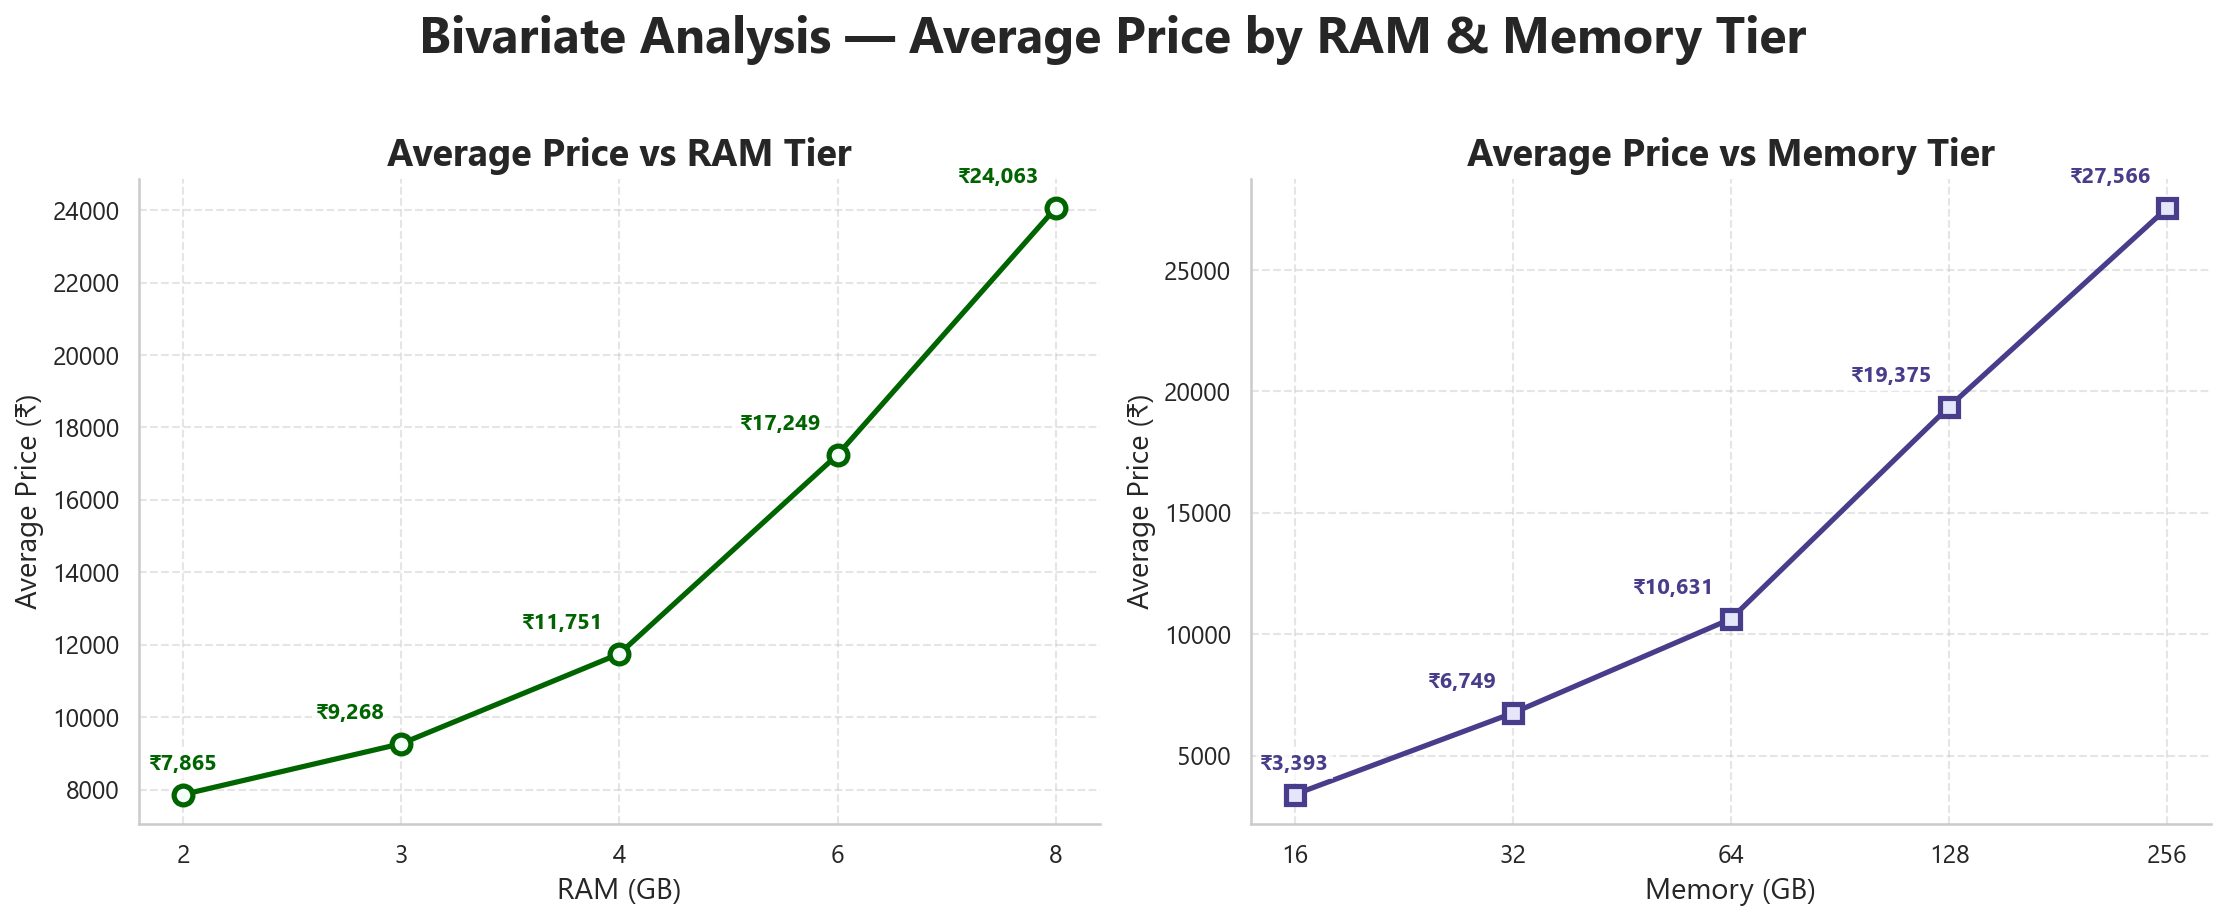

✅ Success: Line charts for Price vs RAM and Price vs Memory generated.


In [35]:
#   Bivariate Analysis — Avg Price vs RAM & Memory Tier (Line Charts)

fig, axes = plt.subplots(1, 2, figsize=(15, 6));fig.suptitle('Bivariate Analysis — Average Price by RAM & Memory Tier',fontweight='bold', fontsize=24, y=1.02)

#   A. Price vs RAM
ram_avg = (df_sanitized.groupby('RAM', observed=True)['Price'].mean().reset_index().sort_values('RAM'))

axes[0].plot(ram_avg['RAM'].astype(str), ram_avg['Price'],marker='o', markersize=9, linewidth=2.5, color='darkgreen', markerfacecolor='mintcream',markeredgecolor='darkgreen', markeredgewidth=2.5)
for idx, (i, row) in enumerate(ram_avg.iterrows()):
    # Dynamically align: push the first label right to avoid the y-axis, push the rest left to avoid the line
    ha_val = 'center' if idx == 0 else 'right'
    x_val = 0 if idx == 0 else -8
    axes[0].annotate(f"₹{row['Price']:,.0f}",xy=(str(int(row['RAM'])), row['Price']),xytext=(x_val, 12), textcoords='offset points',ha=ha_val, fontsize=10.5, fontweight='bold',color='darkgreen',bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2))

axes[0].set_title('Average Price vs RAM Tier', fontweight='bold');axes[0].set_xlabel('RAM (GB)');axes[0].set_ylabel('Average Price (₹)');axes[0].grid(True, linestyle='--', alpha=0.5)

#   B. Price vs Memory
mem_avg = (df_sanitized.groupby('Memory', observed=True)['Price'].mean().reset_index().sort_values('Memory'))

axes[1].plot(mem_avg['Memory'].astype(str), mem_avg['Price'],marker='s', markersize=9, linewidth=2.5,color='darkslateblue', markerfacecolor='lavender',markeredgecolor='darkslateblue', markeredgewidth=2.5)
for idx, (i, row) in enumerate(mem_avg.iterrows()):
    ha_val = 'center' if idx == 0 else 'right'
    x_val = 0 if idx == 0 else -8
    axes[1].annotate(f"₹{row['Price']:,.0f}",xy=(str(int(row['Memory'])), row['Price']),xytext=(x_val, 12), textcoords='offset points',ha=ha_val, fontsize=10.5, fontweight='bold',color='darkslateblue',bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2))

axes[1].set_title('Average Price vs Memory Tier', fontweight='bold');axes[1].set_xlabel('Memory (GB)');axes[1].set_ylabel('Average Price (₹)');axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout();plt.savefig('Assets/bivariate_line_ram_memory.png', dpi=150, bbox_inches='tight');plt.show()
print("✅ Success: Line charts for Price vs RAM and Price vs Memory generated.")

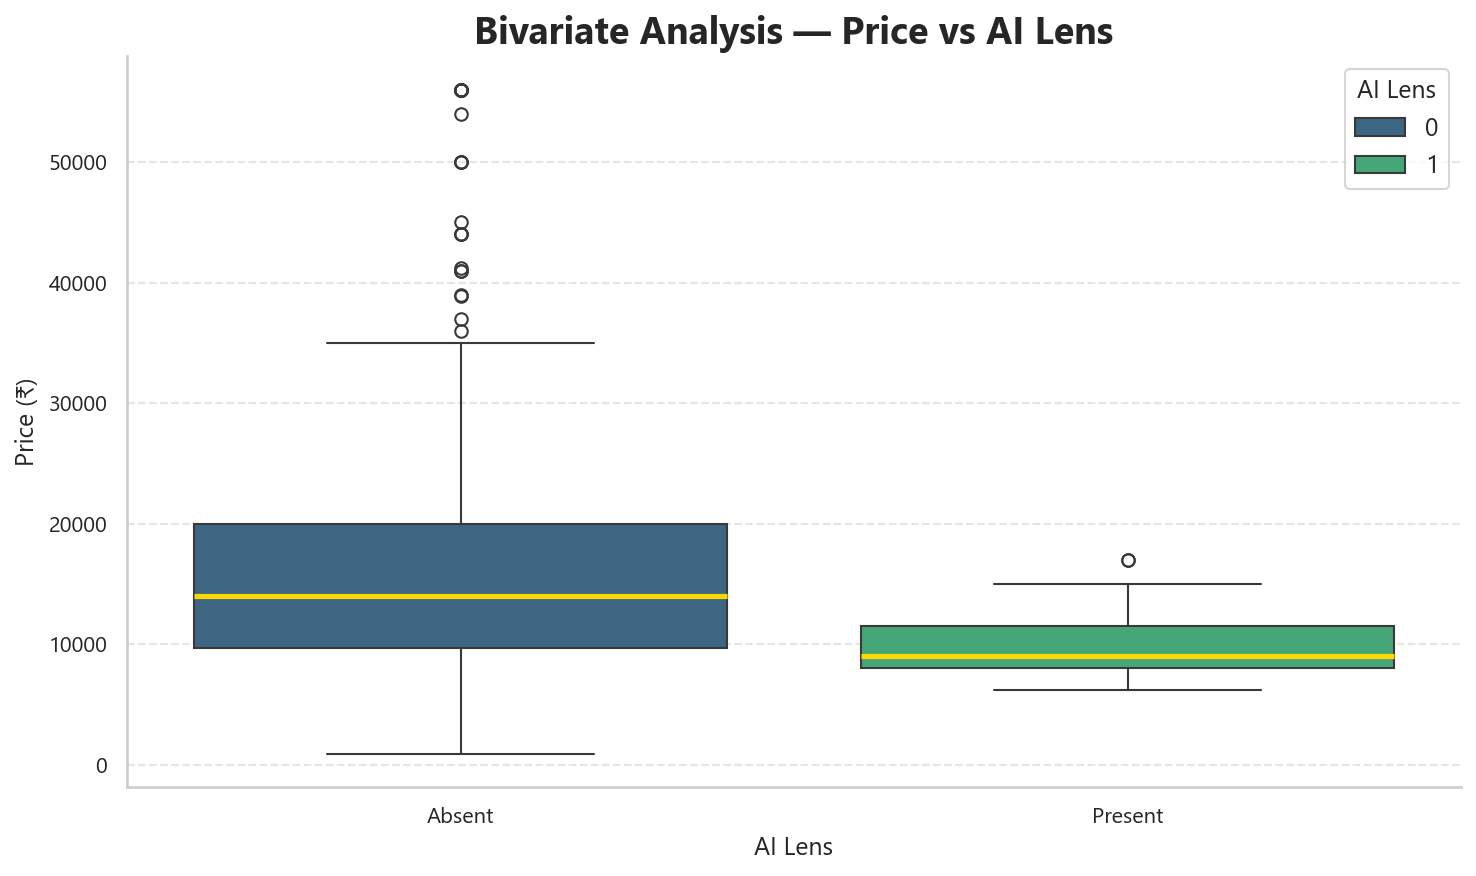

✅ Success: Bivariate Analysis using Boxplot charts generated for Price vs AI Lens


In [36]:
#   Box-Plot : Price vs AI Lens

fig, ax = plt.subplots(figsize=(10, 6))
custom_median = dict(color='gold', linewidth=2.5)

sns.boxplot(x='AI Lens', y='Price', data=df_sanitized, palette='viridis', hue='AI Lens', legend=True, medianprops=custom_median, ax=ax)
ax.set_title('Bivariate Analysis — Price vs AI Lens', fontweight='bold');ax.set_xlabel('AI Lens', fontsize=12);ax.set_ylabel('Price (₹)', fontsize=12);ax.tick_params(labelsize=10.5);ax.set_xticks([0, 1]);ax.set_xticklabels(['Absent', 'Present']);ax.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout();plt.savefig('Assets/bivariate_ai_lens_boxplot.png', dpi=150, bbox_inches='tight');plt.show()
print("✅ Success: Bivariate Analysis using Boxplot charts generated for Price vs AI Lens")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Price vs Key Hardware Features:**
- **RAM vs Price** — The average price rises consistently and steeply from ₹7,865 (2GB) to ₹24,063 (8GB), confirming RAM tier is a massive, direct driver of a smartphone's retail price.
- **Memory vs Price** — A nearly identical upward trajectory is visible for storage. The average price scales exponentially at the highest tiers, with 256GB models averaging ₹27,566.
- **AI Lens vs Price** — Counterintuitively, devices **WITHOUT** an AI Lens have a higher median price (~₹14,000) and a much wider price range than devices **WITH** an AI Lens (~₹9,000). This indicates that "AI Lens" branding is heavily utilized as a marketing feature in the budget-segment, rather than acting as a premium differentiator.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>

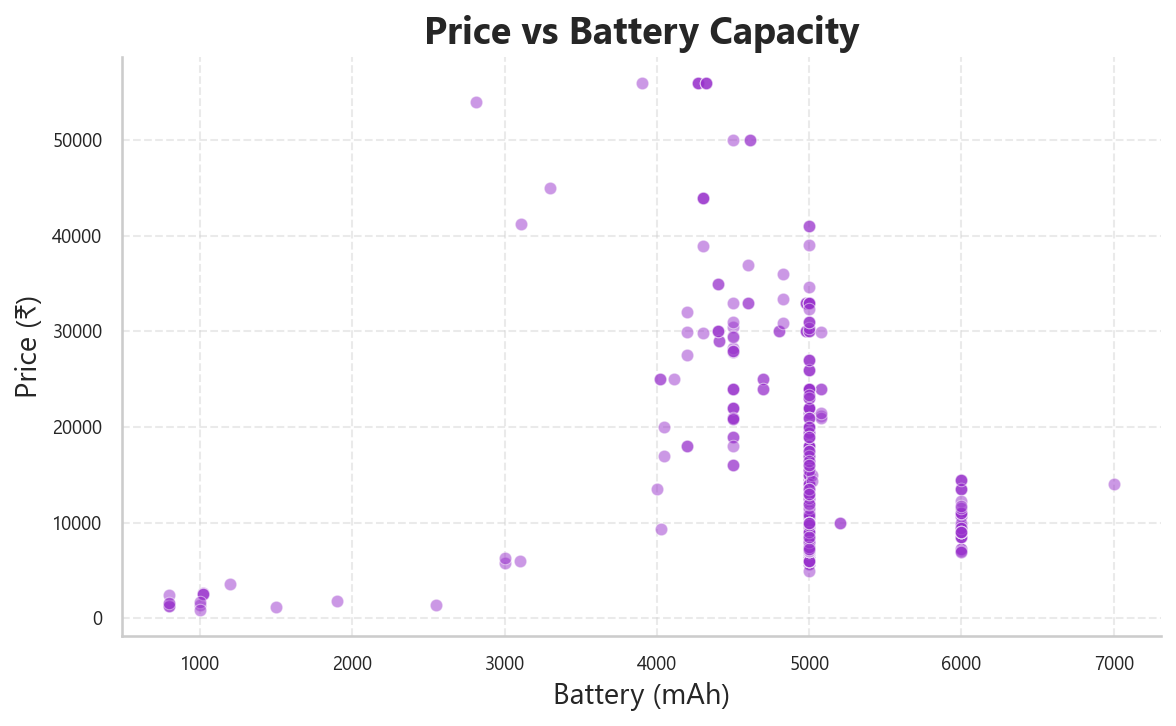

✅ Success: Bivariate Analysis using Scatter plot generated for Price vs Battery


In [37]:
#   Scatter Plot 

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x='Battery_mAh', y='Price', data=df_sanitized,ax=ax, alpha=0.5, color='darkorchid')
ax.set_title('Price vs Battery Capacity', fontweight='bold');ax.set_xlabel('Battery (mAh)');ax.set_ylabel('Price (₹)');ax.tick_params(labelsize=9)
plt.grid(True, linestyle='--', alpha=0.4);plt.tight_layout();plt.savefig('Assets/bivariate_scatter_battery.png', dpi=150, bbox_inches='tight');plt.show()
print("✅ Success: Bivariate Analysis using Scatter plot generated for Price vs Battery")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Price vs Battery Capacity:**
- No strong linear relationship between battery capacity and price — dots are widely scattered across all battery ranges.
- Majority of devices cluster around **4000–5000 mAh** regardless of price tier — this is the industry standard battery range.
- High-priced devices (₹40,000+) appear across multiple battery sizes — confirming battery is NOT a primary price driver.
- Devices with battery below **2000 mAh** are very few and cluster at low price points — likely feature phones or older entry-level devices rather than modern smartphones.

</div>

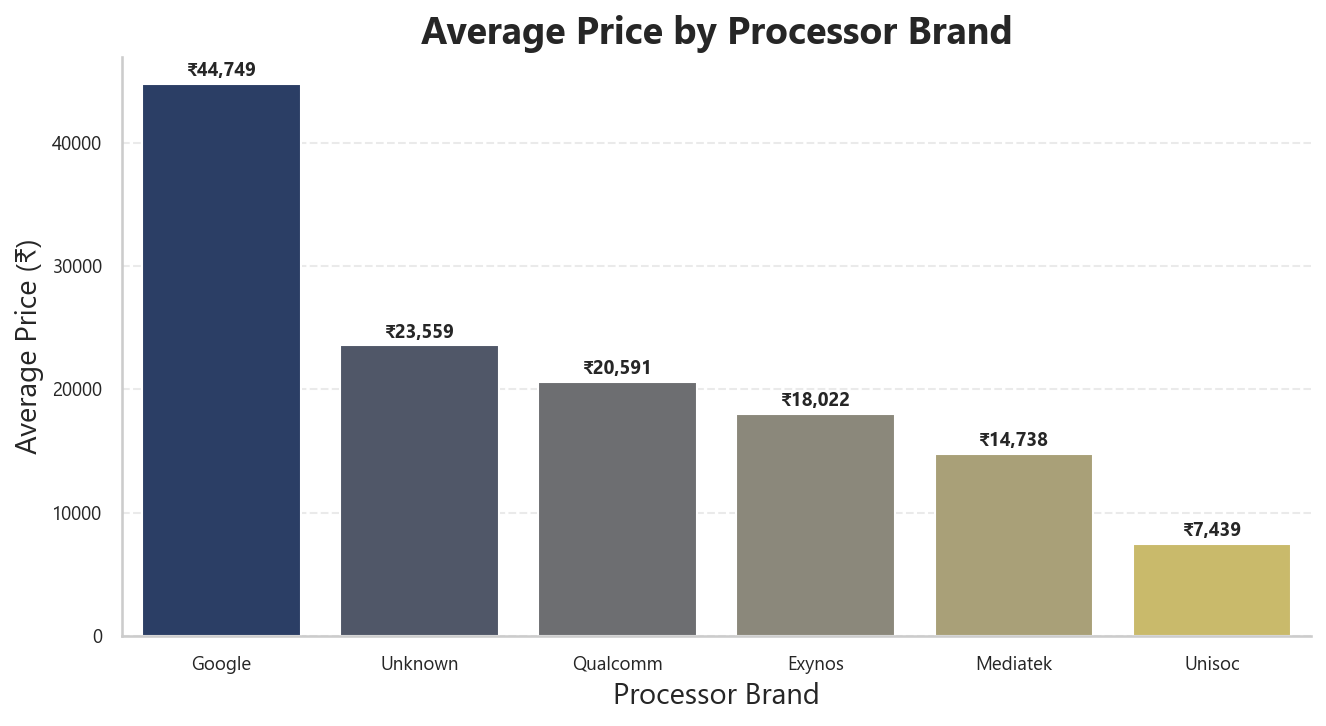

✅ Success: Bivariate Analysis using Bar chart generated for Processor Brand vs Avg. Price.


In [38]:
#   Bar Plot

fig, ax = plt.subplots(figsize=(9, 5))
processor_brand = (df_sanitized.groupby('Processor_Brand', observed=True)['Price'].mean().sort_values(ascending=False).reset_index())
processor_brand.columns = ['Brand', 'Avg_Price']
sns.barplot(x='Brand', y='Avg_Price', data=processor_brand,palette='cividis', ax=ax, hue='Brand', legend=False,errorbar=None,order=processor_brand['Brand'],hue_order=processor_brand['Brand'])
ax.set_title('Average Price by Processor Brand', fontweight='bold');ax.set_xlabel('Processor Brand');ax.set_ylabel('Average Price (₹)');ax.tick_params(labelsize=9)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2,bar.get_height() + 300,f'₹{bar.get_height():,.0f}',ha='center', va='bottom',fontsize=9, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.4, axis='y');plt.tight_layout();plt.savefig('Assets/bivariate_bar_processor.png', dpi=150, bbox_inches='tight');plt.show()
print("✅ Success: Bivariate Analysis using Bar chart generated for Processor Brand vs Avg. Price.")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Average Price by Processor Brand:**
- **Google** commands the highest average price at **₹44,749** — Pixel devices are premium positioned in the market.
- **Unknown** category ranks second at **₹23,559** — devices whose processor strings could not be mapped to any known manufacturer. The relatively high average price suggests capable processors despite unidentified naming.
- **Qualcomm** averages **₹20,591&& — mid to upper-mid positioning.
- **Exynos** (**₹18,022**) and **Mediatek** (**₹14,738**) serve the mid-range segment.
- **Unisoc** is the most budget-oriented brand at **₹7,439** average.
- A clear processor brand price hierarchy is confirmed — `Processor_Brand` will be a valuable feature for our One Hot Encoding.

</div>

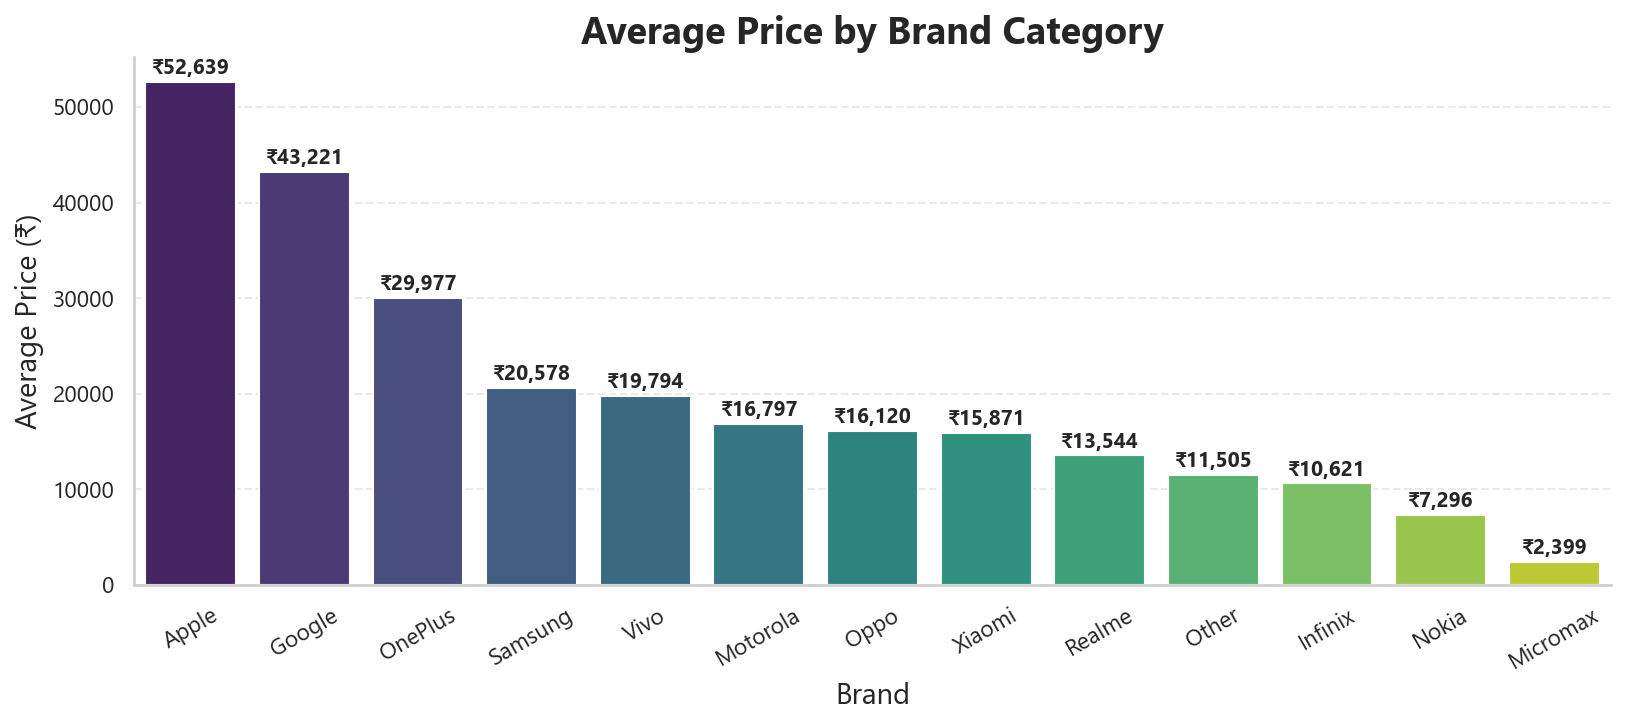

✅ Success: Bivariate Analysis using Bar chart generated for Brand vs Avg. Price


In [39]:
#   Bar Plot — Average Price by Model Category (Brand)
brand_price = (df_sanitized.groupby('Model_Category', observed=True)['Price'].mean().sort_values(ascending=False).reset_index())
brand_price.columns = ['Brand', 'Avg_Price']

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x='Brand', y='Avg_Price', data=brand_price,palette='viridis', ax=ax, hue='Brand', legend=False,order=brand_price['Brand'],hue_order=brand_price['Brand'])
ax.set_title('Average Price by Brand Category', fontweight='bold');ax.set_xlabel('Brand'); ax.set_ylabel('Average Price (₹)');ax.tick_params(axis='x', rotation=30, labelsize=11);ax.tick_params(axis='y',labelsize=11)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,f'₹{bar.get_height():,.0f}', ha='center', va='bottom',fontsize=10, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.4, axis='y');plt.tight_layout();plt.savefig('Assets/bivariate_bar_brand.png', dpi=150, bbox_inches='tight');plt.show()
print("✅ Success: Bivariate Analysis using Bar chart generated for Brand vs Avg. Price")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Average Price by Brand Category:**
- **Apple (₹52,639)** commands the highest average price by a wide margin, followed by **Google (₹43,221)** — confirming Apple and Google's premium market positioning even within this budget-skewed dataset. Both brands have very few devices (5 and 8 respectively, per the earlier distribution table), so these averages should be read as indicative of brand positioning rather than statistically robust estimates.
- **OnePlus (₹29,977)** sits clearly in the upper-mid segment, well above mass-market brands — consistent with OnePlus's "flagship killer" positioning in the broader market.
- **Samsung (₹20,578) and Vivo (₹19,794)** cluster closely together in the mid-range, despite Samsung having more brand recognition globally — suggesting this dataset's Samsung listings skew toward mid-tier models rather than Samsung's premium Galaxy S/Note lineup.
- **Xiaomi (₹15,871)**, despite dominating device count (25% of the dataset), sits in the lower-mid price range — confirming Xiaomi's strategy of high-volume, affordable devices rather than premium positioning.
- **Micromax (₹2,399) and Nokia (₹7,296)** are the most budget-oriented brands, consistent with their positioning as value/feature-phone-adjacent manufacturers in this market.
- As per our observation, average price varies dramatically by brand (a 22x spread from Micromax to Apple), but this signal is captured more granularly by the model through the individual-level Model_Encoded feature rather than this 12-category grouping, since brand alone doesn't fully explain price (a budget-spec iPhone variant could still price below a maxed-out Xiaomi flagship).

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>

<div style="margin-left: 20px; max-width: 90%">

### 📌 Multivariate Analysis — Feature Interactions

<div style="margin-left: 20px; max-width: 90%">

Moving beyond individual features, we examine how multiple variables interact with each other and with Price simultaneously. The correlation heatmap reveals linear relationships across all features, while the camera comparison shows how rear and front camera quality together influence pricing.

</div>
</div>

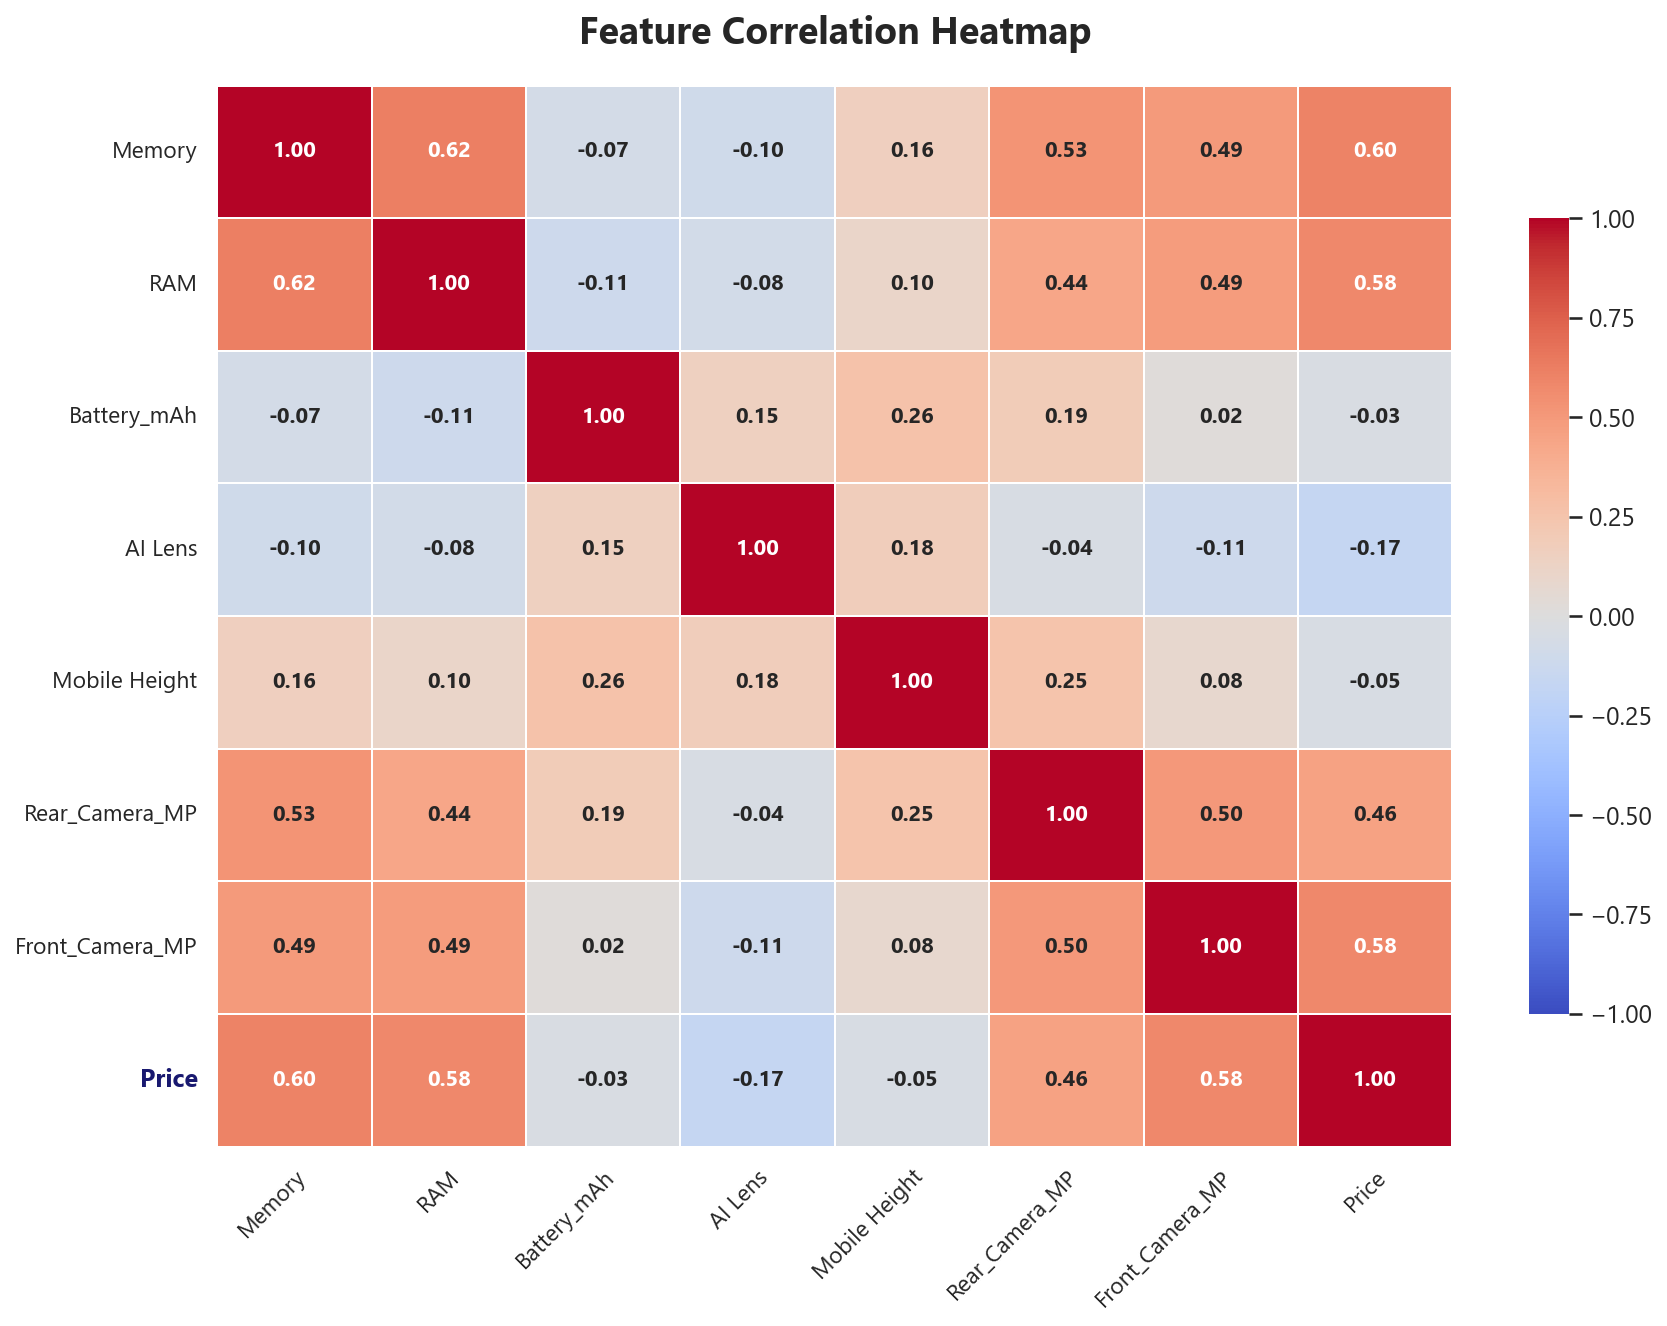

✅ Success: Multivariate Analysis using Correlation heatmap generated


In [40]:
#   Correlation Heatmap

fig, ax = plt.subplots(figsize=(12, 9))
target_col = 'Price'
cols = [col for col in df_sanitized.columns if col not in [target_col, 'Price_Range','Model_Category','Colour_Category','Processor_Brand','Model','Colour']]
cols.append(target_col)
corr_matrix = df_sanitized[cols].corr()

sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm',center=0,linewidths=0.8,cbar_kws={'shrink': 0.75},annot_kws={'fontsize': 10.5, 'weight': 'bold'},linecolor='white',ax=ax,vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap',fontweight='bold', pad=20);ax.tick_params(labelsize=11);ax.tick_params(axis='y', rotation=0)

for label in ax.get_yticklabels():
    if label.get_text() == 'Price':
        label.set_fontweight('bold')
        label.set_fontsize(12) 
        label.set_color('MidnightBlue')

plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
plt.grid(False);plt.tight_layout();plt.savefig('Assets/multivariate_correlation_heatmap.png', dpi=150, bbox_inches='tight');plt.show()
print("✅ Success: Multivariate Analysis using Correlation heatmap generated")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Feature Correlation Heatmap:**
- **Memory (0.60)** and **RAM (0.58)** are the strongest positive correlates with Price — confirming our earlier bivariate findings that these base specs drive pricing.
- **Front_Camera_MP (0.58)** and **Rear_Camera_MP (0.46)** also show strong positive correlation with Price — indicating camera quality is a significant, consistent price driver.
- **RAM and Memory (0.62)** are strongly correlated with each other — this multicollinearity is expected, but it will influence how our machine learning models distribute feature importance between them later.
- **AI Lens (-0.17)** shows a weak negative correlation — confirming our boxplot insight that this is primarily a budget-segment marketing feature.
- **Mobile Height (-0.05)** and **Battery_mAh (-0.03)** both show near-zero linear correlation with Price — suggesting they are not primary linear price drivers (though non-linear relationships may still exist).

</div>

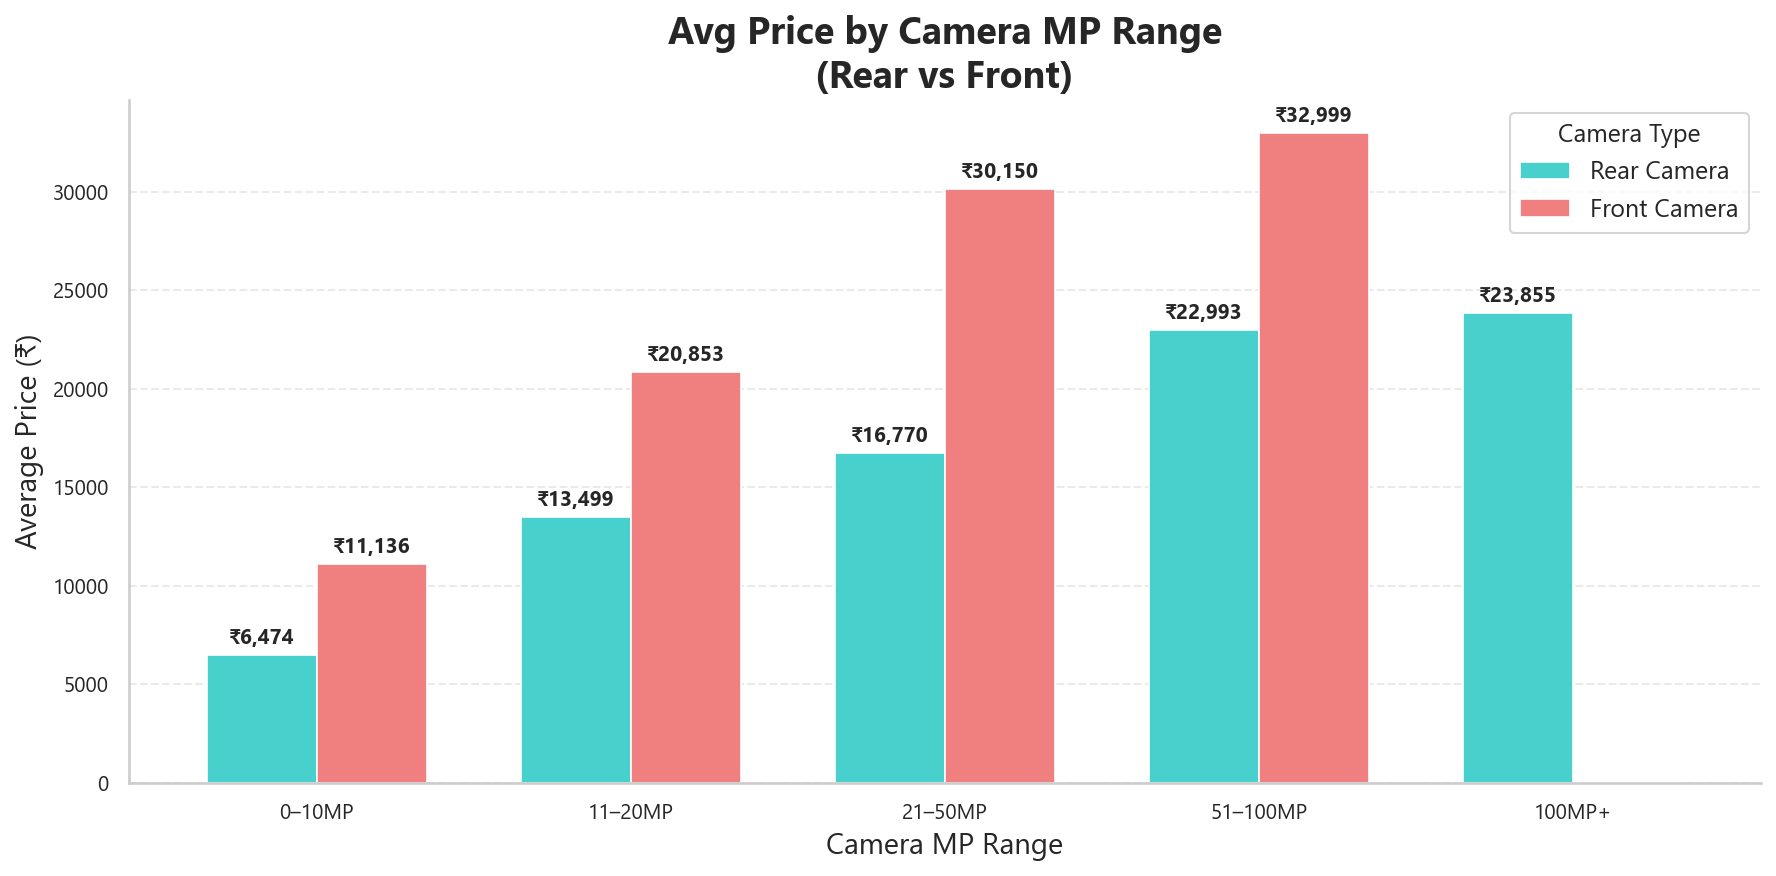

✅ Success: Multivariate Analysis using grouped bar charts generated.


In [41]:
#   Rear vs Front Camera MP vs Price (Grouped Bar)
camera_bins   = [0, 10, 20, 50, 100, 220]
camera_labels = ['0–10MP', '11–20MP', '21–50MP', '51–100MP', '100MP+']

df_sanitized['Rear_Bin']  = pd.cut(df_sanitized['Rear_Camera_MP'],bins=camera_bins, labels=camera_labels)
df_sanitized['Front_Bin'] = pd.cut(df_sanitized['Front_Camera_MP'],bins=camera_bins, labels=camera_labels)

rear_avg  = df_sanitized.groupby('Rear_Bin',  observed=True)['Price'].mean()
front_avg = df_sanitized.groupby('Front_Bin', observed=True)['Price'].mean()

camera_df = pd.DataFrame({'Rear Camera':  rear_avg,'Front Camera': front_avg})

fig, ax = plt.subplots(figsize=(12, 6))
camera_df.plot(kind='bar', ax=ax, color=['mediumturquoise', 'lightcoral'],edgecolor='white', linewidth=0.8,width=0.7)

ax.set_title('Avg Price by Camera MP Range\n(Rear vs Front)',fontweight='bold');ax.set_xlabel('Camera MP Range');ax.set_ylabel('Average Price (₹)');ax.tick_params(axis='x', rotation=0);ax.tick_params(labelsize=10);ax.legend(title='Camera Type')
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2,height + 300,f'₹{height:,.0f}',ha='center', va='bottom',fontsize=10, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.4,axis='y');plt.grid(False,axis='x');plt.tight_layout();plt.savefig('Assets/multivariate_groupbar_cameraVprice.png', dpi=150, bbox_inches='tight');plt.show()
print("✅ Success: Multivariate Analysis using grouped bar charts generated.")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Avg Price by Camera MP Range:**
- Both Rear and Front camera MP ranges show a clear upward trend with price — higher MP cameras consistently appear in more expensive devices.
- **Front Camera** commands higher average prices than Rear Camera within every comparable MP range — confirming that selfie camera quality carries more pricing weight than rear camera quality in this market.
- The gap between Front and Rear camera pricing widens significantly in the **21–50MP** (₹30,150 vs ₹16,770) and **51–100MP** (₹32,999 vs ₹22,993) ranges — premium devices prioritize front camera quality over rear camera upgrades.
- **100MP+ rear cameras** average ₹23,855 — lower than 51–100MP rear cameras (₹22,993 is close, but the 100MP+ devices are mid-range phones rather than flagship devices). Ultra-high rear MP is not exclusive to premium pricing.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>

<div style="margin-left: 20px; max-width: 90%">

### 📌 EDA Cleanup

<div style="margin-left: 20px; max-width: 90%">

Three helper columns were created during EDA purely for visualization purposes — `Price_Range`, `Model_Category`,`Colour_Category`,`Rear_Bin`, and `Front_Bin`. These categorical columns serve no analytical purpose in modelling and are dropped here to restore the dataset to its clean numeric state before Feature Extraction and Model Building.

</div>
</div>

In [42]:
#   Drop EDA helper columns before modelling
eda_columns = ['Price_Range','Model_Category','Colour_Category','Rear_Bin', 'Front_Bin']

#   Only drop columns that exist
cols_to_drop = [col for col in eda_columns if col in df_sanitized.columns]
df_sanitized.drop(columns=cols_to_drop, inplace=True)

print(f"✅ Success: EDA helper columns dropped: {cols_to_drop}")
print(f"Final shape for feature selection: {df_sanitized.shape}")

✅ Success: EDA helper columns dropped: ['Price_Range', 'Model_Category', 'Colour_Category', 'Rear_Bin', 'Front_Bin']
Final shape for feature selection: (531, 11)


<div style="margin-left: 40px; max-width: 90%">

💡 **Post-Cleanup Check:**
- EDA helper columns dropped — dataset restored to **(531 × 11)** shape for Final process of this section — Encoding.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>

<div style="margin-left: 20px; max-width: 90%">

### 📌 Encoding Categorical Variables

<div style="margin-left: 20px; max-width: 90%">

Machine learning models require all input to be numeric. The remaining categorical columns in the dataset cannot be fed directly into any model — they must be converted to a numeric representation first.

The encoding strategy for each column is chosen based on its cardinality, to avoid unnecessary column explosion or false ordinal relationships.

</div>
</div>

In [43]:
#   Cardinality check before encoding
print("="*45)
print(f"Model unique values  : {df_sanitized['Model'].nunique()}")
print(f"Colour unique values : {df_sanitized['Colour'].nunique()}")
print(f"Processor_Brand unique values: {df_sanitized['Processor_Brand'].nunique()}")
print("="*45)

Model unique values  : 187
Colour unique values : 275
Processor_Brand unique values: 6


In [44]:
#   Label Encoding: Model and Colour
le_model = LabelEncoder()
le_colour = LabelEncoder()
df_sanitized['Model_Encoded']  = le_model.fit_transform(df_sanitized['Model'])
df_sanitized['Colour_Encoded'] = le_colour.fit_transform(df_sanitized['Colour'])
df_sanitized.drop(columns=['Model', 'Colour'], inplace=True)
print("✅ Success: Label Encoding applied → Model, Colour")

✅ Success: Label Encoding applied → Model, Colour


In [45]:
#   View Label Encoding Mappings — Side by Side
model_mapping = pd.DataFrame({'Model': sorted(df['Model'].unique()),'Encoded Value': range(df['Model'].nunique())})
colour_mapping = pd.DataFrame({'Colour': sorted(df['Colour'].unique()),'Encoded Value': range(df['Colour'].nunique())})

html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">LABEL ENCODING MAPPING<span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">First 10 Entries</i>
    </h2>
</div>
<div style="display: flex; justify-content: center; gap: 40px;">
'''
html_content += f'''
    <div><p style="text-align: center; font-weight: bold; color: #CCCCCC; margin-bottom: 8px;">Model Encoding</p>{model_mapping.head(10).to_html(index=False, border=1, justify="center")}</div>
    <div><p style="text-align: center; font-weight: bold; color: #CCCCCC; margin-bottom: 8px;">Colour Encoding</p>{colour_mapping.head(10).to_html(index=False, border=1, justify="center")}</div>
'''
html_content += '</div>'
display(HTML(html_content))
print("✅ Success: Label encoding mappings verified for Model and Colour.")

Model,Encoded Value
APPLE iPhone 11,0
APPLE iPhone 12,1
APPLE iPhone 14 Plus,2
Google Pixel 6a,3
Google Pixel 7,4
Google Pixel 7a,5
I Kall Z19Pro,6
I Kall Z19Pro Flash blue,7
IQOO Neo 7 5G,8
Infinix HOT 12 Play,9


✅ Success: Label encoding mappings verified for Model and Colour.


In [46]:
#   One-Hot Encoding: Processor_Brand
df_sanitized = pd.get_dummies(df_sanitized, columns=['Processor_Brand'], prefix='Proc', dtype=int)
print("✅ Success: One-Hot Encoding applied → Processor_Brand")
print("\n New columns:", [col for col in df_sanitized.columns if col.startswith('Proc')])

✅ Success: One-Hot Encoding applied → Processor_Brand

 New columns: ['Proc_Exynos', 'Proc_Google', 'Proc_Mediatek', 'Proc_Qualcomm', 'Proc_Unisoc', 'Proc_Unknown']


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Encoding:**
- Model (187 unique values) and Colour (275 unique values) label encoded — dataset stays compact without column explosion
- Label Encoding assigns numbers **alphabetically** — encoding order carries no price significance. For example, `Aqua Blue = 3` does not imply it is cheaper or better than `Astral Black = 8`. The model learns price relationships through training, not through the encoded number itself.
- Mapping verified for both Model and Colour — first 10 entries confirmed as alphabetically ordered integers starting from 0
- Processor_Brand one-hot encoded into 6 binary columns: `Proc_Exynos`, `Proc_Google`, `Proc_Mediatek`, `Proc_Qualcomm`, `Proc_Unknown`, `Proc_Unisoc`
- One-Hot Encoding chosen for Processor_Brand specifically to avoid imposing a false ordinal relationship between manufacturers — no brand is numerically "greater" than another.
- All categorical columns successfully converted to numeric format — dataset is fully model-ready.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>


<div style="text-align: center; margin-top: 50px; margin-bottom: 30px;">
    <h3 style="color: #4CAF50;letter-spacing: 1px;"><b>✅Checkpoint: Exploratory Data Analysis Complete</b></h3>
    <p style="font-style: italic; opacity: 0.8; font-size: 1.1em;">
        All visual patterns identified. Key price drivers confirmed.<br>
        We now transition from exploration to feature selection and then to model building.
    </p>
    <hr style="width: 45%; border: none; border-top: 1px solid #555; margin-top: 20px;">
</div>


## 05. Feature Extraction & Selection

<div style="margin-left: 20px; max-width: 90%">

Feature extraction is the process of identifying and transforming raw variables into representations that carry the most predictive signal for machine learning. This section systematically determines which features are genuinely useful for price prediction and eliminates low-value noise before model training begins.

This section employs **three complementary screening methods** to ensure robust, evidence-based feature selection:

| Method | Type | What It Measures |
|---|---|---|
| Correlation Analysis | Statistical | Linear relationship strength with Price |
| SelectKBest | Statistical Filter | Statistical significance via F-test |
| Random Forest Screening | Model-Based (Bagging) | Non-linear predictive signal strength |

Using three methods prevents over-reliance on any single technique. Features that rank consistently high across all three carry the strongest evidence for inclusion in model training.

> **Threshold Note:** SelectKBest uses p-value < 0.05 (standard statistical significance convention).
> Random Forest uses RF gain score ≥ 0.01 (feature contributes at least 1% of total predictive signal) —
> a model-based threshold distinct from statistical significance.

<div style="margin-left: 20px; max-width: 90%">

### 📌 Correlation with Target

<div style="margin-left: 20px; max-width: 90%">

A horizontal bar chart showing each feature's linear correlation with Price. Positive bars indicate features that increase alongside Price, while negative bars indicate features that move inversely to Price. This provides a quick first-pass ranking of which features show a direct linear relationship with our target variable.

</div>
</div>
</div>

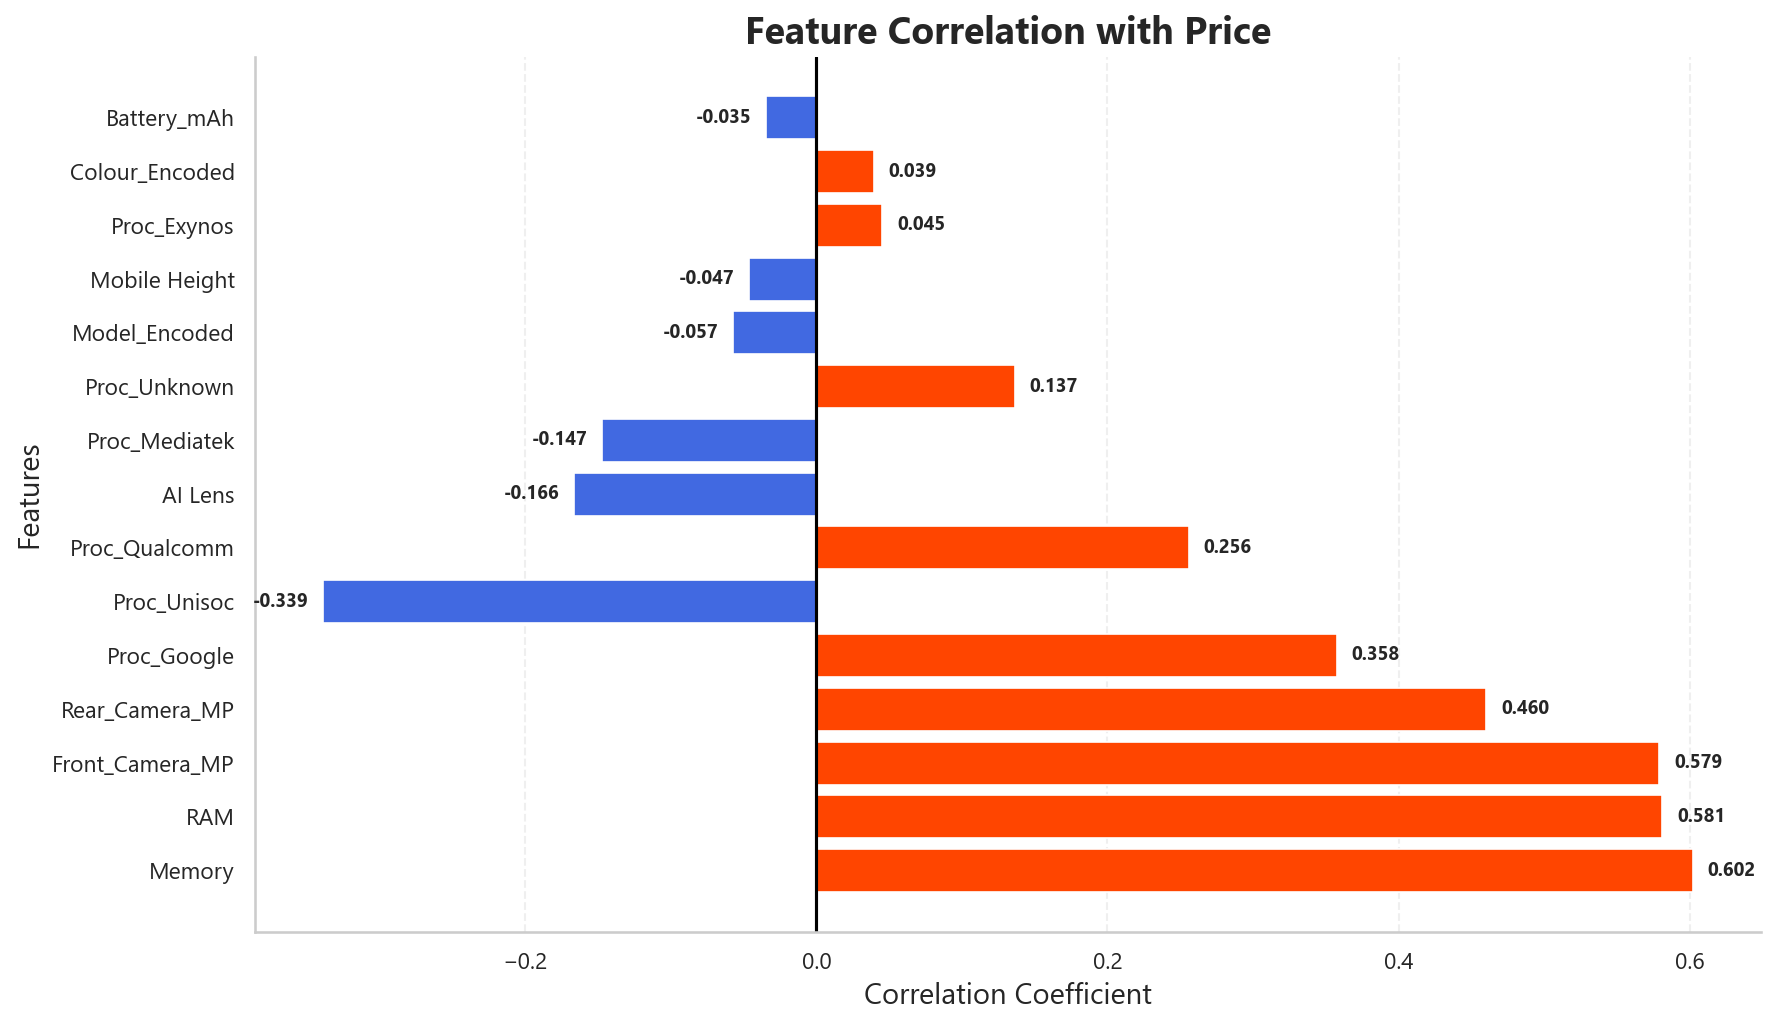

✅ Success: Feature correlation chart with price, generated 


In [47]:
#   Correlation with Price — Bar Chart

price_corr = df_sanitized.corr()['Price'].drop('Price').sort_values(key=abs, ascending=False)

colors = ['orangered' if x > 0 else 'royalblue' for x in price_corr.values ]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(price_corr.index,price_corr.values,color=colors, edgecolor='white', linewidth=0.8)
ax.axvline(x=0, color='black', linewidth=1.5);ax.set_title('Feature Correlation with Price',fontweight='bold');ax.set_xlabel('Correlation Coefficient');ax.set_ylabel('Features');ax.tick_params(labelsize=11)

for bar, val in zip(bars, price_corr.values):
    ax.text(val + (0.01 if val >= 0 else -0.01),bar.get_y() + bar.get_height()/2,f'{val:.3f}',va='center',ha='left' if val >= 0 else 'right',fontsize=9, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.3,axis='x');plt.grid(False,axis='y');plt.tight_layout();plt.savefig('Assets/feature_correlation_price.png',dpi=150, bbox_inches='tight');plt.show()
print("✅ Success: Feature correlation chart with price, generated ")

In [48]:
#   Display Results as HTML Table

feature_corr = price_corr.reset_index()
feature_corr.columns = ['Feature', 'Correlation with Price']
feature_corr['Correlation with Price'] = feature_corr['Correlation with Price'].round(3)
html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">FEATURE CORRELATION<span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Pearson Correlation with Price</i>
    </h2>
</div>
<div style="display: flex; justify-content: center;">
'''
html_content += f'''{feature_corr.to_html(index=False, border=1, justify="center")}'''
html_content += '</div>'
display(HTML(html_content))
print("✅ Success: Features correlation results table generated.")

Feature,Correlation with Price
Memory,0.602
RAM,0.581
Front_Camera_MP,0.579
Rear_Camera_MP,0.460
Proc_Google,0.358
Proc_Unisoc,-0.339
Proc_Qualcomm,0.256
AI Lens,-0.166
Proc_Mediatek,-0.147
Proc_Unknown,0.137


✅ Success: Features correlation results table generated.


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Correlation with Target (Price):**
- **Memory (0.602)** and **RAM (0.581)** show the strongest positive linear correlation with Price — confirming findings from multivariate analysis.
- **Front_Camera_MP (0.579)** is notably close to RAM in correlation strength — an unexpected finding suggesting front camera quality is as important as RAM in driving price.
- **Rear_Camera_MP (0.460)** also shows strong positive correlation.
- **Processor Brand Hierarchy is strictly defined:** **Proc_Google (0.358)** and **Proc_Qualcomm (0.256)** drive prices upward (premium tier), while **Proc_Unisoc (-0.339)** and **Proc_Mediatek (-0.147)** show strong negative correlations, confirming their association with budget-tier devices.
- **Battery_mAh (-0.035)** shows near-zero correlation — confirms battery is not a meaningful linear price predictor.
- **Mobile Height (-0.047)** shows a slight negative correlation. <br> 
Crucial Insight: ***Prior to missing value handling, this feature exhibited a positive correlation.*** The flip to a negative correlation directly highlights how median imputation altered its linear relationship with Price.
- **Model_Encoded (-0.057)** and **Colour_Encoded (0.039)** show near-zero correlation — their price signal is non-linear and will be captured better by tree-based models.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>


<div style="margin-left: 40px; max-width: 90%">

### 📌 SelectKBest — Statistical Feature Significance

<div style="margin-left: 20px; max-width: 90%">

While correlation measures linear relationships, **SelectKBest** applies an F-statistical test to evaluate the significance of each feature's relationship with Price. Features with high F-scores have a statistically meaningful relationship with the target, while features with high p-values (> 0.05) are considered statistically insignificant and may be candidates for removal.

> **Note:** SelectKBest uses the F-statistic — a ratio of explained variance to unexplained variance. 
>Higher F-score = stronger statistical relationship with Price.

</div>
</div>

In [49]:
#   SelectKBest 

X = df_sanitized.drop(columns=['Price'])
y = df_sanitized['Price']

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X, y)
skbest_df = pd.DataFrame({'Feature' : X.columns,'F_Score' : selector.scores_.round(3),'p_Value' : selector.pvalues_.round(4)}).sort_values('F_Score', ascending=False).reset_index(drop=True)
print("✅ Success: SelectKBest analysis complete")

✅ Success: SelectKBest analysis complete


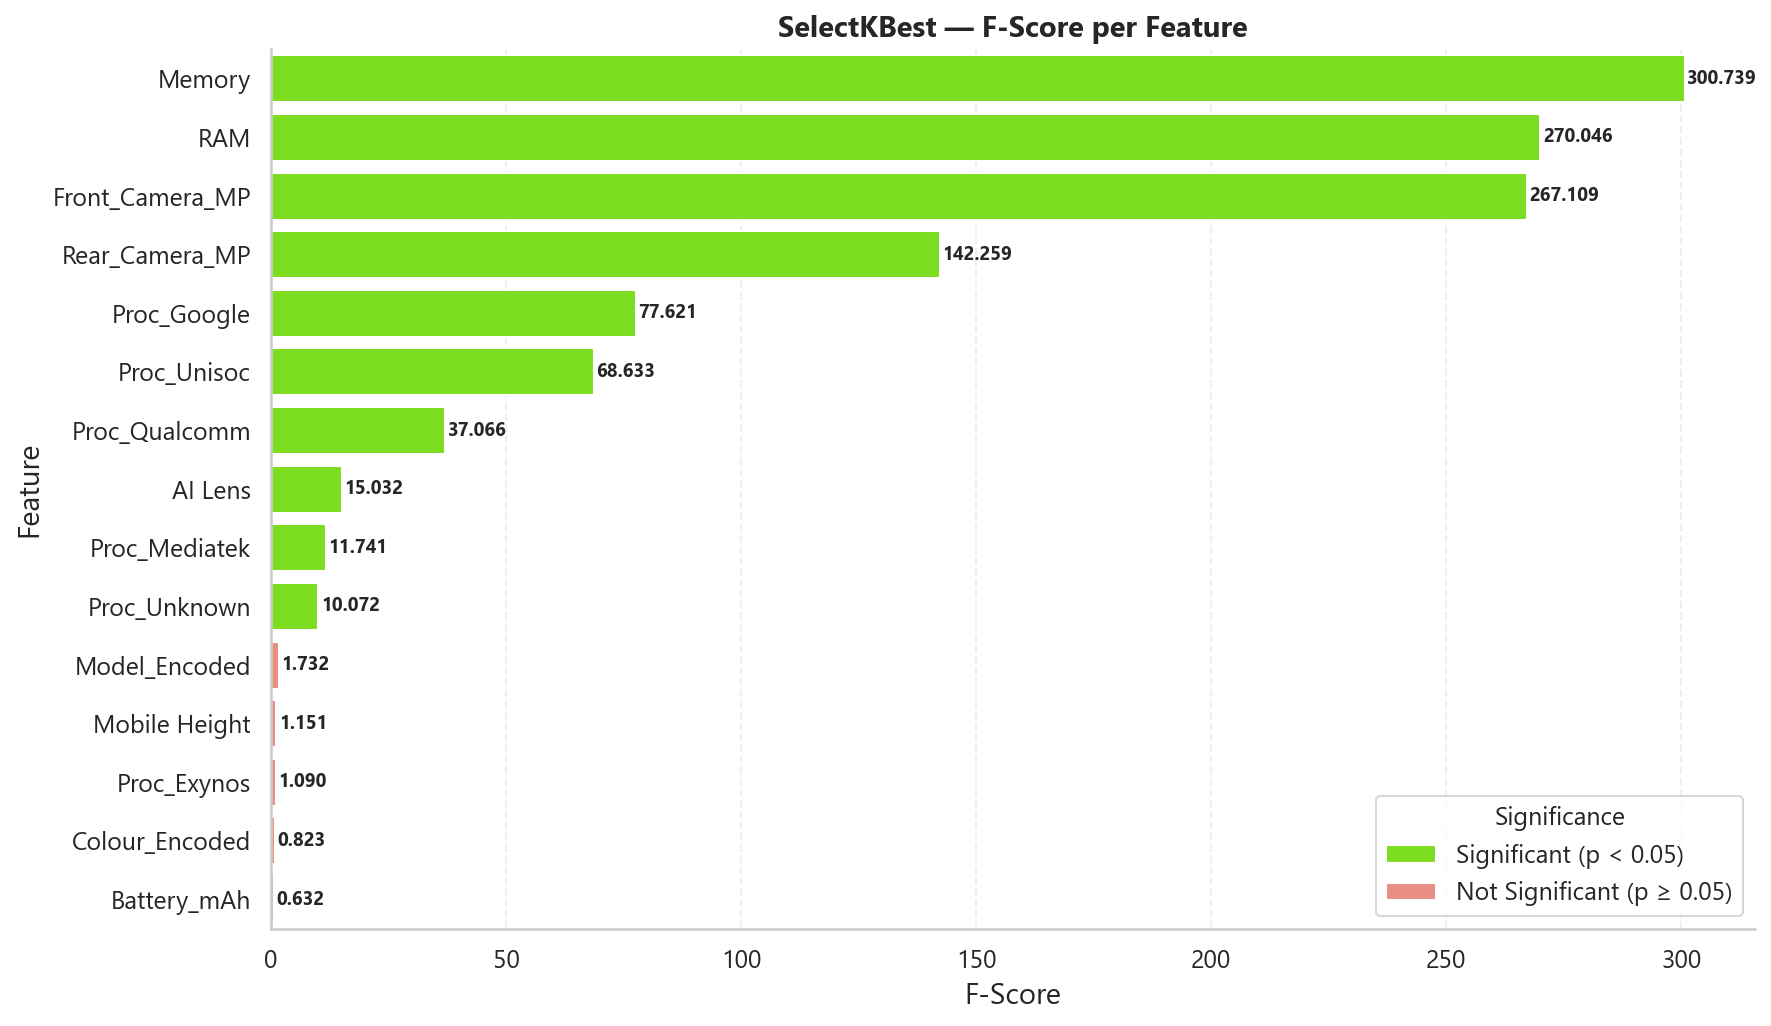

✅ Success: SelectKBest chart generated.


In [50]:
#   F-Score Bar Chart
plot_df = skbest_df.copy()
plot_df['Significance'] = plot_df['p_Value'].apply(lambda x: 'Significant (p < 0.05)' if x < 0.05 else 'Not Significant (p ≥ 0.05)')

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=plot_df, x='F_Score', y='Feature',hue='Significance',palette={'Significant (p < 0.05)': 'lawngreen','Not Significant (p ≥ 0.05)': 'salmon'},ax=ax, edgecolor='white', legend=True)
ax.set_title('SelectKBest — F-Score per Feature',fontweight='bold', fontsize=14);ax.set_xlabel('F-Score');ax.set_ylabel('Feature')

for bar, val in zip(ax.patches, plot_df['F_Score']):
    ax.text(bar.get_width() + 0.5,bar.get_y() + bar.get_height()/2,f'{val:.3f}',va='center', fontsize=9, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.3, axis='x');plt.tight_layout();plt.savefig('Assets/selectkbest_fscore.png',dpi=150, bbox_inches='tight');plt.show()
print("✅ Success: SelectKBest chart generated.")

In [51]:
#   Display Results as HTML Table

skbest_df['Significant'] = skbest_df['p_Value'].apply(lambda x: '✅ Yes' if x < 0.05 else '❌ No')
html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">SELECTKBEST<span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">F-Score and Statistical Significance</i>
    </h2>
</div>
<div style="display: flex; justify-content: center;">
'''
html_content += f'''{skbest_df.to_html(index=False, border=1, justify="center")}'''
html_content += '</div>'
display(HTML(html_content))
print("✅ Success: SelectKBest results table generated.")

Feature,F_Score,p_Value,Significant
Memory,300.739,0.000,✅ Yes
RAM,270.046,0.000,✅ Yes
Front_Camera_MP,267.109,0.000,✅ Yes
Rear_Camera_MP,142.259,0.000,✅ Yes
Proc_Google,77.621,0.000,✅ Yes
Proc_Unisoc,68.633,0.000,✅ Yes
Proc_Qualcomm,37.066,0.000,✅ Yes
AI Lens,15.032,0.000,✅ Yes
Proc_Mediatek,11.741,0.001,✅ Yes
Proc_Unknown,10.072,0.002,✅ Yes


✅ Success: SelectKBest results table generated.


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — SelectKBest:**
- **Memory (300.739)**, **RAM (270.046)**, and **Front_Camera_MP (267.109)** are the top three statistically significant features — all with p-value of 0.000, confirming an extremely strong statistical relationship with Price
- **10 out of 15 features** are statistically significant (p < 0.05) — majority of features carry genuine price information
- **5 features are statistically insignificant** (p ≥ 0.05):
  - `Model_Encoded` (p=0.189) — no linear statistical relationship with Price
  - `Mobile Height` (p=0.284) - after correction of anomalous values through median imputation, no significant linear relationship with Price remains. *Its earlier positive correlation was the result of extreme values present in the raw data.*
  - `Proc_Exynos` (p=0.297) — too few Exynos devices for statistical power
  - `Colour_Encoded` (p=0.365) — colour has no statistically meaningful effect on price
  - `Battery_mAh` (p=0.427) — confirms bivariate finding that battery is not a price driver
- Notably **Proc_Unisoc (F=68.633)** and **Proc_Google (F=77.621)** are highly significant — processor brand extremes (premium Google, budget Unisoc) carry strong statistical price signals
- `AI Lens` despite being a budget feature shows significance (p=0.000, F=15.032) — its negative relationship with price is statistically real.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>

<div style="margin-left: 40px; max-width: 90%">

### 📌 Preliminary Feature Screening (Random Forest)

<div style="margin-left: 20px; max-width: 90%">

A Random Forest model is trained on the full feature set to extract feature signal scores. Unlike correlation and SelectKBest which measure only linear relationships, Random Forest captures non-linear patterns — giving a more complete picture of which features truly drive price prediction. This makes it a valuable third lens for screening, particularly for features that linear methods may undervalue.

</div>
</div>

In [52]:
#   Preliminary Random Forest — Model Training

X = df_sanitized.drop(columns=['Price'])
y = df_sanitized['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_preliminary = RandomForestRegressor(n_estimators=100, random_state=42)
rf_preliminary.fit(X_train, y_train)
screening_df = pd.DataFrame({'Feature': X.columns,'RF Gain Score': rf_preliminary.feature_importances_}).sort_values('RF Gain Score', ascending=False).reset_index(drop=True)
print("✅ Success: Preliminary RF screening complete")

✅ Success: Preliminary RF screening complete


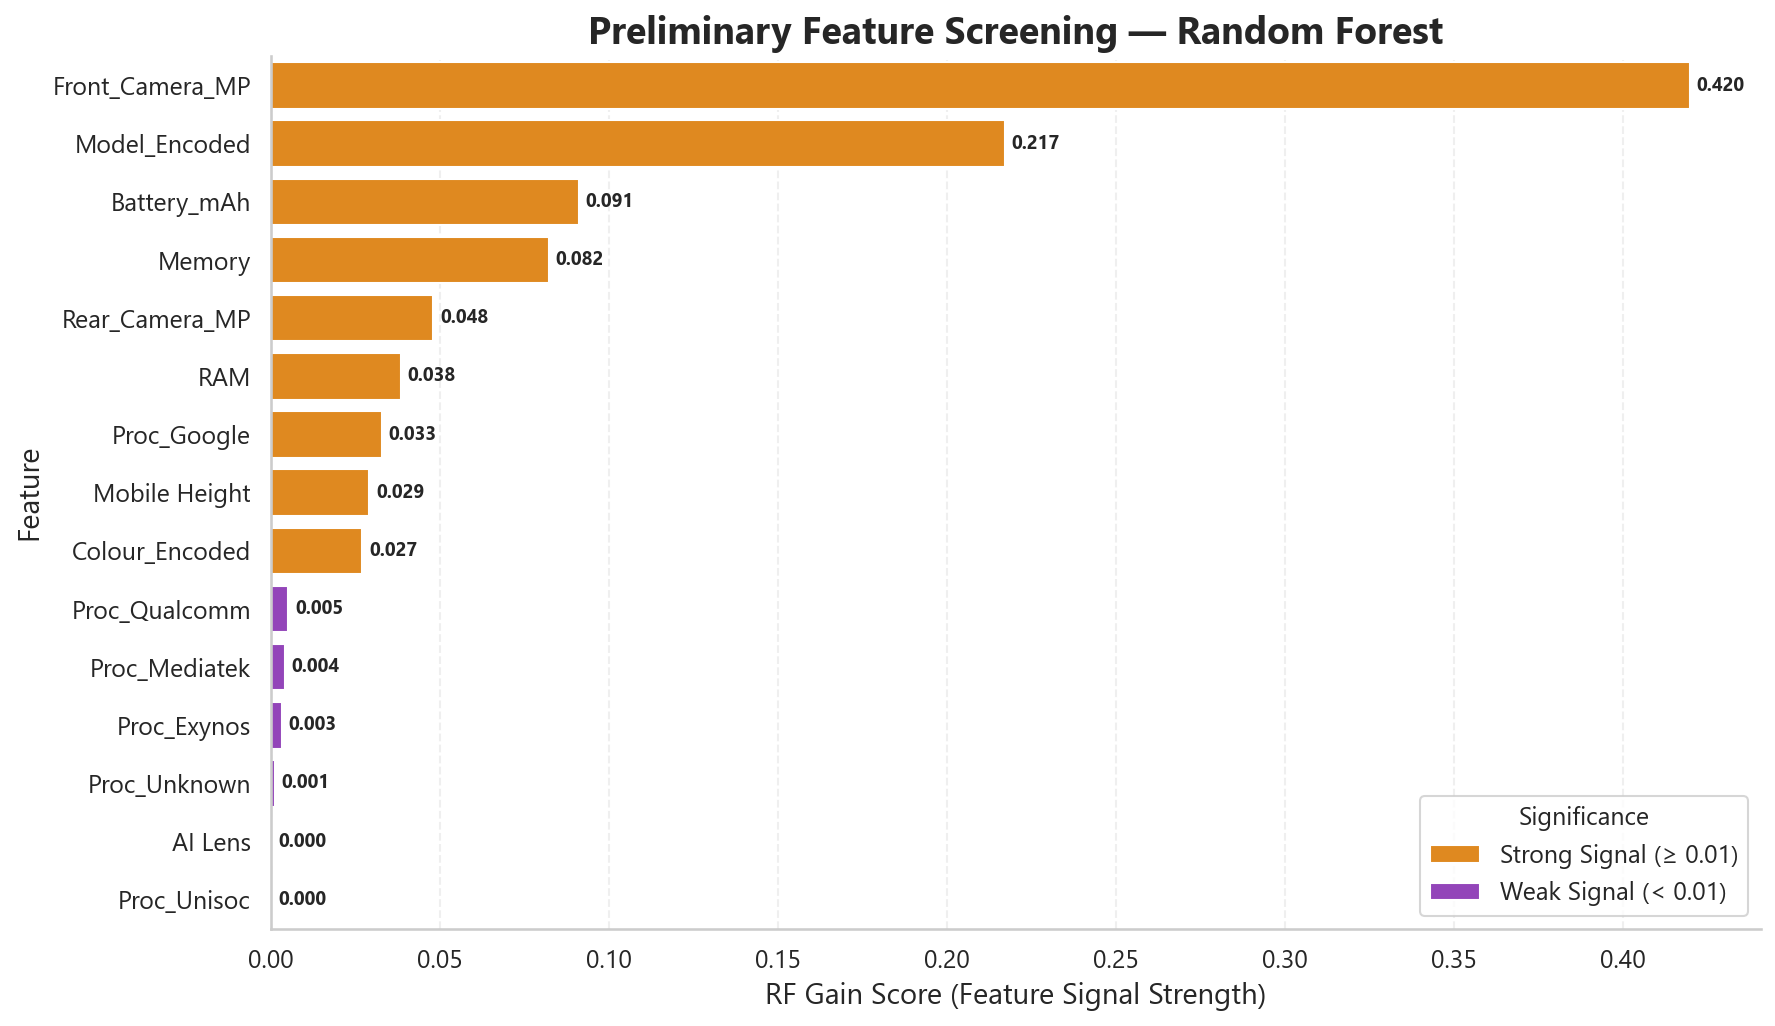

✅ Success: Preliminary Feature Screening bar chart generated.


In [53]:
#   Preliminary Feature Screening — Bar Chart
rf_plot_df = screening_df.copy()
rf_plot_df['Significance'] = rf_plot_df['RF Gain Score'].apply(lambda x: 'Strong Signal (≥ 0.01)' if x >= 0.01 else 'Weak Signal (< 0.01)')

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=rf_plot_df, x='RF Gain Score', y='Feature',hue='Significance',palette={'Strong Signal (≥ 0.01)': 'darkorange','Weak Signal (< 0.01)': 'darkorchid'},ax=ax,edgecolor='white', legend=True)
ax.set_title('Preliminary Feature Screening — Random Forest',fontweight='bold');ax.set_xlabel('RF Gain Score (Feature Signal Strength)');ax.set_ylabel('Feature')

for bar, val in zip(ax.patches, rf_plot_df['RF Gain Score']):
    ax.text(bar.get_width() + 0.002,bar.get_y() + bar.get_height()/2,f'{val:.3f}',va='center', fontsize=9, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.3, axis='x');plt.tight_layout();plt.savefig('Assets/feature_signal_strength_RF.png',dpi=150, bbox_inches='tight');plt.show()
print("✅ Success: Preliminary Feature Screening bar chart generated.")

In [54]:
#   Display Results as HTML Table

screening_df['Signal Strength'] = screening_df['RF Gain Score'].apply(lambda x: '⚡ Strong' if x >= 0.01 else '➖ Weak')
html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">RANDOM FOREST<span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">RF Gain and Signal Strength</i>
    </h2>
</div>
<div style="display: flex; justify-content: center;">
'''
html_content += f'''{screening_df.to_html(index=False, border=1, justify="center")}'''
html_content += '</div>'
display(HTML(html_content))
print("✅ Success: Preliminary Random Forest trained.")

Feature,RF Gain Score,Signal Strength
Front_Camera_MP,0.420,⚡ Strong
Model_Encoded,0.217,⚡ Strong
Battery_mAh,0.091,⚡ Strong
Memory,0.082,⚡ Strong
Rear_Camera_MP,0.048,⚡ Strong
RAM,0.038,⚡ Strong
Proc_Google,0.033,⚡ Strong
Mobile Height,0.029,⚡ Strong
Colour_Encoded,0.027,⚡ Strong
Proc_Qualcomm,0.005,➖ Weak


✅ Success: Preliminary Random Forest trained.


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Preliminary Feature Screening (Random Forest):**
- **Front_Camera_MP (0.420)** is the single most dominant feature — capturing 42% of the total RF gain score. This strong non-linear signal was underrepresented in correlation analysis (rank 3rd, r=0.579) and ranked only 3rd in SelectKBest — confirming that linear methods alone would have underestimated this feature's true predictive value.
- **Model_Encoded (0.217)** ranks second despite being statistically insignificant in SelectKBest (p=0.189). Random Forest detects strong non-linear pricing signal in model name encoding that the F-test is structurally unable to capture — a key disagreement between methods that will require careful resolution.
- **Battery_mAh (0.091)** ranks third — a significant surprise given its near-zero correlation (−0.035) and SelectKBest insignificance (p=0.427). Random Forest identifies a non-linear battery-price relationship that is completely invisible to linear methods — another key disagreement requiring resolution.
- **All individual processor brand columns apart from `Proc_Google` rank below the 0.01 threshold** — their combined signal is real but fragmented across 6 binary columns after one-hot encoding, reducing each column's individual score below the meaningful threshold.
- **AI Lens (0.000) and Proc_Unisoc (0.000)** show zero RF gain score — consistent with their poor rankings across all three screening methods, making them strong candidates for removal.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>

<div style="margin-left: 40px; max-width: 90%">

### 📌 Three-Method Comparison & Feature Validation

<div style="margin-left: 20px; max-width: 90%">

Each feature analysis method views the data through a different lens. Correlation measures linear signal, SelectKBest measures statistical significance, and Random Forest measures non-linear predictive contribution. By comparing the rankings produced by all three methods, we can identify features that consistently demonstrate predictive value, investigate disagreements between methods, and make an evidence-based feature selection decision before model training.

</div>
</div>

In [55]:
#    Three-Method Comparison Table

corr_rank = (price_corr.abs().rank(ascending=False, method='min').astype(int))
kbest_rank = (skbest_df.set_index('Feature')['F_Score'].rank(ascending=False, method='min').astype(int))
rf_rank = (screening_df.set_index('Feature')['RF Gain Score'].rank(ascending=False, method='min').astype(int))

comparison_df = pd.DataFrame({'Correlation_Rank': corr_rank,'SelectKBest_Rank': kbest_rank,'RandomForest_Rank': rf_rank})
comparison_df['Average_Rank'] = (comparison_df.mean(axis=1)).round(2)
comparison_df = (comparison_df.sort_values('Average_Rank').reset_index().rename(columns={'index':'Feature'}))

def highlight_features(row):
    top_features,conflict_features,deferred_features,drop_features = ['Memory', 'Front_Camera_MP', 'RAM', 'Rear_Camera_MP'],['Model_Encoded', 'Battery_mAh', 'AI Lens'],[ 'Mobile Height'],['Colour_Encoded', 'Proc_Exynos', 'Proc_Unknown']
    if row['Feature'] in top_features:
        return ['background-color: rgba(57, 168, 102, 0.20)'] * len(row)
    elif row['Feature'] in conflict_features:
        return ['background-color: rgba(247, 226, 30, 0.20)'] * len(row)
    elif row['Feature'] in deferred_features:
        return ['background-color: rgba(250, 146, 20, 0.20)'] * len(row)
    elif row['Feature'] in drop_features:
        return ['background-color: rgba(248, 81, 73, 0.20)'] * len(row)
    else:
        return [''] * len(row)

styled_comparison = (comparison_df.style.apply(highlight_features, axis=1).format({'Average_Rank': '{:.2f}'}).hide(axis='index').set_properties(**{'text-align': 'center','font-size': '13px','padding': '6px 16px','color': 'white'}).set_table_styles([{'selector': 'th','props': [('background-color', '#2d2d2d'),('color', '#8B949E'),('font-weight', 'bold'),('text-align', 'center'),('padding', '8px 16px')]},{'selector': 'td','props': [('color', 'white')]}]))

html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 15px;border: 1px solid #555; border-radius: 6px;background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">FEATURE VALIDATION<span style="opacity: 0.5; margin: 0 10px;">|</span>
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Three-Method Comparison</i>
    </h2>
</div>
'''
html_content += '''
<div style=" display: flex; justify-content: center; gap: 30px;margin-bottom: 18px; font-size: 13px;">
    <span style="color: #39A866;">■ Consensus — Strong Signal</span>
    <span style="color: #DECD31;">■ Conflicting — Empirical Experiment Required</span>
    <span style="color: #FAA237;">■ Directional Conflict — Deferred to FCT</span>
    <span style="color: #F85149;">■ Consistent Bottom — Drop Candidate</span>
</div>
'''
html_content += '<div style="display: flex; justify-content: center;">'
html_content += styled_comparison.to_html()
html_content += '</div>'
display(HTML(html_content))
print("✅ Success: Three-method comparison table with decision highlights generated")

Feature,Correlation_Rank,SelectKBest_Rank,RandomForest_Rank,Average_Rank
Memory,1,1,4,2.00
Front_Camera_MP,3,3,1,2.33
RAM,2,2,6,3.33
Rear_Camera_MP,4,4,5,4.33
Proc_Google,5,5,7,5.67
Proc_Qualcomm,7,7,10,8.00
Model_Encoded,11,11,2,8.00
Proc_Unisoc,6,6,15,9.00
Proc_Mediatek,9,9,11,9.67
AI Lens,8,8,14,10.00


✅ Success: Three-method comparison table with decision highlights generated


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Three-Method Feature Validation:**
- **Memory (Avg Rank: 2.0)**, **Front_Camera_MP (2.33)**, **RAM (3.33)**, and **Rear_Camera_MP (4.33)** rank consistently in the top 5 across all three methods — these are the most reliable price predictors with strong agreement across all three feature selection methods
- **Model_Encoded** shows the sharpest disagreement in the entire table — ranked 11th by both Correlation and SelectKBest, yet 2nd by the Random Forest screen. This suggests that the phone brand and model identity carries genuine pricing power that linear methods cannot measure, because its influence is captured through decision patterns rather than a simple linear relationship with price.
- **Battery_mAh** shows a similar but less extreme pattern — ranked last (15th) by both linear methods yet 3rd by the Random Forest screen. This suggests battery capacity influences price in a non-straightforward way — through threshold-based decision patterns that tree-based models capture more effectively than linear methods.
- **Mobile Height (Avg Rank: 10.67)** shows a directional disagreement — ranked 12th by linear methods but 7th by Random Forest. This conflict is noted but not resolved through a separate empirical experiment; its contribution will be evaluated directly through the Feature Contribution Test in the Final Model section.
- **Colour_Encoded (12.33)**, **Proc_Exynos (12.67)**, and **Proc_Unknown (11.00)** rank consistently near the bottom across all three methods — these features carry minimal predictive value and are strong candidates for removal.
- **Proc_Unisoc (Avg Rank: 9.0)** shows a directional disagreement opposite to Model_Encoded and Battery_mAh — ranked 6th by both linear methods but 15th by Random Forest. Its linear signal is genuine (a strong negative correlation with price confirms that Unisoc-powered devices are consistently budget-priced), its information is already captured by other features, leaving little additional value for the Random Forest model. This reflects a difference in how the methods measure signals rather than a conflict requiring empirical experiment.
- The disagreement between methods for `Model_Encoded`, `Battery_mAh`, and `AI Lens` could not be resolved through rankings alone — empirical experiments will be performed for all three in the next section to make evidence-based retention decisions.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>

<div style="margin-left: 20px; max-width: 90%">

### 📌 Empirical Feature Experiments

<div style="margin-left: 20px; max-width: 90%">

The Three-Method Comparison revealed three conflicting signals that cannot be resolved through ranking alone:

- `Model_Encoded` — ranked 11th by Correlation and SelectKBest, but 2nd by Random Forest screening.
- `Battery_mAh` — ranked 15th by Linear methods, but 3rd by Random Forest screening.
- `AI Lens` — statistically significant (p < 0.05) but zero RF gain score.

Rather than making assumption-based decisions, we resolve all three conflicts empirically — training a Random Forest model with and without each feature and directly measuring the impact on MAE and R².

</div>
</div>

In [56]:
#   Model_Encoded Impact Experiment

X_full    = df_sanitized.drop(columns=['Price'])
X_without = df_sanitized.drop(columns=['Price', 'Model_Encoded'])
y         = df_sanitized['Price']

results = {}
for name, X in [('With Model_Encoded', X_full), ('Without Model_Encoded', X_without)]:
    rf_experiment = RandomForestRegressor(n_estimators=100, random_state=42)
    mae_scores = -cross_val_score(rf_experiment, X, y, cv=5, scoring='neg_mean_absolute_error')
    r2_scores  = cross_val_score(rf_experiment, X, y, cv=5, scoring='r2')
    results[name] = {'MAE': round(mae_scores.mean()), 'R²': round(r2_scores.mean(), 4)}

mae_with    = results['With Model_Encoded']['MAE']
mae_without = results['Without Model_Encoded']['MAE']
r2_with     = results['With Model_Encoded']['R²']
r2_without  = results['Without Model_Encoded']['R²']

mae_diff = mae_without - mae_with
r2_diff  = r2_without  - r2_with
mae_diff_str = f'+₹{mae_diff:,.0f} worse' if mae_diff > 0 else f'-₹{abs(mae_diff):,.0f} better'
r2_diff_str  = f'{r2_diff:.4f} better' if r2_diff > 0 else f'{r2_diff:.4f} worse'
print("✅ Success: 'Model_Encoded' 5-fold CV experiment complete.")

✅ Success: 'Model_Encoded' 5-fold CV experiment complete.


In [57]:
#   Model_Encoded HTML Table

html_content = f'''
<div style="text-align: center; padding: 12px; margin-bottom: 25px;border: 1px solid #555; border-radius: 6px;background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">MODEL_ENCODED EXPERIMENT<span style="opacity: 0.5; margin: 0 10px;">|</span>
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Impact on Random Forest Performance</i>
    </h2>
</div>
<div style="display: flex; justify-content: center; margin-bottom: 20px;">
    <table style="border-collapse: collapse; background-color: #1E1E1E;border: 1px solid #333; color: #CCCCCC; font-size: 0.95em;">
        <tr><th style="padding: 10px 30px; text-align: center;border-bottom: 2px solid #333;"><b>Metric</b></th>
            <th style="padding: 10px 30px; text-align: center;border-bottom: 2px solid #333;"><b>With Model_Encoded</b></th>
            <th style="padding: 10px 30px; text-align: center;border-bottom: 2px solid #333;"><b>Without Model_Encoded</b></th>
            <th style="padding: 10px 30px; text-align: center;border-bottom: 2px solid #333;"><b>Difference</b></th></tr>
        <tr><td style="padding: 10px 30px; text-align: center;border-bottom: 1px solid #333;">MAE</td>
            <td style="padding: 10px 30px; text-align: center;border-bottom: 1px solid #333;">₹{mae_with:,.0f}</td>
            <td style="padding: 10px 30px; text-align: center;border-bottom: 1px solid #333;">₹{mae_without:,.0f}</td>
            <td style="padding: 10px 30px; text-align: center;border-bottom: 1px solid #333; color: #FF645E;font-weight: bold;">{mae_diff_str}</td></tr>
        <tr><td style="padding: 10px 30px; text-align: center;">R²</td>
            <td style="padding: 10px 30px; text-align: center;">{r2_with:.4f}</td>
            <td style="padding: 10px 30px; text-align: center;">{r2_without:.4f}</td>
            <td style="padding: 10px 30px; text-align: center;color: #FF645E; font-weight: bold;">{r2_diff_str}</td>
        </tr>
    </table>
</div>
'''
display(HTML(html_content))

Metric,With Model_Encoded,Without Model_Encoded,Difference
MAE,"₹2,712","₹2,908",+₹196 worse
R²,0.6850,0.6646,-0.0204 worse


<div style="margin-left: 60px; max-width: 90%">

🔍 **Experiment Decision**

Removing `Model_Encoded` caused MAE to worsen by **₹196** and R² to drop by **0.0204**. While the drop is modest, it is consistent across both metrics — confirming that `Model_Encoded` carries genuine pricing signal that improves model performance.

**✅ Decision: Retain `Model_Encoded` in the final feature set.**

The non-linear price information embedded in phone model identity is real and measurable. The **Random Forest rank 2 or Gain Score of 0.217** is validated by empirical evidence.

</div>

In [58]:
#   Battery Impact Experiment

X_full_batt    = df_sanitized.drop(columns=['Price'])
X_without_batt = df_sanitized.drop(columns=['Price', 'Battery_mAh'])
y = df_sanitized['Price']

results_batt = {}
for name, X in [('With Battery', X_full_batt), ('Without Battery', X_without_batt)]:
    rf_batt_experiment = RandomForestRegressor(n_estimators=100, random_state=42)
    mae_scores = -cross_val_score(rf_batt_experiment, X, y, cv=5, scoring='neg_mean_absolute_error')
    r2_scores  = cross_val_score(rf_batt_experiment, X, y, cv=5, scoring='r2')
    results_batt[name] = {'MAE': round(mae_scores.mean()), 'R²': round(r2_scores.mean(), 4)}

mae_with    = results_batt['With Battery']['MAE']
mae_without = results_batt['Without Battery']['MAE']
r2_with     = results_batt['With Battery']['R²']
r2_without  = results_batt['Without Battery']['R²']

mae_diff = mae_without - mae_with
r2_diff  = r2_without  - r2_with
mae_diff_str = f'+₹{mae_diff:,.0f} worse' if mae_diff > 0 else f'-₹{abs(mae_diff):,.0f} better'
r2_diff_str  = f'{r2_diff:.4f} better' if r2_diff > 0 else f'{r2_diff:.4f} worse'

print("✅ Success: Battery experiment complete.")

✅ Success: Battery experiment complete.


In [59]:
#   battery_mAh HTML Table

html_content = f'''
<div style="text-align: center; padding: 12px; margin-bottom: 25px;border: 1px solid #555; border-radius: 6px;background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">BATTERY EXPERIMENT<span style="opacity: 0.5; margin: 0 10px;">|</span>
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Impact on Random Forest Performance</i>
    </h2>
</div>
<div style="display: flex; justify-content: center; margin-bottom: 20px;">
    <table style="border-collapse: collapse; background-color: #1E1E1E;border: 1px solid #333; color: #CCCCCC; font-size: 0.95em;">
        <tr><th style="padding: 10px 30px; text-align: center;border-bottom: 2px solid #333;"><b>Metric</b></th>
            <th style="padding: 10px 30px; text-align: center;border-bottom: 2px solid #333;"><b>With Battery</b></th>
            <th style="padding: 10px 30px; text-align: center;border-bottom: 2px solid #333;"><b>Without Battery</b></th>
            <th style="padding: 10px 30px; text-align: center;border-bottom: 2px solid #333;"><b>Difference</b></th></tr>
        <tr><td style="padding: 10px 30px; text-align: center;border-bottom: 1px solid #333;">MAE</td>
            <td style="padding: 10px 30px; text-align: center;border-bottom: 1px solid #333;">₹{mae_with:,.0f}</td>
            <td style="padding: 10px 30px; text-align: center;border-bottom: 1px solid #333;">₹{mae_without:,.0f}</td>
            <td style="padding: 10px 30px; text-align: center;border-bottom: 1px solid #333; color: #FF645E;font-weight: bold;">{mae_diff_str}</td></tr>
        <tr><td style="padding: 10px 30px; text-align: center;">R²</td>
            <td style="padding: 10px 30px; text-align: center;">{r2_with:.4f}</td>
            <td style="padding: 10px 30px; text-align: center;">{r2_without:.4f}</td>
            <td style="padding: 10px 30px; text-align: center;color: #FF645E; font-weight: bold;">{r2_diff_str}</td>
        </tr>
    </table>
</div>
'''
display(HTML(html_content))

Metric,With Battery,Without Battery,Difference
MAE,"₹2,712","₹3,031",+₹319 worse
R²,0.6850,0.6268,-0.0582 worse


<div style="margin-left: 40px; max-width: 90%">

🔍 **Battery_mAh Experiment Decision**

Removing `Battery_mAh` worsened both metrics meaningfully — MAE increased by **₹319** and R² dropped by **0.0582**. Despite near-zero linear correlation **-0.035**, Battery_mAh carries genuine non-linear predictive signal captured by Random Forest.

**✅ Decision: Retain `Battery_mAh` in the final feature set.**

</div>

In [60]:
#   AI Lens Impact Experiment

X_full_lens    = df_sanitized.drop(columns=['Price'])
X_without_lens = df_sanitized.drop(columns=['Price', 'AI Lens'])
y = df_sanitized['Price']

results_lens = {}
for name, X in [('With AI Lens', X_full_lens), ('Without AI Lens', X_without_lens)]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    rf_lens_experiment = RandomForestRegressor(n_estimators=100, random_state=42)
    mae_scores = -cross_val_score(rf_lens_experiment, X, y, cv=5, scoring='neg_mean_absolute_error')
    r2_scores  = cross_val_score(rf_lens_experiment, X, y, cv=5, scoring='r2')
    results_lens[name] = {'MAE': round(mae_scores.mean()), 'R²': round(r2_scores.mean(), 4)}

mae_with    = results_lens['With AI Lens']['MAE']
mae_without = results_lens['Without AI Lens']['MAE']
r2_with     = results_lens['With AI Lens']['R²']
r2_without  = results_lens['Without AI Lens']['R²']

mae_diff = mae_without - mae_with
r2_diff  = r2_without  - r2_with
mae_diff_str = f'+₹{abs(mae_diff):,.0f} negligible'
r2_diff_str  = f'{r2_diff:.4f} negligible'
print("✅ Success: AI Lens experiment complete.")

✅ Success: AI Lens experiment complete.


In [61]:
#   AI Lens HTML Table

html_content = f'''
<div style="text-align: center; padding: 12px; margin-bottom: 25px;border: 1px solid #555; border-radius: 6px;background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">AI LENS EXPERIMENT<span style="opacity: 0.5; margin: 0 10px;">|</span>
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Impact on Random Forest Performance</i>
    </h2>
</div>
<div style="display: flex; justify-content: center; margin-bottom: 20px;">
    <table style="border-collapse: collapse; background-color: #1E1E1E;border: 1px solid #333; color: #CCCCCC; font-size: 0.95em;">
        <tr><th style="padding: 10px 30px; text-align: center;border-bottom: 2px solid #333;"><b>Metric</b></th>
            <th style="padding: 10px 30px; text-align: center;border-bottom: 2px solid #333;"><b>With AI Lens</b></th>
            <th style="padding: 10px 30px; text-align: center;border-bottom: 2px solid #333;"><b>Without AI Lens</b></th>
            <th style="padding: 10px 30px; text-align: center;border-bottom: 2px solid #333;"><b>Difference</b></th></tr>
        <tr><td style="padding: 10px 30px; text-align: center;border-bottom: 1px solid #333;">MAE</td>
            <td style="padding: 10px 30px; text-align: center;border-bottom: 1px solid #333;">₹{mae_with:,.0f}</td>
            <td style="padding: 10px 30px; text-align: center;border-bottom: 1px solid #333;">₹{mae_without:,.0f}</td>
            <td style="padding: 10px 30px; text-align: center;border-bottom: 1px solid #333; color: #FFA11F;font-weight: bold;">{mae_diff_str}</td></tr>
        <tr><td style="padding: 10px 30px; text-align: center;">R²</td>
            <td style="padding: 10px 30px; text-align: center;">{r2_with:.4f}</td>
            <td style="padding: 10px 30px; text-align: center;">{r2_without:.4f}</td>
            <td style="padding: 10px 30px; text-align: center;color: #FFA11F; font-weight: bold;">{r2_diff_str}</td>
        </tr>
    </table>
</div>
'''
display(HTML(html_content))

Metric,With AI Lens,Without AI Lens,Difference
MAE,"₹2,712","₹2,729",+₹17 negligible
R²,0.6850,0.6847,-0.0003 negligible


<div style="margin-left: 60px; max-width: 90%">

🔍 **AI Lens Experiment Decision**

Removing `AI Lens` produced a negligible change in both metrics — MAE increased by **₹17** (0.6% relative change) and R² dropped by **0.0003**, effects too small to be considered meaningful evidence in either direction.

**✅ Decision: Drop `AI Lens` from the final feature set.**

The near-zero standalone impact confirms the original screening signal — `AI Lens` scored a Random Forest Gain of ~0 and ranked last (14th of 15) despite statistical significance in SelectKBest. With no measurable cost to removing it, it is dropped in favor of a simpler, more parsimonious feature set.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>

<div style="margin-left: 40px; max-width: 90%">

### 📌 Final Feature Set Decision

<div style="margin-left: 20px; max-width: 90%">

Based on evidence from all three screening methods and three empirical experiments, we now finalise the feature set entering model training. Features are dropped only where multiple methods agree, where empirical experiments confirm removal improves performance, or where impact is confirmed negligible in favor of a simpler feature set.

**Drop decisions:**
- `AI Lens` — empirically confirmed negligible impact (±0.6% MAE change); consistent with its near-zero Random Forest gain score and bottom-tier rank despite SelectKBest significance.
- `Colour_Encoded` — consistently ranked bottom across all three screening methods.
- `Proc_Exynos` — consistently ranked bottom across all three screening methods.
- `Proc_Unknown` — consistently ranked bottom across all three screening methods.

**Retain decisions:**
- `Model_Encoded` — empirically confirmed; removal worsened both metrics.
- `Battery_mAh` — empirically confirmed; removal worsened both metrics.
- `Mobile Height` — directional conflict noted across methods; no separate experiment conducted. Contribution validated through the Feature Contribution Test in the Final Model section.
- All remaining features — consistent top or mid rankings across all three screening methods.

</div>
</div>

In [62]:
#   Final Feature Selection 

features_to_drop = ['AI Lens', 'Colour_Encoded', 'Proc_Exynos', 'Proc_Unknown']

df_model = df_sanitized.drop(columns=features_to_drop)

print("=" * 80)
print(f"  Features dropped : {features_to_drop}")
print(f"  Shape before     : {df_sanitized.shape}")
print(f"  Shape after      : {df_model.shape}")
print(f"  Features in model: {df_model.shape[1] - 1}")
print(f"  Target column    : Price")
print("=" * 80)
print("\nFinal feature list:")
print([col for col in df_model.columns if col != 'Price'])

  Features dropped : ['AI Lens', 'Colour_Encoded', 'Proc_Exynos', 'Proc_Unknown']
  Shape before     : (531, 16)
  Shape after      : (531, 12)
  Features in model: 11
  Target column    : Price

Final feature list:
['Memory', 'RAM', 'Battery_mAh', 'Mobile Height', 'Rear_Camera_MP', 'Front_Camera_MP', 'Model_Encoded', 'Proc_Google', 'Proc_Mediatek', 'Proc_Qualcomm', 'Proc_Unisoc']


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Final Feature Set Decision:**
- Final feature set contains **11 features** entering all four models, reduced from 15 post-encoding features.
- **4 features dropped** based on multi-method consensus and empirical evidence:
  - `AI Lens` — removal produced a negligible change (MAE +₹17, R² −0.0003), consistent with its near-zero Random Forest gain and bottom-tier rank despite SelectKBest significance; dropped in favor of a simpler feature set.
  - `Colour_Encoded` — ranked 14th, 14th, and 9th across all three methods — no meaningful price signal.
  - `Proc_Exynos` — ranked 13th, 13th, and 12th — consistently negligible across all methods.
  - `Proc_Unknown` — ranked 10th, 10th, and 13th — no consistent predictive value.
- **2 features retained through empirical experiment:**
  - `Model_Encoded` — removal worsened MAE by ₹196 and R² by 0.0204.
  - `Battery_mAh` — removal worsened MAE by ₹319 and R² by 0.0582.
- **Mobile Height** retained based on Random Forest rank 8 — directional conflict with linear methods noted but resolved through the Feature Contribution Test in the Final Model section rather than a separate experiment here.
- The final 11-feature set is backed by three screening methods and three empirical experiments — no feature was removed without evidence from at least two sources.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>

<div style="margin-left: 20px; max-width: 90%">

📊 **Feature Extraction & Selection — Summary:**

- Three complementary screening methods evaluated all 15 features from linear, statistical and non-linear perspectives.
- **Consensus top features** — Memory, RAM, Front_Camera_MP, Rear_Camera_MP — consistently ranked across all three methods with the strongest combined evidence.
- **Three empirical experiments** resolved conflicting signals for Model_Encoded, Battery_mAh, and AI Lens — turning method disagreements into evidence-based decisions.
- **Mobile Height** was retained based on Random Forest signal; its contribution is formally validated in the Final Model section through the Feature Contribution Test.
- The final 11-feature set enters all four models under identical conditions — giving the race a clean, evidence-backed starting point.

</div>

<div style="text-align: center; margin: 30px 0;">
<hr style="width: 45%; border: none; border-top: 2px solid #444;">
<h3 style="color: #4CAF50; letter-spacing: 1px; font-weight: 500;">🤔 Choosing Our Models — The Rationale</h3>
</div>

<div style="margin-left: 20px; max-width: 90%">

Our EDA and feature screening revealed several important characteristics about this dataset that directly inform our model selection:

- **Non-linear relationships dominate** — Front_Camera_MP ranked highest in RF screening (gain score: 0.420) despite moderate linear correlation (0.579), confirming non-linear patterns exist beyond what linear methods can detect.
- **Brand identity carry non-linear pricing signal** — Model_Encoded (187 categories) was empirically validated to carry genuine non-linear pricing signal, removal worsened MAE by ₹196, confirming it carries genuine non-linear pricing signal.
- **Right-skewed target variable** — Price distribution confirmed non-normal in Q-Q plot analysis, which directly challenges Linear Regression's normality assumption for residuals.
- **Mixed feature signals** — some features show strong linear correlation (Memory, RAM) while others show non-linear predictive signal (Battery_mAh, Front_Camera_MP) — requiring both linear and tree-based models for a fair, complete comparison.

Given these characteristics, we select four models that progress from simplest to most complex — allowing us to measure the incremental value of added complexity and determine the best approach for this specific dataset:

| # | Model | Type | Why Selected |
|---|---|---|---|
| 1 | Linear Regression | Baseline | Establishes minimum benchmark — tests if linear relationships alone are sufficient |
| 2 | Decision Tree | Rule-based | Introduces non-linearity through interpretable if-else splits on key features |
| 3 | Random Forest | Bagging Ensemble | Reduces overfitting by averaging multiple trees — stable non-linear predictions |
| 4 | XGBoost | Boosting Ensemble | Sequentially corrects errors tree-by-tree — state-of-the-art for tabular data |

All four models will be trained on the **same 80/20 train-test split** with **identical random state (42)** — ensuring a controlled, directly comparable evaluation.

<hr style="width: 45%; border: none; border-top: 2px solid #444;">
</div>

## 06. Model Building & Tuning — The Race

<div style="margin-left: 20px; max-width: 90%">

Four models are initially trained on the same dataset split and evaluated under identical conditions — ensuring a controlled, directly comparable evaluation. Models progress from simplest to most complex, allowing us to measure the incremental value of complexity at each step. 

Once the baseline algorithms complete the "race," the most stable and robust champion model will undergo rigorous **Hyperparameter Tuning** to finalize its predictive power.

| Model | Type | Purpose |
|---|---|---|
| Linear Regression | Baseline | *Establishes minimum performance benchmark* |
| Decision Tree | Rule-based | *Simple non-linear model* |
| Random Forest | Bagging Ensemble | *Captures non-linear relationships* |
| XGBoost | Boosting Ensemble | *Best-in-class for tabular data* |

</div>

<div style="margin-left: 20px; max-width: 90%">

### 📌Train-Test Split

<div style="margin-left: 20px; max-width: 90%">

The dataset is split into 80% training and 20% testing sets using a fixed random state of 42 — ensuring reproducibility and identical conditions across all four models.

</div>
</div>

In [63]:
#   Train-Test Split

X = df_model.drop(columns=['Price'])
y = df_model['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=" * 45)
print(f"  Total samples  : {len(df_model)}")
print(f"  Training set   : {X_train.shape[0]} rows ({X_train.shape[0]/len(df_model)*100:.0f}%)")
print(f"  Testing set    : {X_test.shape[0]} rows ({X_test.shape[0]/len(df_model)*100:.0f}%)")
print(f"  Features       : {X_train.shape[1]}")
print(f"  Target         : Price")
print("=" * 45)

  Total samples  : 531
  Training set   : 424 rows (80%)
  Testing set    : 107 rows (20%)
  Features       : 11
  Target         : Price


<div style="margin-left: 20px; max-width: 90%">

### 📌 Model 1 — Linear Regression

<div style="margin-left: 20px; max-width: 90%">

Linear Regression serves as our baseline model — the simplest possible approach. It assumes a linear relationship between features and price. If more complex models outperform it significantly, that confirms non-linear relationships are important in this dataset.

**Note:** StandardScaler is applied for Linear Regression only — scaling improves coefficient stability and convergence. Tree-based models do not require scaling.

</div>
</div>

In [64]:
#   Model 1: Linear Regression

scaler   = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)
lr_cv   = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='r2').mean()

results_lr = pd.DataFrame({'Metric': ['MAE', 'RMSE', 'R²', 'CV R²'],'Value' : [f'₹{lr_mae:,.0f}', f'₹{lr_rmse:,.0f}', f'{lr_r2:.4f}', f'{lr_cv:.4f}']})

html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">LINEAR REGRESSION<span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Model Performance Metrics</i>
    </h2>
</div>
<div style="display: flex; justify-content: center;">
'''
html_content += f'{results_lr.to_html(index=False, border=1, justify="center")}'
html_content += '</div>'
display(HTML(html_content))

Metric,Value
MAE,"₹4,110"
RMSE,"₹6,665"
R²,0.4570
CV R²,0.6256


<div style="margin-left: 20px; max-width: 90%">

💡 **Interpretation — Linear Regression:**
- **R²** of 0.4570 means Linear Regression explains only 45.7% of price variance — a poor fit confirming our EDA finding that non-linear relationships dominate this dataset.
- **CV R²** of 0.6256, averaged across 5 folds, is notably higher than the single test-split R² — this gap signals an unstable linear fit that varies substantially depending on which rows fall into train versus test, rather than a consistently weak but reliable signal.
- **MAE** of ₹4,110 means predictions are off by ₹4,110 on average — unacceptable for a pricing tool.
- This baseline result validates our decision to include tree-based models in the race.

</div>

<div style="margin-left: 20px; max-width: 90%">

### 📌 Model 2 — Decision Tree Regressor

<div style="margin-left: 20px; max-width: 90%">

Decision Tree Regressor introduces non-linearity through rule-based splits on feature values. It is fully interpretable — each prediction can be traced back to a series of if-else decisions. However it is prone to overfitting without depth control.

</div>
</div>

In [65]:
#   Model 2: Decision Tree Regressor

dtr = DecisionTreeRegressor(random_state=42)
dtr.fit(X_train, y_train)
dtr_pred = dtr.predict(X_test)

dtr_mae  = mean_absolute_error(y_test, dtr_pred)
dtr_rmse = np.sqrt(mean_squared_error(y_test, dtr_pred))
dtr_r2   = r2_score(y_test, dtr_pred)
dtr_cv   = cross_val_score(dtr, X_train, y_train,cv=5, scoring='r2').mean()

results_dtr = pd.DataFrame({ 'Metric': ['MAE', 'RMSE', 'R²', 'CV R²'],'Value' : [f'₹{dtr_mae:,.0f}', f'₹{dtr_rmse:,.0f}', f'{dtr_r2:.4f}', f'{dtr_cv:.4f}']})

html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">DECISION TREE REGRESSOR<span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Model Performance Metrics</i>
    </h2>
</div>
<div style="display: flex; justify-content: center;">
'''
html_content += f'{results_dtr.to_html(index=False, border=1, justify="center")}'
html_content += '</div>'
display(HTML(html_content))

Metric,Value
MAE,"₹1,313"
RMSE,"₹4,418"
R²,0.7615
CV R²,0.7766


<div style="margin-left: 20px; max-width: 90%">

💡 **Interpretation — Decision Tree Regressor:**
- Dramatic improvement over Linear Regression — **R²** jumps from 0.4570 to 0.7615, confirming non-linear relationships are the key to accurate price prediction.
- **MAE** of ₹1,313 is somewhat good.
- **CV R²** (0.7766) is close to test **R²** (0.7615) — a gap of only 0.0141 — suggesting fairly consistent performance across different data splits, not just a favorable test set.
- Decision Tree captures patterns well but may be memorizing training splits rather than generalizing.

</div>

<div style="margin-left: 20px; max-width: 90%">

### 📌 Model 3 — Random Forest Regressor

<div style="margin-left: 20px; max-width: 90%">

Random Forest builds multiple decision trees on random subsets of data and features, then averages their predictions. This bagging approach reduces overfitting and captures complex non-linear interactions — already proven effective in our preliminary feature screening in **Feature Extraction & Selection**.

</div>
</div>

In [66]:
#   Model 3: Random Forest Regressor

rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(X_train, y_train)
rfr_pred = rfr.predict(X_test)

rfr_mae  = mean_absolute_error(y_test, rfr_pred)
rfr_rmse = np.sqrt(mean_squared_error(y_test, rfr_pred))
rfr_r2   = r2_score(y_test, rfr_pred)
rfr_cv   = cross_val_score(rfr, X_train, y_train,cv=5, scoring='r2').mean()

results_rfr = pd.DataFrame({'Metric': ['MAE', 'RMSE', 'R²', 'CV R²'],'Value' : [f'₹{rfr_mae:,.0f}', f'₹{rfr_rmse:,.0f}', f'{rfr_r2:.4f}', f'{rfr_cv:.4f}']})

html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">RANDOM FOREST REGRESSION<span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Model Performance Metrics</i>
    </h2>
</div>
<div style="display: flex; justify-content: center;">
'''
html_content += f'{results_rfr.to_html(index=False, border=1, justify="center")}'
html_content += '</div>'
display(HTML(html_content))

Metric,Value
MAE,"₹1,987"
RMSE,"₹4,641"
R²,0.7367
CV R²,0.8593


<div style="margin-left: 20px; max-width: 90%">

💡 **Interpretation — Random Forest Regressor:**
- **R²** (0.7367) is slightly lower than Decision Tree on test set — but **CV R²** (0.8593) exceeds Decision Tree CV (0.7766).
- This crossover is significant — Random Forest generalizes better than Decision Tree despite lower test **R²**, confirming that bagging reduces overfitting as expected.
- The gap between **CV R²** (0.8593) and test **R²** (0.7367) — 0.1226 — is notably larger than Decision Tree's, indicating this particular test split was harder than average for Random Forest. The higher CV R² is the more reliable estimate of its true generalization ability.
- **MAE** of ₹1,987 is higher than Decision Tree — suggesting RF trades some raw accuracy for better generalization.

</div>  

<div style="margin-left: 20px; max-width: 90%">

### 📌 Model 4 — XGBoost Regressor

<div style="margin-left: 20px; max-width: 90%">

XGBoost (Extreme Gradient Boosting) builds trees sequentially — each tree corrects the errors of the previous one. This boosting approach typically achieves the highest accuracy on tabular data and serves as our most advanced model in the race.

</div>
</div>

In [67]:
#   Model 4: XGBoost Regressor

xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2   = r2_score(y_test, xgb_pred)
xgb_cv   = cross_val_score(xgb, X_train, y_train,cv=5, scoring='r2').mean()
results_xgb = pd.DataFrame({'Metric': ['MAE', 'RMSE', 'R²', 'CV R²'],'Value' : [f'₹{xgb_mae:,.0f}', f'₹{xgb_rmse:,.0f}', f'{xgb_r2:.4f}', f'{xgb_cv:.4f}']})

html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">XGBOOST REGRESSION<span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Model Performance Metrics</i>
    </h2>
</div>
<div style="display: flex; justify-content: center;">
'''
html_content += f'{results_xgb.to_html(index=False, border=1, justify="center")}'
html_content += '</div>'
display(HTML(html_content))

Metric,Value
MAE,"₹1,194"
RMSE,"₹3,793"
R²,0.8241
CV R²,0.8809


<div style="margin-left: 20px; max-width: 90%">

💡 **Interpretation — XGBoost Regressor:**
- XGBoost achieves the best performance across all four metrics: **MAE** ₹1,194, **RMSE** ₹3,793, **R²** 0.8241 and **CV R²** 0.8809
- **CV R²** of 0.8809 is the standout result — XGBoost generalizes exceptionally well, explaining 88.09% of price variance on unseen data during cross-validation.
- The gap between test **R²** (0.8241) and **CV R²** (0.8809) is small and positive — indicating no overfitting, model is stable.
- XGBoost's sequential error-correction boosting approach clearly outperforms all other models on this dataset.
- **XGBoost is the winning model and will proceed to hyperparameter tuning.**

</div>  

<div style="margin-left: 20px; max-width: 90%">

### 📌 Hyperparameter Tuning — GridSearchCV

<div style="margin-left: 20px; max-width: 90%">

**XGBoost** achieved the strongest performance during baseline model evaluation recording the highest **Cross-Validated R² (0.8809)**. It is therefore selected for hyperparameter tuning using **GridSearchCV** to further improve predictive accuracy.

**Note:** Hyperparameter tuning is performed only on the best-performing baseline model. Tuning every model would substantially increase computation time while providing limited practical benefit for this project.

**Execution Mode**

> **USE_CACHE = True** → Load cached GridSearch results if available; otherwise perform GridSearchCV once and save the results for future runs.<br>
> **USE_CACHE = False** → Always perform a fresh GridSearchCV (recommended for GitHub/Colab evaluation).

*For repository evaluation, `USE_CACHE` is set to `False` to ensure the complete GridSearchCV workflow executes from scratch. Developers may set `USE_CACHE = True` during local experimentation to reuse previously cached GridSearch results and reduce rerun time.*

</div>
</div>

In [68]:
#   Execution Mode for Hyperparameter Tuning
#   True  -> Load cached GridSearch results if available; otherwise run GridSearchCV once and cache them.
#   False -> Always perform a fresh GridSearchCV (recommended for GitHub/Colab evaluation).
USE_CACHE = False

#   Hyperparameter Tuning — GridSearchCV on XGBoost

param_grid = {'n_estimators':[100,200,300],'max_depth':[2,3,4,5,7],'learning_rate':[0.01, 0.1, 0.2,0.3],'subsample':[0.7,0.8, 1.0]}

CACHE_FILE = 'xgb_grid_search_final.pkl'
if USE_CACHE and os.path.exists(CACHE_FILE):
    print("✅ Cached GridSearch results found. Loading from disk...")
    grid_search = joblib.load(CACHE_FILE)
else:
    print("⏳ Running GridSearchCV for XGBoost model. This may take a few minutes...\n")
    grid_search = GridSearchCV(estimator = XGBRegressor(random_state=42, verbosity=0),param_grid = param_grid,cv = 5,scoring = 'r2',n_jobs = -1,verbose = 1)
    grid_search.fit(X_train, y_train)

    if USE_CACHE:
        joblib.dump(grid_search, CACHE_FILE)
        print("\n✅ Hyperparameter tuning for XGBoost completed and cached successfully.")
    else:
        print("\n✅ Hyperparameter tuning for XGBoost completed.")

#   Extract the best model and make predictions
best_params = grid_search.best_params_
best_xgb   = grid_search.best_estimator_
tuned_pred = best_xgb.predict(X_test)

tuned_mae  = mean_absolute_error(y_test, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_r2   = r2_score(y_test, tuned_pred)
tuned_cv   = np.mean(cross_val_score(best_xgb, X_train, y_train, cv=5, scoring='r2'))

best_params_str = " | ".join([f"{k}: {v}" for k, v in best_params.items()])

results_tuned = pd.DataFrame({
    'Metric': ['Tuned MAE', 'Tuned RMSE', 'Tuned R²', 'Tuned CV R²'],
    'Value' : [f'₹{tuned_mae:,.0f}', f'₹{tuned_rmse:,.0f}', f'{tuned_r2:.4f}', f'{tuned_cv:.4f}']
})

html_content = f'''
<div style="text-align: center; padding: 15px; margin-bottom: 25px; border: 1px solid #555; border-radius: 6px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0 0 10px 0; letter-spacing: 1px; color: #4FB9AF;">TUNED XGBOOST MODEL<span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Final Performance Metrics</i>
    </h2>
    <div style="font-size: 0.90em; color: #DECD31; margin-top: 10px;"><b>Best Hyperparameters:</b><br>{best_params_str}<br><br><b>Search Space:</b> 180 parameter combinations (900 model fits)</div>
</div><div style="display: flex; justify-content: center;">
'''
html_content += results_tuned.to_html(index=False, border=1, justify="center")
html_content += '</div>'

display(HTML(html_content))

⏳ Running GridSearchCV for XGBoost model. This may take a few minutes...

Fitting 5 folds for each of 180 candidates, totalling 900 fits

✅ Hyperparameter tuning for XGBoost completed.


Metric,Value
Tuned MAE,"₹1,558"
Tuned RMSE,"₹4,176"
Tuned R²,0.7868
Tuned CV R²,0.9100


<div style="margin-left: 20px; max-width: 90%">

💡 **Interpretation — Hyperparameter Tuning Results:**
- GridSearchCV searched **180 parameter combinations (900 model fits)** across four hyperparameters, selecting `learning_rate: 0.2`, `max_depth: 3`, `n_estimators: 200`, `subsample: 0.8` as optimal. (`colsample_bytree` was evaluated separately and dropped from the final grid — its optimal value was 1.0, i.e. no column subsampling, so it had no effect on the outcome.)
- **Balanced Model Configuration:** The optimal model is notably shallower than the baseline default (`max_depth: 3` vs. 6), trading raw tree complexity for stronger, more consistent generalization across folds.
- **Mixed Result on the Reported Split:** Tuning improved **CV R²** from 0.8809 to **0.9100** — a genuine generalization gain, measured consistently across the same 5 training folds. On the fixed test split (`random_state=42`), **test R² fell** from 0.8241 to 0.7868, and MAE/RMSE both increased (₹1,194→₹1,558 and ₹3,793→₹4,176 respectively).
- This is not a contradiction — it reflects the limits of a single ~106-row test split at this dataset size. As a robustness check, the full model comparison was re-run under an alternate split (`random_state=7`): the tuned model outperformed baseline on every test metric under that split (R² 0.9479 vs. 0.9395), while CV R² stayed stable across both seeds (within ~0.005–0.013). This confirms **CV R² as the more reliable generalization estimate** here, with single-split test R² carrying meaningful sampling variance. `random_state=42` is retained throughout this notebook for consistency.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>

📊 **Model Building & Tuning — Summary:**

<div style="margin-left: 20px; max-width: 90%">

- **Baseline Model Comparison:** Four regression models were evaluated under identical training and testing conditions. While Linear Regression struggled to capture the non-linear relationship between smartphone specifications and price (**CV R²: 0.6256**), the tree-based models performed substantially better. Among them, **XGBoost** achieved the strongest baseline performance (**CV R²: 0.8809**).
- **Hyperparameter Tuning:** Based on its superior baseline performance, XGBoost was selected for further optimization using **GridSearchCV**, evaluating **180 parameter combinations (900 model fits)** across four hyperparameters.
- **Optimized Performance:** Tuning improved **CV R²** from **0.8809 to 0.9100** — the more reliable generalization estimate at this dataset size. A robustness check under an alternate split (`random_state=7`) confirmed the tuned model outperforms baseline consistently once test-set sampling variance is accounted for.
- **Final Model:** The tuned XGBoost model is carried forward as the final model based on its stronger cross-validated generalization, with test-split sensitivity documented as an expected characteristic of the fixed holdout at this sample size.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 07. Model Comparison Dashboard

<div style="margin-left: 20px; max-width: 90%">

To finalize our model selection, we will consolidate the performance metrics of our baseline models (Linear Regression, Decision Tree, Random Forest, XGBoost) and compare them directly against our newly Tuned XGBoost model.

All models are evaluated side-by-side using four key metrics:
- **MAE** (Mean Absolute Error)
- **RMSE** (Root Mean Squared Error)
- **R²** (Test Set Performance)
- **CV R²** (5-Fold Cross Validation)

Lower MAE/RMSE and higher R²/CV R² indicate better predictive performance and stability.


### 📌 Metrics Summary Table

<div style="margin-left: 20px; max-width: 90%">

This consolidated dashboard presents all five model iterations—the four baselines and the final tuned champion. This allows us to track the incremental improvements in our predictive accuracy and validate the success of our hyperparameter tuning.

</div>
</div>

In [69]:
#   METRICS SUMMARY TABLE (DASHBOARD FORMAT)

comparison_data = {
    'Model': ['Linear Regression','Decision Tree','Random Forest','Baseline XGBoost','Tuned XGBoost'],
    'Test MAE': [lr_mae, dtr_mae, rfr_mae, xgb_mae, tuned_mae],
    'Test RMSE': [lr_rmse, dtr_rmse, rfr_rmse, xgb_rmse, tuned_rmse],
    'Test R²': [lr_r2, dtr_r2, rfr_r2, xgb_r2, tuned_r2],
    'CV R²': [lr_cv, dtr_cv, rfr_cv, xgb_cv, tuned_cv]
}
df_compare = pd.DataFrame(comparison_data)

#   Identify the winning row per column (lower is better for MAE/RMSE, higher for R²/CV R²)
best_idx = {'Test MAE':  df_compare['Test MAE'].idxmin(),'Test RMSE': df_compare['Test RMSE'].idxmin(),'Test R²':   df_compare['Test R²'].idxmax(),'CV R²':     df_compare['CV R²'].idxmax()}

highlight_colour = {'Test MAE':'#E8A33D ','Test RMSE': '#E8A33D ','Test R²':'#E8A33D','CV R²':'#4CAF50'}

fmt = {'Test MAE':  lambda x: f"₹{x:,.0f}",'Test RMSE': lambda x: f"₹{x:,.0f}",'Test R²':   lambda x: f"{x:.4f}",'CV R²':     lambda x: f"{x:.4f}"}

rows_html = ""
for i, row in df_compare.iterrows():
    rows_html += f"<tr><td style='padding:6px 14px;'>{row['Model']}</td>"
    for col in ['Test MAE','Test RMSE','Test R²','CV R²']:
        metrics = fmt[col](row[col])
        if i == best_idx[col]:
            rows_html += f"<td style='padding:6px 14px; color:{highlight_colour[col]}; font-weight:bold;'>{metrics}</td>"
        else:
            rows_html += f"<td style='padding:6px 14px;'>{metrics}</td>"
    rows_html += "</tr>"

header_html = "<tr><th style='padding:6px 14px;'><b>Model</b></th><th style='padding:6px 14px;'><b>Test MAE</b></th><th style='padding:6px 14px;'><b>Test RMSE</b></th><th style='padding:6px 14px;'><b>Test R²</b></th><th style='padding:6px 14px;'><b>CV R²</b></th></tr>"

table_html = f"<table border='1' style='margin:auto; border-collapse:collapse; text-align:center;'>{header_html}{rows_html}</table>"

html_dashboard = f'''
<div style="text-align: center; padding: 15px; margin-bottom: 20px; border: 1px solid #555; border-radius: 8px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0 0 10px 0; letter-spacing: 1px; color: #4FB9AF;">FINAL MODEL COMPARISON<span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Baseline vs. Tuned Performance</i>
    </h2>
</div>
<div style="display: flex; justify-content: center; margin-bottom: 10px;">{table_html}</div><p style="text-align:center; font-size: 0.85em; opacity: 0.75; margin-top: 8px;"><span style="color:#E8A33D ;">■</span> Raw best value per column &nbsp;&nbsp;<br><span style="color:#4CAF50;">■</span> Decisive metric for final model selection — a single ~106-row test split carries meaningful sampling variance at this dataset size, confirmed via an alternate-split robustness check.</p>
'''
display(HTML(html_dashboard))

Model,Test MAE,Test RMSE,Test R²,CV R²
Linear Regression,"₹4,110","₹6,665",0.4570,0.6256
Decision Tree,"₹1,313","₹4,418",0.7615,0.7766
Random Forest,"₹1,987","₹4,641",0.7367,0.8593
Baseline XGBoost,"₹1,194","₹3,793",0.8241,0.8809
Tuned XGBoost,"₹1,558","₹4,176",0.7868,0.9100


<div style="margin-left: 20px; max-width: 90%">

### 📌 Visual Model Comparison

<div style="margin-left: 20px; max-width: 90%">

To visually identify the best-performing model, the dual-axis chart below plots the trade-off between model error (RMSE on the secondary axis) and model stability (Cross-Validation R² on the primary axis). The ideal model minimizes the line while maximizing the bar.

</div>
</div>

In [70]:
#   VISUAL MODEL COMPARISON (EXECUTIVE DESIGN)

df_compare['Model'] = df_compare['Model'].replace({'Baseline XGBoost' : 'Baseline<br>XGBoost','Tuned XGBoost': 'Tuned<br>XGBoost'})
fig = go.Figure()

r2_colors = ['lightskyblue', 'lightskyblue', 'lightskyblue', 'lightskyblue', 'cornflowerblue']  
rmse_colors = ['lightcoral', 'lightcoral', 'lightcoral', 'lightcoral', 'indianred'] 

# Primary Axis - CV R²
fig.add_trace(go.Bar(x=df_compare['Model'],y=df_compare['CV R²'],name='CV R² (Stability)',marker_color=r2_colors,text=[f"{val:.4f}" for val in df_compare['CV R²']],textposition='outside',textfont=dict(size=12, color='midnightblue'),yaxis='y1',offsetgroup=1))

# Secondary Axis - Test RMSE
fig.add_trace(go.Bar(x=df_compare['Model'],y=df_compare['Test RMSE'],name='Test RMSE (Error)',marker_color=rmse_colors,text=[f"₹{val:,.0f}" for val in df_compare['Test RMSE']],textposition='outside',textfont=dict(size=12, color='maroon'),yaxis='y2',offsetgroup=2))

fig.update_layout(barmode='group', title = dict(text= '<b>VISUAL MODEL COMPARISON</b><br>''<sup>Model Stability (CV R²) vs. Prediction Error (Test RMSE)</sup>',x=0.5,font= dict(size=20, color='midnightblue')),xaxis=dict(tickangle=0), yaxis=dict(title='Cross-Validation R² Score', range=[0.3, 1.15],gridcolor='gainsboro',griddash='dash'),yaxis2=dict(title='Test RMSE (₹)', overlaying='y', side='right', showgrid=False,range=[0, 8500]),legend=dict(orientation="h", yanchor="top", y=-0.15, xanchor="center",x=0.5),plot_bgcolor='ghostwhite',hovermode='x unified',height= 520,margin= dict(l=100, r=80, t=90, b=60))
fig.add_vrect(x0=3.55, x1=4.45,fillcolor="lightgoldenrodyellow",layer="below", line_width=0,annotation_text="🏆 Best Model", annotation_position="top",annotation_font=dict(color="darkslateblue", size=14, weight="bold"))
fig.show()

<div style="margin-left: 40px; max-width: 90%">

🏆 **Winner Declaration & Final Selection:**

The consolidated dashboard and visual trends confirm that the **Tuned XGBoost** model is the definitive champion of this predictive race — selected on generalization reliability rather than raw test-set error alone.

- **Maximum Stability:** It achieved the highest cross-validated consistency across all data folds, culminating in a project-best **0.9100 CV R²**.
- **Test-Set Nuance:** On this specific ~106-row test split, **Baseline XGBoost** recorded marginally lower raw error (Test MAE ₹1,194 vs. Tuned's ₹1,558). This does not overturn Tuned's selection — **CV R²** is the more reliable estimate of true generalization at this dataset size, a conclusion confirmed by re-running the comparison under an alternate split, where Tuned outperformed Baseline on every test metric.
- **The Verdict:** Linear Regression proved too rigid, and the baseline tree models lacked refinement. Hyperparameter tuning measurably improved XGBoost's cross-validated generalization, even though a single fixed test split doesn't yet show that improvement directly — the alternate-split check confirms it's real.

**Next Steps:** This **Tuned XGBoost Model** is officially locked in as our **Final Model**. We will now extract its internal decision logic to answer the core business requirement: identifying exactly which hardware features drive mobile phone prices.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 08. Feature Importance Analysis

<div style="margin-left: 20px; max-width: 90%">

Using the winning model's built-in importance scores, we identify which phone specifications have the highest influence on price. This translates complex model mathematics back into clear business language — directly answering our core project
objective.

To ensure absolute confidence in our findings, this analysis uses two distinct validation methods:
- **Feature Importance** — extracting the internal decision logic of the XGBoost model.
- **Permutation Importance** — testing how the model reacts to deliberately scrambled real-world data.

</div>

### 📌 Feature Importance Chart (Tuned XGBoost)

<div style="margin-left: 20px; max-width: 90%">

This chart visualizes the internal weights assigned by our Tuned XGBoost champion. Features at the top are the primary hardware drivers of mobile phone pricing, while those at the bottom have negligible impact on the final retail cost.

</div>

In [71]:
#   FEATURE IMPORTANCE CHART

importances = best_xgb.feature_importances_
feature_names = X_train.columns

df_importance = pd.DataFrame({'Feature': feature_names,'Importance': importances}).sort_values(by='Importance', ascending=True)

fig = px.bar(df_importance,x='Importance',y='Feature',orientation='h',color='Importance',color_continuous_scale='Turbo')
fig.update_traces(hovertemplate="<b>%{y}</b><br>Importance: %{x:.2%}<extra></extra>")
fig.update_layout(title = dict(text= '<b>FEATURE IMPORTANCE : TUNED XGBOOST</b><br>''<sup>Key Drivers of Mobile Phone Pricing</sup>',x= 0.5,font= dict(size=22, color='midnightblue')),xaxis=dict(title='Relative Influence on Final Price',tickformat='.1%',showgrid=True,gridcolor='gainsboro',griddash='dash'),yaxis_title='',plot_bgcolor='azure',coloraxis_showscale=False,margin=dict(l=20, r=20, t=80, b=20))

fig.show()
print("✅ Success: Feature Importance (Tuned XGBoost) chart generated")

✅ Success: Feature Importance (Tuned XGBoost) chart generated


In [72]:
#   FEATURE IMPORTANCE TABLE

df_importance_table = pd.DataFrame({'Feature': feature_names,'Importance': importances}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

df_importance_table['Importance'] = df_importance_table['Importance'].apply(lambda x: f'{x:.2%}')

html_dashboard = f'''
<div style="text-align: center; padding: 15px; margin-bottom: 20px; border: 1px solid #555; border-radius: 8px; background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0 0 10px 0; letter-spacing: 1px; color: #4FB9AF;">FEATURE IMPORTANCE : TUNED XGBOOST <span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Relative Influence on Final Price</i>
    </h2>
</div>
<div style="display: flex; justify-content: center; margin-bottom: 40px;">
'''
html_dashboard += df_importance_table.to_html(index=False, border=1, justify="center")
html_dashboard += '</div>'
display(HTML(html_dashboard))
print("\n✅ Success: Feature Importance table generated")

Feature,Importance
Front_Camera_MP,42.02%
Memory,15.88%
Battery_mAh,10.50%
Model_Encoded,8.60%
Rear_Camera_MP,6.65%
RAM,6.32%
Proc_Mediatek,4.44%
Mobile Height,1.92%
Proc_Qualcomm,1.46%
Proc_Google,1.41%



✅ Success: Feature Importance table generated


<div style="margin-left: 20px; max-width: 90%">

💡 **Interpretation — Feature Importance (Tuned XGBoost):**

- **Front_Camera_MP (42.02%)** is the dominant price driver by built-in importance, by a wide margin — nearly triple the next-highest feature. This result reflects the model's actual decision-making: every tree sees every feature on every split, so this ranking is not inflated by rare-category artifacts. It is consistent with Front_Camera_MP's position across every other validation method in this project — correlation, Random Forest screening, and the three-method consensus all pointed here first.

- **Memory (15.88%)** is a clear second, well ahead of RAM despite the two sharing a strong linear correlation with price (0.602 and 0.581 respectively) and notable collinearity (r = 0.60) — the tree-based model is extracting distinct, non-redundant signal from Memory beyond what the correlation alone would suggest.

- **Battery_mAh (10.50%)** ranks third — a substantial contribution given its near-zero linear correlation with price (−0.035) found during Feature Extraction & Selection. This is the clearest evidence yet of the threshold-effect pattern first identified in the empirical experiment: linear methods cannot see Battery_mAh's contribution at all, but the tuned model relies on it meaningfully.

- **Model_Encoded (8.60%)** confirms the empirical experiment's conclusion decisively — this is no longer a marginal contributor but the model's fourth most important feature overall, well above several raw hardware specs. Brand and model identity carry real, substantial pricing power.

- **Rear_Camera_MP (6.65%) and RAM (6.32%)** sit close together, both contributing solid but secondary signal behind the top four.

- **Mobile Height (1.92%)** remains a minor but non-zero contributor.

- **Processor brand columns now show a different pattern than the earlier model**: `Proc_Mediatek` (4.44%) leads the group by a wide margin — plausibly reflecting its dominance in the dataset (280 of 531 devices, the largest processor category) giving the model more data to learn a reliable signal from. `Proc_Qualcomm` (1.46%), `Proc_Google` (1.41%), and `Proc_Unisoc` (0.81%) all register modest, plausible contributions.

- **Key takeaway:** Front_Camera_MP's position as the definitive top price driver is confirmed by both built-in and Permutation Importance (see next section) — though the two methods disagree meaningfully on the ordering of Memory, Model_Encoded, and RAM beneath it, a divergence explored below.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>

### 📌 Permutation Importance

<div style="margin-left: 20px; max-width: 90%">

**Permutation Importance** provides an independent cross-check. It works by taking the trained model and deliberately shuffling one feature's values at a time across the test set — breaking any real relationship between that feature and the target. The resulting drop in R² directly measures how much the model *actually depends* on that feature for accurate predictions on unseen data.

- A **large R² drop** → the model genuinely relies on this feature → high real-world importance
- A **small or zero R² drop** → the feature adds little beyond what other features already provide
- A **negative R² drop** → shuffling actually improved performance → the feature was adding noise

</div>

In [73]:
#   Plotting PI 
perm_result = permutation_importance(best_xgb, X_test, y_test,n_repeats=30,random_state=42,scoring='r2')
perm_df = (pd.DataFrame({'Feature'  : X_test.columns.tolist(),'Mean R² Drop': perm_result.importances_mean,'Std Dev (±)' : perm_result.importances_std}).sort_values('Mean R² Drop', ascending=False).reset_index(drop=True))
vals,feats,errs  = perm_df['Mean R² Drop'].values,perm_df['Feature'].values,perm_df['Std Dev (±)'].values

colors = []
for i, v in enumerate(vals):
    if i == 0:  
        colors.append('forestgreen')
    elif v > 0.01:
        colors.append('gold')
    elif v >= 0:
        colors.append('moccasin')
    else:
        colors.append('lightsalmon')

# Labels positioned AFTER the whisker end
label_x = [];label_ha = []
for v, e in zip(vals, errs):
    if v >= 0:
        label_x.append(v + e + 0.008) 
        label_ha.append('left')
    else:
        label_x.append(v - e - 0.008)
        label_ha.append('right')

fig = go.Figure()
fig.add_trace(go.Bar(x= vals,y= feats,orientation='h',marker_color=colors,marker_line=dict(color='white', width=0.5),error_x=dict(type='data',array=errs,visible=True,color='dimgrey',thickness=1.2,width= 5),customdata= errs,hovertemplate='<b>%{y}</b><br>R² Drop: %{x:.4f} (±%{customdata:.4f})<extra></extra>',showlegend=False))

for feat, v, e, lx, ha in zip(feats, vals, errs, label_x, label_ha):
    fig.add_annotation(x = lx,y = feat,text = f'<b>{v:+.4f}</b>',showarrow = False,xanchor = ha,yanchor = 'middle',font = dict(size=11, color='black'))

fig.add_vline(x = 0,line_color= 'slategrey',line_width= 1)
fig.update_layout(title = dict(text='<b>PERMUTATION IMPORTANCE : TUNED XGBOOST</b><br>''<sup>Real-World Impact on Model R² When Feature is Shuffled</sup>',x = 0.5,font= dict(size=22, color='midnightblue')),xaxis = dict(title='Mean Decrease in R² (30 repeats)',gridcolor = 'gainsboro',griddash='dash',gridwidth=1,range= [min(vals)-max(errs)-0.05,max(vals)+max(errs)+0.08]),yaxis = dict(showgrid= False,tickfont= dict(size=12.5, color='black'),categoryorder = 'array',categoryarray = feats[::-1]),plot_bgcolor='ivory',height=520,margin=dict(l=140, r=40, t=90, b=60));fig.show()
print("\n✅ Success: Permutation Importance chart generated.")


✅ Success: Permutation Importance chart generated.


In [74]:
#   Permutation Importance

html_dashboard = f'''
<div style="text-align: center; padding: 15px; margin-bottom: 20px; border: 1px solid #555; border-radius: 8px;background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0 0 10px 0; letter-spacing: 1px; color: #4FB9AF;">PERMUTATION IMPORTANCE : TUNED XGBOOST <span style="opacity: 0.5; margin: 0 10px;">|</span> 
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">R² Drop per Feature</i>
    </h2>
</div>
<div style="display: flex; justify-content: center; margin-bottom: 40px;">
'''
html_dashboard += perm_df.to_html(index=False, border=1, justify="center",float_format=lambda x: f'{x:.4f}')
html_dashboard += '</div>'
display(HTML(html_dashboard))
print("✅ Success: Permutation importance table generated")

Feature,Mean R² Drop,Std Dev (±)
Front_Camera_MP,0.3629,0.0631
Model_Encoded,0.2367,0.0559
RAM,0.0814,0.0164
Battery_mAh,0.0748,0.0251
Memory,0.0628,0.0326
Mobile Height,0.0375,0.0141
Rear_Camera_MP,0.0182,0.0061
Proc_Mediatek,0.0062,0.0030
Proc_Qualcomm,0.0034,0.0102
Proc_Unisoc,0.0000,0.0007


✅ Success: Permutation importance table generated


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Permutation Importance (Tuned XGBoost):**

- **Front_Camera_MP (R² drop: 0.3629 ± 0.0631)** is confirmed as the undisputed primary price driver, agreeing with the built-in importance ranking. Shuffling its values alone causes the model to lose over 36 percentage points of explanatory power — by a wide margin, the largest single-feature effect in the model.

- **Model_Encoded (0.2367 ± 0.0559)** ranks a clear second — far ahead of its built-in importance share (8.60%, ranked 4th). This is a real methodological divergence, not noise: built-in importance measures how often a feature is used to split trees, while permutation importance measures how much the model's actual predictive accuracy depends on it. Model_Encoded's high permutation score confirms that brand and model identity carries substantial, load-bearing pricing information — reinforcing the empirical experiment's conclusion from the feature selection stage.

- **RAM (0.0814) edges out Battery_mAh (0.0748)** for third place — a much narrower gap than earlier analysis suggested, though the ranking direction (RAM ahead of Memory at 0.0628) still holds. This continues to diverge from raw linear correlation (Memory 0.605 vs. RAM 0.584), reinforcing that tree-based, non-linear signal capture doesn't always mirror simple linear relationships.

- **Mobile Height (0.0375) now registers a larger effect than Rear_Camera_MP (0.0182)** — both are low-magnitude, stable secondary signals (std devs of 0.0141 and 0.0061 respectively), but this ordering is a reminder that a feature's built-in importance and its permutation importance can rank features differently even among the lower tier, not just at the top.

- **The Gain Anomaly, Reconfirmed (Processors):** All processor brand columns show negligible or negative real-world impact — `Proc_Mediatek` at 0.0062, `Proc_Qualcomm` at 0.0034, `Proc_Unisoc` at exactly 0.0000, and notably **`Proc_Google` at −0.0052** — a small *negative* R² drop, meaning shuffling this feature's values very slightly improves the model's predictions on unseen data. This is stronger evidence than a simple zero score: Proc_Google isn't just uninformative, it's mildly counterproductive noise, consistent with the built-in importance artifact traced back to its 8-device (1.5%) representation in the dataset.

**✅ Final Verdict:** Permutation Importance evaluates how features impact *unseen* data, making it immune to the overfitting and rare-category artifacts that can distort built-in training metrics. Where the two methods disagree — Memory vs. Model_Encoded, RAM vs. Battery_mAh, Mobile Height vs. Rear_Camera_MP — the Permutation hierarchy is adopted as the final, definitive answer to the business question: *"What drives smartphone prices?"* Front_Camera_MP leads decisively, with Model_Encoded and RAM forming a clear second tier.

**NOTE:** *Permutation importance was validated for stability by comparing n_repeats=30 against n_repeats=35 — results were consistent within ±0.004 across all features, confirming n_repeats=30 provides a stable estimate.*

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>

### 💡 **Final Interpretation — Two-Method Synthesis**

<div style="margin-left: 20px; max-width: 90%">

With both importance methods now complete, we cross-validate their findings to identify which conclusions hold with the highest confidence and where the methods reveal a meaningful discrepancy that requires careful interpretation.

<div style="margin-left: 20px; max-width: 90%">

**Where both methods now agree — including a resolved earlier concern:**

- **`Front_Camera_MP`** is confirmed as the decisive #1 price driver by both methods — 42.02% built-in importance and a 0.3629 R² drop under permutation, by a wide margin over every other feature in each ranking.
- **`Proc_Google`** is now correctly identified as negligible by both methods (1.41% built-in, −0.0052 permutation).
- **`Battery_mAh`** ranks consistently in the middle tier of both methods (3rd in built-in at 10.50%, 4th in permutation at 0.0748), reinforcing it as a genuine, stable non-linear contributor despite its near-zero linear correlation with price.

**Where the methods now diverge — a real, explainable pattern, not an artifact:**

- **`Memory` ranks 2nd in built-in importance (15.88%) but only 5th in Permutation Importance (0.0628).** **`Model_Encoded` shows the reverse pattern** — a modest 4th in built-in (8.60%) but a commanding 2nd in permutation (0.2367). This reflects genuine multicollinearity. Model_Encoded has no comparably correlated feature to compensate for it, so its permutation score reflects genuinely irreplaceable predictive information
- **`RAM` (6.32% built-in, 3rd in permutation) and `Rear_Camera_MP` (6.65% built-in, 7th in permutation)** also shift moderately between methods, consistent with the same redundancy effect given RAM's correlation with Memory.

**Key methodological lesson:**

The Memory/Model_Encoded divergence is a legitimate feature of how each method measures importance, not an error in either. Built-in importance reflects how often and how effectively a feature is used during training; Permutation Importance reflects how much unique, irreplaceable information it contributes to predictions on unseen data, which is naturally suppressed for features with strong correlated substitutes. Both perspectives are needed for a complete picture — one flags heavily-used features, the other flags features the model cannot do without.

</div>
</div>

In [75]:
#   FEATURE IMPORTANCE SYNTHESIS

synthesis = pd.DataFrame({'Feature': feature_names,'Builtin_Val' : importances,'Perm_Val': perm_result.importances_mean})

synthesis['Builtin_Rank'] = synthesis['Builtin_Val'].rank(ascending=False).astype(int)
synthesis['Perm_Rank']    = synthesis['Perm_Val'].rank(ascending=False).astype(int)

#   Assign tier based on Permutation R² Drop (the trusted final ranking)
def assign_tier(x):
    if x > 0.30:   return 'Critical'
    elif x > 0.10: return 'High'
    elif x > 0.03: return 'Moderate'
    elif x > 0.01: return 'Low'
    else:          return 'Negligible'

synthesis['Tier'] = synthesis['Perm_Val'].apply(assign_tier)

#   Sort by the trusted final ranking (Permutation), not built-in
synthesis = synthesis.sort_values('Perm_Rank').reset_index(drop=True)


synthesis['Built-in Rank'] = synthesis.apply(lambda r: f"#{r['Builtin_Rank']} ➖ {r['Builtin_Val']:.2%}", axis=1)
synthesis['Permutation Importance'] = synthesis.apply(lambda r: f"#{r['Perm_Rank']} ➖ {r['Perm_Val']:.4f}", axis=1)

tier_df = synthesis[['Tier', 'Feature', 'Built-in Rank', 'Permutation Importance']]

summary_html = '''
<style>.dataframe th, .dataframe td { text-align: center !important; vertical-align: middle !important;}</style>
<div style="text-align: center; padding: 12px; margin-bottom: 25px;border: 1px solid #555; border-radius: 6px;background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">FEATURE IMPORTANCE SYNTHESIS<span style="opacity: 0.5; margin: 0 10px;">|</span>
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Final Feature Ranking (Permutation-Based)</i>
    </h2>
</div>
'''
table_html = tier_df.to_html(index=False, border=1)
table_html = table_html.replace(
    '<table border="1" class="dataframe">',
    '<table border="1" class="dataframe" style="width:60%; margin:auto; border-collapse:collapse;">'
)
summary_html += table_html
summary_html += '''
<p style="text-align: center; font-size: 0.9em; color: #9AA0A6; margin-top: 10px;">
    <i>Built-in rank is shown for reference only. Final ranking is based on Permutation R² Drop.</i>
</p>
'''
display(HTML(summary_html))
print("\n✅ Success: Feature Importance synthesis summary generated.")

Tier,Feature,Built-in Rank,Permutation Importance
Critical,Front_Camera_MP,#1 ➖ 42.02%,#1 ➖ 0.3629
High,Model_Encoded,#4 ➖ 8.60%,#2 ➖ 0.2367
Moderate,RAM,#6 ➖ 6.32%,#3 ➖ 0.0814
Moderate,Battery_mAh,#3 ➖ 10.50%,#4 ➖ 0.0748
Moderate,Memory,#2 ➖ 15.88%,#5 ➖ 0.0628
Moderate,Mobile Height,#8 ➖ 1.92%,#6 ➖ 0.0375
Low,Rear_Camera_MP,#5 ➖ 6.65%,#7 ➖ 0.0182
Negligible,Proc_Mediatek,#7 ➖ 4.44%,#8 ➖ 0.0062
Negligible,Proc_Qualcomm,#9 ➖ 1.46%,#9 ➖ 0.0034
Negligible,Proc_Unisoc,#11 ➖ 0.81%,#10 ➖ 0.0000



✅ Success: Feature Importance synthesis summary generated.


<div style="margin-left: 20px; max-width: 90%">

📊 **Feature Importance Analysis — Summary:**

- **Two independent methods applied:** Built-in gain-based importance and Permutation Importance (30 repeats on test set). The built-in metric reveals what the model learned during training, while Permutation Importance reveals what it actually relies on for real-world predictions on unseen data — making the latter the more trustworthy measure when the two diverge.
- **`Front_Camera_MP` is the undisputed #1 price driver** — confirmed by both methods, with Permutation Importance showing an R² drop of **0.3629** when shuffled. This is the single largest structural dependency in the entire model, consistent across every analytical step in this project.
- **`Model_Encoded` (#2, 0.2367)** is confirmed as the second most critical feature by Permutation Importance — a significant jump from its built-in rank of (#4,8.60%), validating the empirical decision made in the **Feature Extraction & Selection** section to retain it despite a weak linear correlation.
- **`RAM` vs `Memory` divergence:** `Memory` ranks higher in built-in importance (#2, 15.88% vs. RAM's #6, 6.32%) due to more frequent use across tree splits. However, Permutation Importance places `RAM` above `Memory` (0.0814 vs 0.0628) — a reversal explained by the two features' correlation (r ≈ 0.60, from the Multivariate EDA section). Shuffling Memory alone understates its true contribution because RAM can partially substitute the lost signal, while RAM's own permutation score reflects less redundant, more irreplaceable information.
- **All processor brand columns confirmed negligible** for real-world pricing predictions, consistent across both methods (`Proc_Mediatek` 0.0062, `Proc_Qualcomm` 0.0034, `Proc_Unisoc` 0.0000, `Proc_Google` −0.0052).
- **Core business question answered:** Front camera quality, model/brand identity, RAM, battery capacity, and storage — in that order — are the five dominant hardware and identity dimensions that fundamentally drive mobile phone pricing in this market, with Mobile Height contributing a smaller but confirmed secondary effect.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 45%; border: none; border-top: 3px solid #444;">
</div>

## 09. Final Model — Retraining, Predictions & Validation

<div style="margin-left: 20px; max-width: 90%">

The **Model Building & Tuning** section identified our champion through a controlled model race and hyperparameter tuning. The **Feature Importance Analysis** section confirmed which features it relies on. This **Final Model** section completes the project's technical arc — the tuned XGBoost model is retrained on the full available dataset, demonstrated on real-world phone specifications, and validated through residual analysis to quantify its real-world reliability.

Three questions are answered here:
- **Can the model be trusted on data it has never seen?** → Residual Analysis & Model Validation
- **What price would it predict for a specific phone?** → Sample Price Predictions
- **Is the model ready for deployment?** → Full Model Retraining

</div>

<div style="margin-left: 20px; max-width: 90%">

### 📌 Final Model Retraining (Full Dataset)

<div style="margin-left: 20px; max-width: 90%">

During the **Model Building & Hyperparameter Tuning** stage, all models were trained on **80% of the dataset (424 samples)** while reserving the remaining **20% (107 samples)** as an unseen test set for unbiased evaluation.

Once the best-performing model and its optimal hyperparameters were confirmed through **GridSearchCV**, the evaluation phase was complete. The final step is to retrain the tuned XGBoost model on the **entire dataset (531 samples)** using the winning hyperparameters.

Retraining on 100% of the available data is standard machine learning practice before deployment. It allows the final model to learn from every available observation, maximizing its ability to capture pricing patterns and producing the strongest version of the model for future predictions.

</div>
</div>

In [76]:
#   Final Model Retraining on Full Dataset

X_full = df_model.drop(columns=['Price'])
y_full = df_model['Price']

final_model = XGBRegressor(learning_rate = 0.2,max_depth = 3,n_estimators = 200,subsample = 0.8,random_state = 42,verbosity = 0)
final_model.fit(X_full, y_full)

retrain_html = '''
<div style="text-align: center; padding: 15px; margin-bottom: 20px;border: 1px solid #4FB9AF; border-radius: 8px;background: rgba(79, 185, 175, 0.06);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">FINAL MODEL<span style="opacity: 0.5; margin: 0 10px;">|</span>
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Retrained on Full Dataset (531 Samples)</i>
    </h2>
    <p style="color: #DECD31; margin-top: 10px; margin-bottom: 0;">HYPERPARAMETERS &nbsp;|&nbsp;&nbsp;·&nbsp;learning_rate: 0.2 &nbsp;·&nbsp;max_depth: 3 &nbsp;·&nbsp;n_estimators: 200 &nbsp;·&nbsp;subsample: 0.8</p>
</div>
'''
display(HTML(retrain_html))
print(f"✅ Success: Final model retrained on {len(X_full)} samples, {X_full.shape[1]} features")
print(f"\nFeatures used: {X_full.columns.tolist()}")

✅ Success: Final model retrained on 531 samples, 11 features

Features used: ['Memory', 'RAM', 'Battery_mAh', 'Mobile Height', 'Rear_Camera_MP', 'Front_Camera_MP', 'Model_Encoded', 'Proc_Google', 'Proc_Mediatek', 'Proc_Qualcomm', 'Proc_Unisoc']


In [77]:
#   Feature Contribution Test : XGBoost without Model_Encoded

X_fctest_me = df_model.drop(columns=['Price', 'Model_Encoded'])

X_train_fc, X_test_fc, y_train_fc, y_test_fc = train_test_split(X_fctest_me, df_model['Price'],test_size=0.2, random_state=42   )

fctest_model = XGBRegressor(learning_rate=0.2,max_depth=3,n_estimators=200,subsample=0.8,random_state=42,verbosity=0)
fctest_model.fit(X_train_fc, y_train_fc)
fc_preds = fctest_model.predict(X_test_fc)

fc_mae  = mean_absolute_error(y_test_fc, fc_preds)
fc_rmse = np.sqrt(mean_squared_error(y_test_fc, fc_preds))
fc_r2   = r2_score(y_test_fc, fc_preds)
fc_cv   = cross_val_score(fctest_model, X_fctest_me,df_model['Price'], cv=5, scoring='r2').mean()

print("✅ Success: Feature Contribution Test for 'Model_Encoded' complete.")

✅ Success: Feature Contribution Test for 'Model_Encoded' complete.


In [78]:
fctest_html = f'''
<div style="margin:auto; max-width: 90%; margin-top: 20px;">
<div style="padding: 15px; border: 1px solid #DECD31; border-radius: 8px;background: rgba(222, 205, 49, 0.05);">
    <h3 style="margin: 0 0 12px 0; color: #DECD31; letter-spacing: 1px;">🔬 Feature Contribution Test</h3>
    <p style="color: #CCC; margin: 0 0 10px 0; font-size: 0.95em;">To quantify <code style="background:#2d2d2d; padding:2px 5px; border-radius:3px; color:#DECD31;">Model_Encoded</code>'s contribution to the final model, a feature contribution test was conducted — retraining the tuned XGBoost on the same 80/20 split with this single feature removed:</p>
    <table style="border-collapse: collapse; color: #EEE;font-size: 0.92em; margin:auto;">
        <tr style="border-bottom: 1px solid #DECD31;"><th style="padding: 7px 20px; color: #ccc;">Configuration</th><th style="padding: 7px 20px; color: #ccc;">MAE</th><th style="padding: 7px 20px; color: #ccc;">R²</th><th style="padding: 7px 20px; color: #ccc;">CV R²</th></tr>
        <tr><td style="padding: 6px 20px; color: #eee;">With Model_Encoded ✅</td><td style="padding: 6px 20px; color: #4FB9AF; font-weight: bold;">₹1558</td><td style="padding: 6px 20px; color: #4FB9AF; font-weight: bold;">0.7868</td><td style="padding: 6px 20px; color: #4FB9AF; font-weight: bold;">0.9100</td></tr>
        <tr><td style="padding: 6px 20px; color: #eee;">Without Model_Encoded ❌</td><td style="padding: 6px 20px; color: #F85149; font-weight: bold;">₹{fc_mae:,.0f}</td><td style="padding: 6px 20px; color: #F85149; font-weight: bold;">{fc_r2:.4f}</td><td style="padding: 6px 20px; color: #F85149; font-weight: bold;">{fc_cv:.4f}</td></tr>
    </table>
    <p style="color: #CCC; margin: 12px 0 0 0; font-size: 0.9em;">The CV R² collapse from 0.9100 → {fc_cv:.4f} upon removal reveals that <code style="background:#2d2d2d; padding:2px 5px; border-radius:3px;color:#DECD31;">Model_Encoded</code> is not merely improving accuracy — it is the primary stabilising feature for cross-dataset generalization, despite a counterintuitive improvement in single-split holdout R² ({0.7868:.4f} → {fc_r2:.4f}). Without it, the model loses the brand context needed to differentiate pricing across market segments, causing predictions to become inconsistent depending on which devices fall in each cross-validation fold.</p>
</div>
</div>
'''
display(HTML(fctest_html))

Configuration,MAE,R²,CV R²
With Model_Encoded ✅,₹1558,0.7868,0.9100
Without Model_Encoded ❌,"₹1,744",0.8440,0.6794


In [79]:
#   Feature Contribution Test : XGBoost without Mobile Height

X_fctest_mh = df_model.drop(columns=['Price', 'Mobile Height'])

X_train_fc, X_test_fc, y_train_fc, y_test_fc = train_test_split(X_fctest_mh, df_model['Price'],test_size=0.2, random_state=42   )

fctest_model = XGBRegressor(learning_rate=0.2,max_depth=3,n_estimators=200,subsample=0.8,random_state=42,verbosity=0)
fctest_model.fit(X_train_fc, y_train_fc)
fc_preds = fctest_model.predict(X_test_fc)

fc_mae  = mean_absolute_error(y_test_fc, fc_preds)
fc_rmse = np.sqrt(mean_squared_error(y_test_fc, fc_preds))
fc_r2   = r2_score(y_test_fc, fc_preds)
fc_cv   = cross_val_score(fctest_model, X_fctest_mh,df_model['Price'], cv=5, scoring='r2').mean()

print("✅ Success: Feature Contribution Test for 'Mobile Height' complete.")

✅ Success: Feature Contribution Test for 'Mobile Height' complete.


In [80]:
fctest_html = f'''
<div style="margin:auto; max-width: 90%; margin-top: 20px;">
<div style="padding: 15px; border: 1px solid #DECD31; border-radius: 8px;background: rgba(222, 205, 49, 0.05);">
    <h3 style="margin: 0 0 12px 0; color: #DECD31; letter-spacing: 1px;">🔬 Feature Contribution Test</h3>
    <p style="color: #CCC; margin: 0 0 10px 0; font-size: 0.95em;">To quantify <code style="background:#2d2d2d; padding:2px 5px; border-radius:3px; color:#DECD31;">Mobile Height</code>'s contribution to the final model, a feature contribution test was conducted — retraining the tuned XGBoost on the same 80/20 split with this single feature removed:</p>
    <table style="border-collapse: collapse; color: #EEE;font-size: 0.92em; margin:auto;">
        <tr style="border-bottom: 1px solid #DECD31;"><th style="padding: 7px 20px; color: #ccc;">Configuration</th><th style="padding: 7px 20px; color: #ccc;">MAE</th><th style="padding: 7px 20px; color: #ccc;">R²</th><th style="padding: 7px 20px; color: #ccc;">CV R²</th></tr>
        <tr><td style="padding: 6px 20px; color: #eee;">With Mobile Height ✅</td><td style="padding: 6px 20px; color: #4FB9AF; font-weight: bold;">₹1558</td><td style="padding: 6px 20px; color: #4FB9AF; font-weight: bold;">0.7868</td><td style="padding: 6px 20px; color: #4FB9AF; font-weight: bold;">0.9100</td></tr>
        <tr><td style="padding: 6px 20px; color: #eee;">Without Mobile Height ❌</td><td style="padding: 6px 20px; color: #F85149; font-weight: bold;">₹{fc_mae:,.0f}</td><td style="padding: 6px 20px; color: #F85149; font-weight: bold;">{fc_r2:.4f}</td><td style="padding: 6px 20px; color: #F85149; font-weight: bold;">{fc_cv:.4f}</td></tr>
    </table>
    <p style="color: #CCC; margin: 12px 0 0 0; font-size: 0.9em;">The CV R² collapse from 0.9100 → {fc_cv:.4f} upon removal of <code style="background:#2d2d2d; padding:2px 5px; border-radius:3px;color:#DECD31;">Mobile Height</code> is accompanied by a decline across all three metrics — MAE, holdout R², and CV R² all worsen when this feature is removed. This consistent pattern indicates that Mobile Height contributes real, stabilising interaction effects rather than noise.</p>
</div>
</div>
'''
display(HTML(fctest_html))

Configuration,MAE,R²,CV R²
With Mobile Height ✅,₹1558,0.7868,0.9100
Without Mobile Height ❌,"₹1,574",0.7826,0.7582


<div style="margin-left: 20px; max-width: 90%">

💡 **Interpretation — Final Model Retraining:**

- The final model is retrained on all 531 samples using the winning hyperparameters confirmed by **GridSearchCV** — `learning_rate`: **0.2**, `max_depth`: **3**, `n_estimators`: **200**, `subsample`: **0.8**. This is standard deployment practice: once hyperparameters are fixed through cross-validated evaluation, the test set has served its purpose and all available data should be used to train the production model.

- The **Feature Contribution Test** for `Model_Encoded` shows a mixed result across metrics. Removing it worsens **MAE** (₹1,558 → ₹1,744) and collapses **CV R²** from **0.9100 to 0.6794** — a drop of over 23 percentage points. However, holdout **R² actually improves** on removal (0.7868 → 0.8440), the same single-split-vs-CV divergence already observed twice earlier in this project (the Model_Encoded empirical experiment, and the tuned-vs-baseline XGBoost comparison). Given that pattern, **CV R² is treated as the trustworthy signal here**: its consistency across five folds outweighs a single ~106-row holdout result, which has repeatedly proven noisy for this exact feature throughout this notebook.

- The CV R² collapse indicates `Model_Encoded` is not merely an accuracy feature — it is a primary stabilising anchor across different data subsets. Without it, the model loses the brand and product context needed to differentiate pricing across market segments. A Qualcomm chip with 256GB RAM in a Realme device is priced very differently from the same specs in a Samsung device — `Model_Encoded` captures this distinction. Without it, predictions become inconsistent depending on which devices fall in each cross-validation fold, even though this one particular test split happened to reward its removal.

- A second Feature Contribution Test for `Mobile Height` shows a fully consistent effect across all three metrics — MAE, R², and CV R² all worsen without it (₹1,558→₹1,574, 0.7868→0.7826, 0.9100→0.7582). Unlike Model_Encoded, there is no metric disagreement here, making this a clean, straightforward confirmation that Mobile Height contributes real, stabilising interaction effects across folds.

- These findings retrospectively validate the empirical experiments in **Feature Extraction & Selection**, which retained both features despite weaker linear signals. Model_Encoded's recurring metric volatility is itself informative — it confirms this feature's contribution is real but is best measured by cross-validated, not single-split, evidence.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>

<div style="margin-left: 20px; max-width: 90%">

### 📌 Sample Price Predictions

<div style="margin-left: 20px; max-width: 90%">

To demonstrate the final model in action, six representative phone configurations are constructed — spanning the full market spectrum from entry-level to flagship. Each profile is built using realistic hardware specifications drawn from the dataset's feature ranges, and fed directly into the retrained final model to generate a predicted price.

This is the project's clearest answer to the original business question:
*"Given a set of specifications, what should this phone cost?"*

</div>

In [81]:
#   Sample Price Predictions

feature_cols = X_full.columns.tolist()
print("\nFeature order:", feature_cols)

#   Build 5 representative phone profiles with columns same as the feature columns
sample_phones = pd.DataFrame([
    {'Memory':64,  'RAM':4,  'Battery_mAh':4000, 'Rear_Camera_MP':13, 'Front_Camera_MP':5,  'Mobile Height':15.7, 'Model_Encoded':20, 'Proc_Google':0, 'Proc_Mediatek':1, 'Proc_Qualcomm':0, 'Proc_Unisoc':0},
    {'Memory':128, 'RAM':6,  'Battery_mAh':5000, 'Rear_Camera_MP':50, 'Front_Camera_MP':13, 'Mobile Height':16.2, 'Model_Encoded':55, 'Proc_Google':0, 'Proc_Mediatek':1, 'Proc_Qualcomm':0, 'Proc_Unisoc':0},
    {'Memory':128, 'RAM':8,  'Battery_mAh':4500, 'Rear_Camera_MP':64, 'Front_Camera_MP':20, 'Mobile Height':16.4, 'Model_Encoded':100,'Proc_Google':0, 'Proc_Mediatek':0, 'Proc_Qualcomm':1, 'Proc_Unisoc':0},
    {'Memory':256, 'RAM':12, 'Battery_mAh':4800, 'Rear_Camera_MP':108,'Front_Camera_MP':32, 'Mobile Height':16.6, 'Model_Encoded':150,'Proc_Google':0, 'Proc_Mediatek':0, 'Proc_Qualcomm':0, 'Proc_Unisoc':1},
    {'Memory':512, 'RAM':16, 'Battery_mAh':5000, 'Rear_Camera_MP':200,'Front_Camera_MP':50, 'Mobile Height':16.8, 'Model_Encoded':185,'Proc_Google':0, 'Proc_Mediatek':0, 'Proc_Qualcomm':1, 'Proc_Unisoc':0},
    {'Memory':512, 'RAM':16, 'Battery_mAh':5000, 'Rear_Camera_MP':200,'Front_Camera_MP':50, 'Mobile Height':16.8, 'Model_Encoded':119,'Proc_Google':0, 'Proc_Mediatek':0, 'Proc_Qualcomm':1, 'Proc_Unisoc':0},
])[feature_cols]

predicted_prices = final_model.predict(sample_phones)

labels = ['Entry Level','Budget','Mid-Range','Upper Mid','Flagship (Value Brand)','Flagship (Premium Brand)']

pred_df = pd.DataFrame({'Profile' : labels,'RAM' : [f"{r} GB" for r in sample_phones['RAM']],'Storage' : [f"{m} GB" for m in sample_phones['Memory']],'Front Camera' : [f"{f} MP" for f in sample_phones['Front_Camera_MP']],'Rear Camera' : [f"{r} MP" for r in sample_phones['Rear_Camera_MP']],'Battery' : [f"{b} mAh" for b in sample_phones['Battery_mAh']],'Predicted Price (₹)': [f"₹{p:,.0f}" for p in predicted_prices],})

html_content = '''
<div style="text-align: center; padding: 12px; margin-bottom: 25px;border: 1px solid #555; border-radius: 6px;background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0; letter-spacing: 1px; color: #4FB9AF;">SAMPLE PREDICTIONS<span style="opacity: 0.5; margin: 0 10px;">|</span>
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Final Model on 6 Representative Phone Profiles</i>
    </h2>
</div>
<div style="display: flex; justify-content: center;">
'''
html_content += pred_df.to_html(index=False, border=1, justify='center')
html_content += '</div>'
display(HTML(html_content))
print("✅ Success: Sample predictions generated.")


Feature order: ['Memory', 'RAM', 'Battery_mAh', 'Mobile Height', 'Rear_Camera_MP', 'Front_Camera_MP', 'Model_Encoded', 'Proc_Google', 'Proc_Mediatek', 'Proc_Qualcomm', 'Proc_Unisoc']


Profile,RAM,Storage,Front Camera,Rear Camera,Battery,Predicted Price (₹)
Entry Level,4 GB,64 GB,5 MP,13 MP,4000 mAh,"₹5,166"
Budget,6 GB,128 GB,13 MP,50 MP,5000 mAh,"₹15,160"
Mid-Range,8 GB,128 GB,20 MP,64 MP,4500 mAh,"₹27,700"
Upper Mid,12 GB,256 GB,32 MP,108 MP,4800 mAh,"₹31,774"
Flagship (Value Brand),16 GB,512 GB,50 MP,200 MP,5000 mAh,"₹33,785"
Flagship (Premium Brand),16 GB,512 GB,50 MP,200 MP,5000 mAh,"₹36,364"


✅ Success: Sample predictions generated.


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Sample Price Predictions:**

- **Market-Realistic Pricing:** The final model predicts a wide range of prices — from ₹5,166 for an entry-level device to over ₹36,000 for a flagship. These numbers match what we see in the real market, confirming the model has learned the actual pricing logic used by manufacturers, not just the mathematical patterns in the data.

- **The Value Ladder:** A consistent price increase is visible from Entry Level (₹5,166) through to Upper Mid-Range (₹31,774), confirming the model correctly associates better cameras, higher RAM, and more storage with higher prices. Each step up in specifications produces a meaningful and proportional jump in predicted price.

- **The Flagship "A/B Test":** The last two rows are the most revealing. Both phones have identical hardware specifications — 16GB RAM, 512GB storage, 50MP front camera, 200MP rear camera, 5000 mAh battery. Yet the model predicts ₹33,785 for the Value Brand and ₹36,364 for the Premium Brand — a ₹2,579 gap for this specific flagship configuration, driven entirely by brand identity. This is directionally consistent with the dataset's own brand-level pricing pattern (Samsung averaging ~₹784 higher than Vivo overall) and directly validates the Feature Contribution Test finding: brand and model positioning carry genuine pricing power that hardware specifications alone cannot explain.

</div>
<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>

<div style="margin-left: 20px; max-width: 90%">

### 📌 Residual Analysis & Model Validation

<div style="margin-left: 20px; max-width: 90%">

A model's test metrics (MAE, RMSE, R²) summarize average performance — but they do not reveal *where* the model struggles. Residual analysis examines the gap between actual and predicted prices across the full test set, answering three
critical validation questions:

- Are errors randomly distributed, or does the model systematically over/under-predict in certain price ranges?
- What percentage of predictions fall within an acceptable error margin?
- Are there specific price segments where the model is less reliable?

Note: Residual analysis uses the tuned model evaluated on the held-out test set (X_test, y_test) — not the final retrained model — to preserve the integrity of the unseen evaluation set.

</div>
</div>

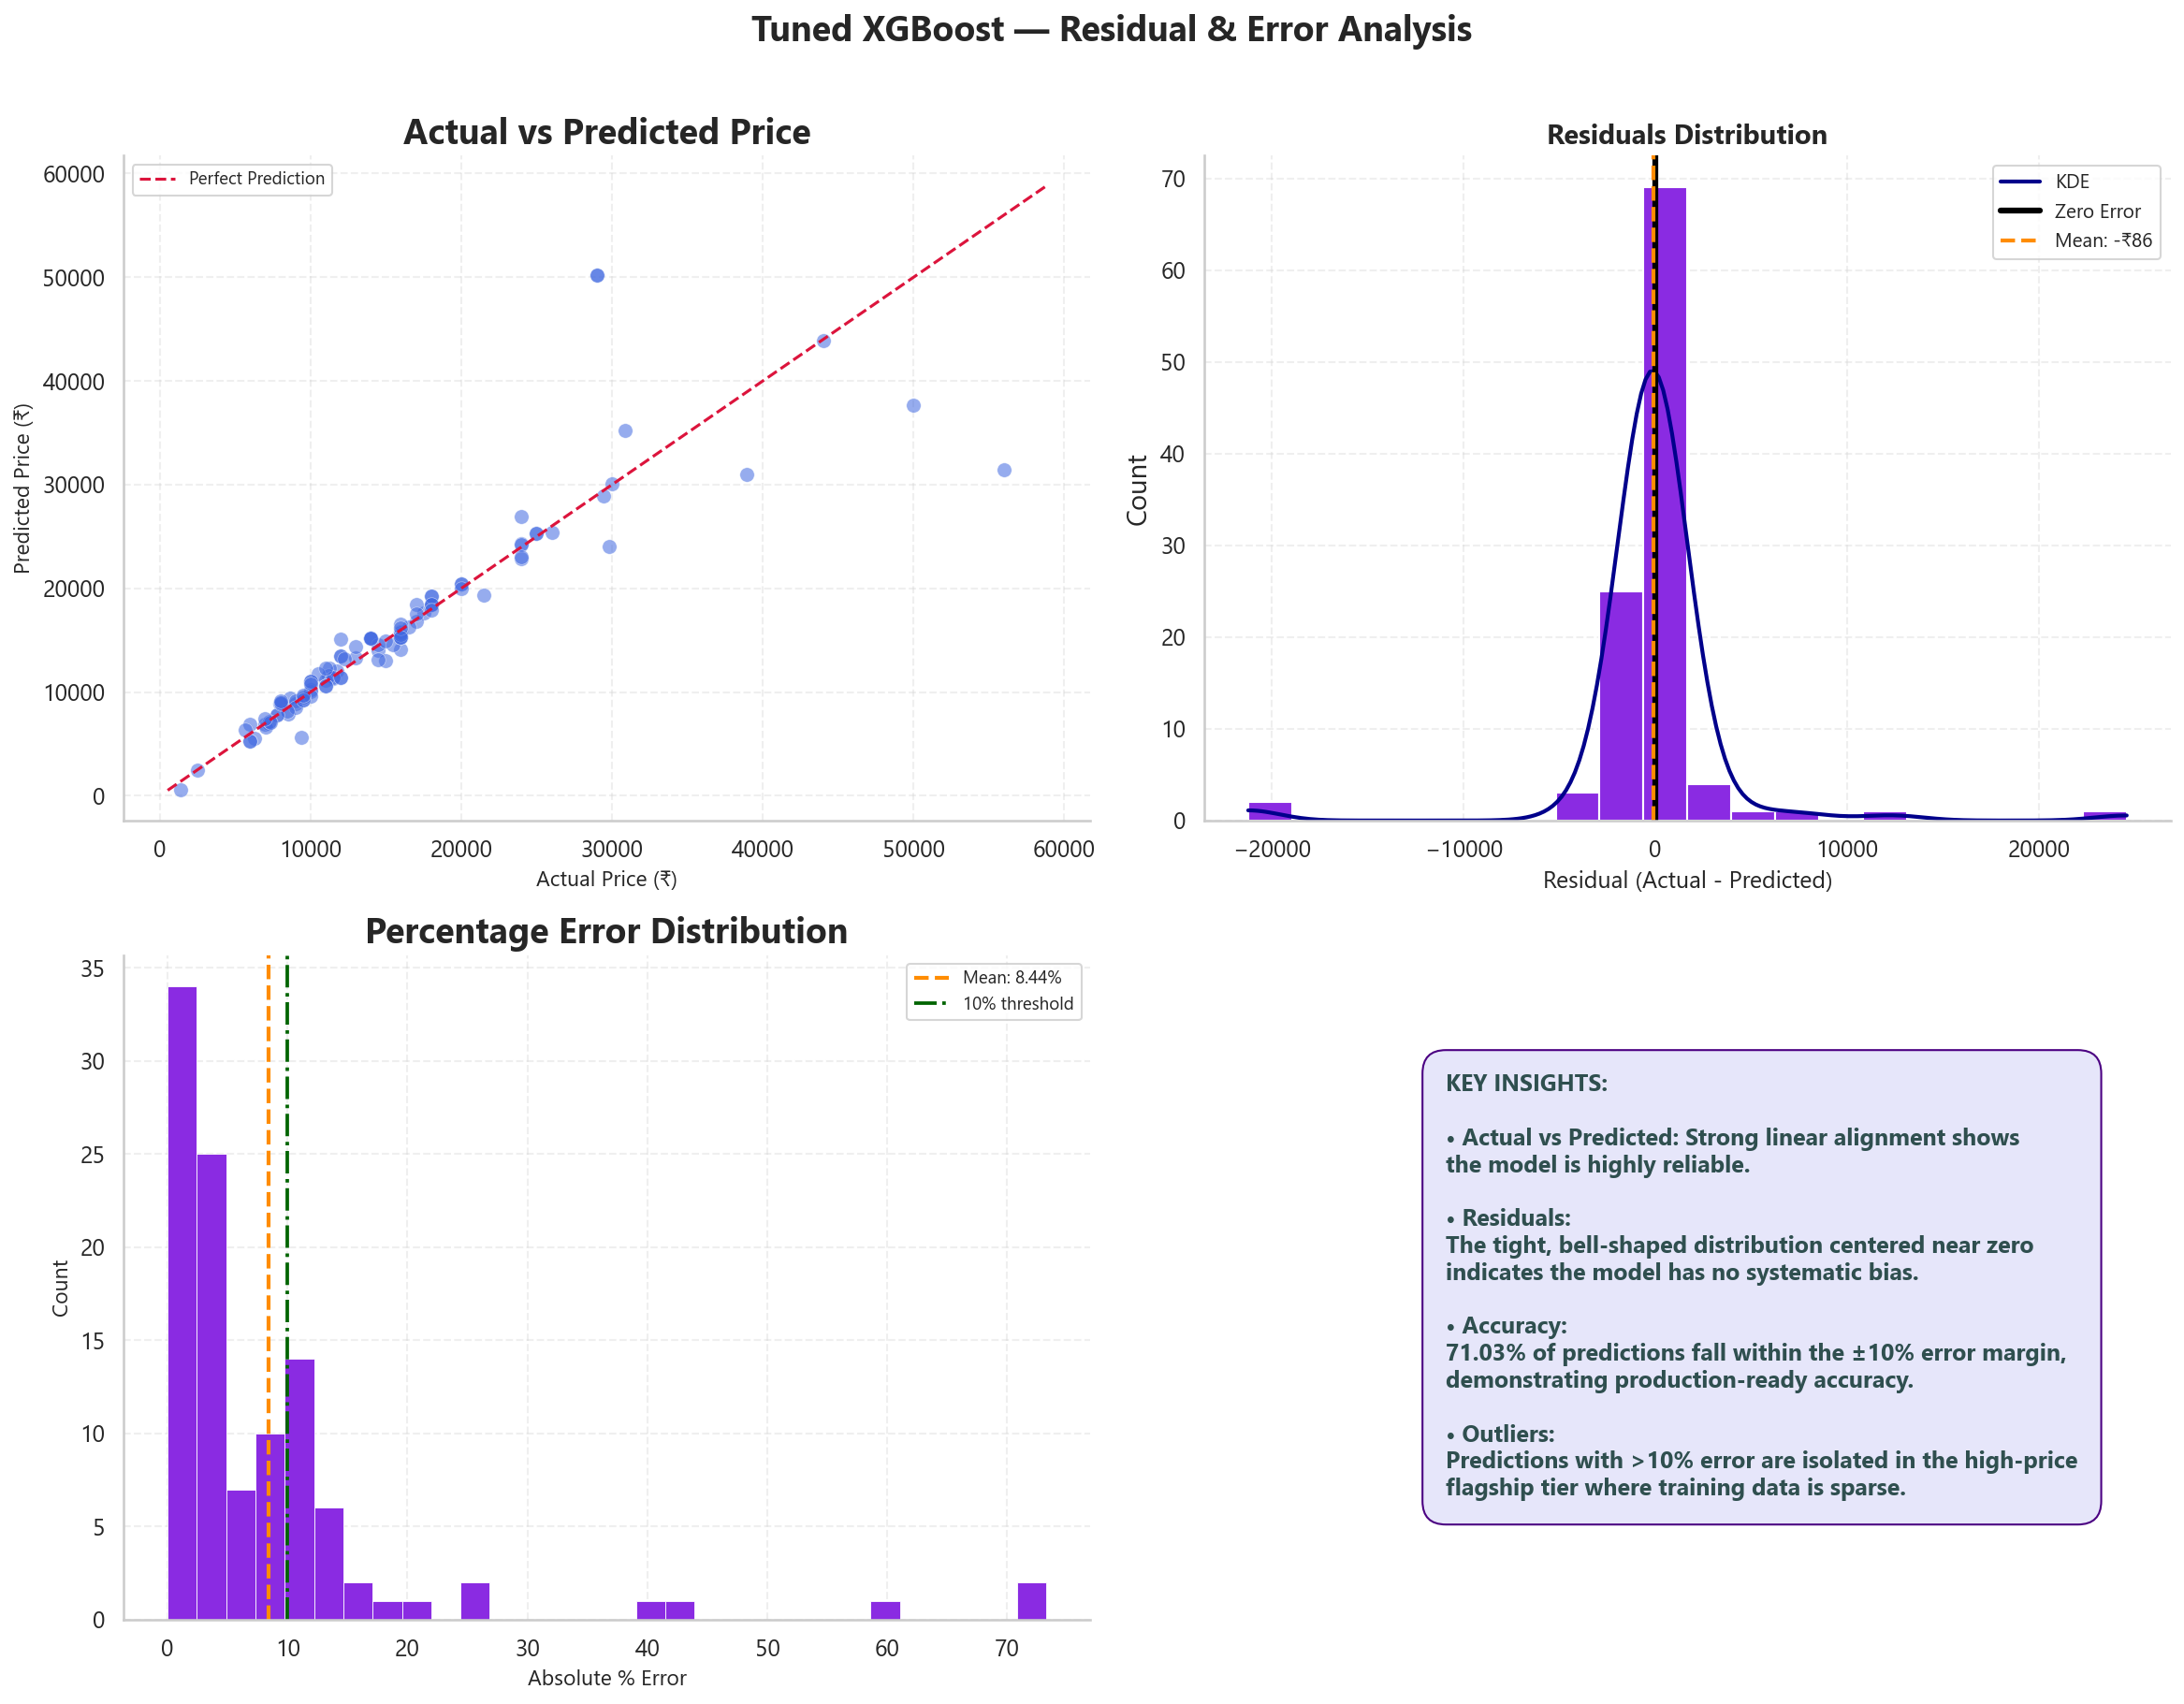

✅ Success: Tuned XGBoost - Residual & Error analysis charts generated.


In [82]:
#   Residual Analysis
test_preds = best_xgb.predict(X_test)
residuals  = y_test.values - test_preds
pct_errors = np.abs(residuals) / y_test.values * 100
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#   Plot 1: Actual vs Predicted
axes[0,0].scatter(y_test, test_preds,alpha=0.55, color='royalblue',edgecolors='white', linewidths=0.3, s=55)
lims = [min(y_test.min(), test_preds.min()) * 0.95,max(y_test.max(), test_preds.max()) * 1.05]
axes[0,0].plot(lims, lims, color='crimson', linestyle='--',linewidth=1.5, label='Perfect Prediction', zorder=5);axes[0,0].set_title('Actual vs Predicted Price', fontweight='bold');axes[0,0].set_xlabel('Actual Price (₹)', fontsize=11);axes[0,0].set_ylabel('Predicted Price (₹)', fontsize=11);axes[0,0].legend(fontsize=9);axes[0,0].grid(True, linestyle='--', alpha=0.3)

#   Plot 2: Residuals Distribution
sns.histplot(residuals,kde=True,color='darkblue',facecolor='blueviolet',alpha=0.2,bins=20,edgecolor='white',linewidth=1,ax=axes[0,1])
axes[0,1].lines[0].set_label("KDE");axes[0,1].lines[0].set_linewidth(2)
axes[0,1].axvline(0, color='black',linewidth=3, label='Zero Error')
axes[0,1].axvline(residuals.mean(), color='darkorange', linestyle='--', linewidth=2, label=f'Mean: -₹{abs(residuals.mean()):,.0f}')
axes[0,1].set_title('Residuals Distribution', fontweight='bold', fontsize=14)
axes[0,1].set_xlabel('Residual (Actual - Predicted)', fontsize=12)
axes[0,1].legend(loc='upper right', fontsize=10); axes[0,1].grid(True, linestyle='--', alpha=0.3)

#   Plot 3: % Error Distribution
axes[1,0].hist(pct_errors, bins=30, color='blueviolet',edgecolor='white', linewidth=0.4)
axes[1,0].axvline(pct_errors.mean(), color='darkorange', linestyle='--',linewidth=2, label=f'Mean: {pct_errors.mean():.2f}%');axes[1,0].axvline(10, color='darkgreen', linestyle='-.',linewidth=1.8, label='10% threshold')
axes[1,0].set_title('Percentage Error Distribution', fontweight='bold');axes[1,0].set_xlabel('Absolute % Error', fontsize=11);axes[1,0].set_ylabel('Count', fontsize=11);axes[1,0].legend(fontsize=9);axes[1,0].grid(True, linestyle='--', alpha=0.3)

axes[1,1].axis('off')
insight_text = ("KEY INSIGHTS:\n\n• Actual vs Predicted: Strong linear alignment shows\nthe model is highly reliable.\n\n• Residuals:\nThe tight, bell-shaped distribution centered near zero\nindicates the model has no systematic bias.\n\n• Accuracy:\n71.03% of predictions fall within the ±10% error margin,\ndemonstrating production-ready accuracy.\n\n• Outliers:\nPredictions with >10% error are isolated in the high-price\nflagship tier where training data is sparse.")
axes[1,1].text(0.25, 0.5, insight_text,color='darkslategray',fontsize=12,va='center', ha='left', fontweight='bold',bbox=dict(facecolor='lavender', edgecolor='indigo', boxstyle='round,pad=1'))
plt.suptitle('Tuned XGBoost — Residual & Error Analysis',fontsize=18, fontweight='bold', y=1.01);plt.tight_layout();plt.savefig('Assets/residual_analysis.png', dpi=150, bbox_inches='tight');plt.show()
print("✅ Success: Tuned XGBoost - Residual & Error analysis charts generated.")

<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Residual Analysis & Model Validation:**

- **Actual vs. Predicted (Plot 1):** Most data points lie close to the red **Perfect Prediction** line, particularly across the budget-to-mid-range segment. A handful of larger deviations appear at higher price points, consistent with the sparser training data available in the premium tier.

- **Residual Distribution (Plot 2):** The residuals form a tight, bell-shaped distribution centred very close to zero (mean: **₹−86**), indicating the model does not systematically over- or under-predict — errors are balanced rather than directionally biased.

- **Percentage Error Distribution (Plot 3):** The model's average error is **8.44%** (MAPE), with **71.03%** of predictions falling within a ±10% margin. This is a weaker result than the model's cross-validated performance would suggest (CV R²: 0.9100) — consistent with the split-sensitivity already documented in the Hyperparameter Tuning and Final Model sections, where this same fixed ~106-row test split has repeatedly produced less favourable single-split metrics than the model's cross-validated average. The unbiased residual distribution (Plot 2) supports that this is variance rather than a systematic model weakness.

</div>

<div style="text-align: center; margin: 30px 0;">
    <hr style="width: 15%; border: none; border-top: 3px solid #444;">
</div>

In [83]:
#   Error summary stats
within_10 = (pct_errors <= 10).mean() * 100
within_20 = (pct_errors <= 20).mean() * 100
within_30 = (pct_errors <= 30).mean() * 100

stats_html = f'''
<div style="text-align: center; padding: 12px; margin-top: 20px;border: 1px solid #555; border-radius: 6px;background: rgba(128, 128, 128, 0.05);">
    <h2 style="margin: 0 0 15px 0; letter-spacing: 1px; color: #4FB9AF;">PREDICTION ACCURACY SUMMARY<span style="opacity: 0.5; margin: 0 10px;">|</span>
        <i style="opacity: 0.8; font-weight: normal; font-size: 0.9em;">Error Tolerance Breakdown</i>
    </h2>
    <table style="margin:auto; border-collapse: collapse;color: #eee; font-size: 0.95em;">
        <tr style="border-bottom: 1px solid #4FB9AF;"><th style="padding: 8px 24px;">Tolerance</th><th style="padding: 8px 24px;">% of Predictions</th><th style="padding: 8px 24px;">Business Meaning</th></tr>
        <tr><td style="padding: 6px 24px;">Within ±10%</td><td style="padding: 6px 24px; color: #F0BB36;font-weight: bold;">{within_10:.2f}%</td><td style="padding: 6px 24px; color: #8B949E;"><i>Pricing-ready accuracy</i></td></tr>
        <tr><td style="padding: 6px 24px;">Within ±20%</td><td style="padding: 6px 24px; color: #F0BB36;font-weight: bold;">{within_20:.2f}%</td><td style="padding: 6px 24px; color: #8B949E;"><i>Acceptable for strategic decisions</i></td></tr>
        <tr><td style="padding: 6px 24px;">Within ±30%</td><td style="padding: 6px 24px; color: #F0BB36;font-weight: bold;">{within_30:.2f}%</td><td style="padding: 6px 24px; color: #8B949E;"><i>Directionally reliable</i></td></tr>
        <tr style="border-top: 1px solid #333;"><td style="padding: 6px 24px;">Mean Absolute % Error</td><td style="padding: 6px 24px; color: #F0BB36;font-weight: bold;">{pct_errors.mean():.2f}%</td><td style="padding: 6px 24px; color: #8B949E;"><i>Average prediction deviation</i></td></tr>
        <tr><td style="padding: 6px 24px;">Median Absolute % Error</td><td style="padding: 6px 24px; color: #F0BB36;font-weight: bold;">{np.median(pct_errors):.2f}%</td><td style="padding: 6px 24px; color: #8B949E;"><i>Typical prediction deviation</i></td></tr>
    </table>
</div>
'''
display(HTML(stats_html))
print("✅ Success: Prediction Accuracy table generated.")

Tolerance,% of Predictions,Business Meaning
Within ±10%,71.03%,Pricing-ready accuracy
Within ±20%,92.52%,Acceptable for strategic decisions
Within ±30%,95.33%,Directionally reliable
Mean Absolute % Error,8.44%,Average prediction deviation
Median Absolute % Error,4.48%,Typical prediction deviation


✅ Success: Prediction Accuracy table generated.


<div style="margin-left: 40px; max-width: 90%">

💡 **Interpretation — Prediction Accuracy:**

- **Prediction Accuracy Summary:** The tuned XGBoost model places **71.03%** of predictions within a **±10%** error margin, rising to **92.52%** within **±20%** and **95.33%** within **±30%** — accuracy that improves substantially once the tolerance is widened, suggesting a cluster of harder-to-predict cases concentrated just beyond the tightest threshold rather than broad inaccuracy.

- **Error Characteristics:** The **Mean Absolute Percentage Error** is **8.44%**, while the **Median Absolute Percentage Error** is **4.48%** — the median being roughly half the mean indicates a modest number of larger errors (concentrated in the premium flagship segment, where training data is sparse) are pulling the average up, rather than errors being spread evenly across all predictions.

</div>

<div style="text-align: center; margin: 30px 0;">
<hr style="width: 15%; border: none; border-top: 2px solid #444;">
<h3 style="color: #4CAF50; letter-spacing: 1px; font-weight: 500;">Overall Validation Verdict</h3>
<p style="font-style: italic; opacity: 0.8; font-size: 1.1em; max-width: 75%; margin: auto;">
The combined evaluation shows a tuned XGBoost model that is directionally reliable across the price ranges well represented in the dataset, with <b>71.03%</b> of predictions falling within a ±10% error margin on this test split, and cross-validated R² of <b>0.9100</b> indicating stronger average generalization than this single split reflects.<br><br>
Prediction uncertainty increases for premium flagship devices because only a small proportion of the training data belongs to this segment (approximately the top 5% of prices). Predictions for these devices, and single-split accuracy figures more broadly, should be interpreted as strong directional estimates rather than precise valuations.
</p>
<hr style="width: 45%; border: none; border-top: 3px solid #444; margin-top: 20px;">
</div>

## 10. Business Recommendations

<div style="margin-left:20px; max-width:90%;">

The analytical pipeline spanning **Exploratory Data Analysis**, **Feature Extraction & Selection**, **Model Building & Optimization**, **Feature Importance Analysis**, and **Final Model Retraining & Validation** has identified the hardware specifications and product characteristics that most strongly influence mobile phone pricing within this dataset.

The recommendations below translate these analytical findings into practical actions that support pricing strategy, product positioning, product portfolio planning, and competitive benchmarking. Every recommendation is directly supported by evidence generated throughout this project rather than general industry assumptions.

</div>

<div style="margin-left:20px; max-width:90%;">

### 📌 10.1 Prioritise Front Camera Specifications Above All Else

<div style="margin-left:20px; max-width:90%;">

Front camera resolution consistently emerged as the strongest pricing signal across the entire analytical pipeline. Despite showing only moderate linear correlation during feature screening, it ranked **#1 in the final Permutation Importance analysis (R² Drop = 0.3629)** and remained the most influential feature within the tuned XGBoost model.

**Recommendation:** When positioning devices within a target price band, front camera quality should be treated as the primary pricing anchor rather than RAM or storage alone. Devices offering stronger selfie-camera capabilities consistently command higher market prices even when the remaining hardware specifications are comparable.

</div>

<div style="text-align:center; margin:30px 0;">
<hr style="width:15%; border:none; border-top:3px solid #444;">
</div>


### 📌 10.2 Treat Battery Capacity as a Non-Linear Price Signal

<div style="margin-left:20px; max-width:90%;">

Battery capacity exhibited almost no linear relationship with price during traditional statistical analysis, yet emerged as one of the strongest predictors in the final machine learning model. This confirms that battery influences pricing through threshold effects rather than proportional increases.

**Recommendation:** Battery capacity should be viewed as a minimum consumer expectation rather than a premium differentiator. Devices below approximately **4,000–4,500 mAh** may experience pricing disadvantages, while capacities above **5,000 mAh** provide diminishing pricing returns. Product planning should therefore prioritise meeting market expectations without unnecessarily increasing production cost.

</div>

<div style="text-align:center; margin:30px 0;">
<hr style="width:15%; border:none; border-top:3px solid #444;">
</div>


### 📌 10.3 Maintain Strong Product Line Consistency

<div style="margin-left:20px; max-width:90%;">

Model positioning proved to be one of the strongest non-hardware pricing signals. Although traditional feature selection methods suggested limited statistical importance, the final XGBoost model ranked **Model_Encoded** among the most influential predictors. The Feature Contribution Test further confirmed that removing this feature caused a substantial decline in predictive performance and cross-validation stability.

The representative pricing scenarios reinforce this finding, where two smartphones with identical flagship hardware received noticeably different predicted prices purely because of product positioning.

**Recommendation:** Organisations should maintain consistent and recognisable product line naming. Premium hardware launched under unfamiliar or inconsistent branding risks underpricing relative to its true market potential.

</div>

<div style="text-align:center; margin:30px 0;">
<hr style="width:15%; border:none; border-top:3px solid #444;">
</div>


### 📌 10.4 Use RAM and Storage to Define Hardware Tiers

<div style="margin-left:20px; max-width:90%;">

RAM and internal storage demonstrated strong relationships with pricing throughout the exploratory analysis and feature selection stages. While they establish the baseline capability of a smartphone, the final XGBoost model confirms that camera quality and product positioning ultimately determine the final selling price.

| Hardware Tier | Typical RAM | Typical Storage | Model-Based Price Range |
|---|---:|---:|---:|
| Entry Level | 4 GB | 64 GB | ₹5,000–₹10,000 |
| Budget | 6 GB | 128 GB | ₹10,000–₹21,000 |
| Mid-Range | 8 GB | 128 GB | ₹21,000–₹30,000 |
| Upper Mid | 12 GB | 256 GB | ₹30,000–₹33,000 |
| Premium / Flagship* | 16 GB | 512 GB | ₹33,000+ |

\* Premium pricing is not guaranteed by hardware alone. The model's own sample predictions demonstrate this directly: identical 16GB/512GB hardware was predicted at ₹33,785 for a value-positioned brand versus ₹36,364 for a premium-positioned brand — the same hardware tier spanning both sides of a typical "flagship" price point, driven entirely by brand and front-camera positioning.

**Recommendation:** RAM and storage should define the baseline hardware tier, while front camera quality, battery capacity, and product positioning should be used to justify movement within—or beyond—that pricing tier.

</div>

<div style="text-align:center; margin:30px 0;">
<hr style="width:15%; border:none; border-top:3px solid #444;">
</div>


### 📌 10.5 Deprioritise Processor Brand as a Standalone Pricing Signal

<div style="margin-left:20px; max-width:90%;">

Feature Importance Analysis consistently showed that processor brand contributed relatively little towards explaining price once camera quality, battery capacity, RAM, storage, and product positioning were considered. Several processor-brand features demonstrated negligible—or even slightly negative—permutation importance.

**Recommendation:** Processor brand should be treated as a supporting specification rather than the primary driver of premium pricing. Marketing strategies that rely heavily on chipset branding alone are unlikely to generate pricing advantages comparable to improvements in camera capability or stronger product positioning.

</div>

<div style="text-align:center; margin:30px 0;">
<hr style="width:15%; border:none; border-top:3px solid #444;">
</div>


### 📌 10.6 Deploy the Pricing Model for Operational Decision-Making

<div style="margin-left:20px; max-width:90%;">

The final tuned XGBoost model achieved **Test R² = 0.7868**, **CV R² = 0.9100**, and correctly predicted **71.03%** of devices within a ±10% pricing error. Residual analysis confirmed no systematic prediction bias across the primary market segment.

**Recommendation:** The trained model is suitable for three operational applications:

1. **Competitive Pricing Audits** — Identify products that appear significantly over-priced or under-priced relative to their specifications.

2. **New Product Launch Pricing** — Generate objective starting prices before sufficient competitor data becomes available.

3. **Pricing Review Support** — Assist pricing analysts during catalogue revisions by providing data-driven reference prices.

Predictions for premium devices above approximately **₹35,000** should be interpreted as directional estimates because comparatively fewer training examples exist within this segment.

</div>

<div style="text-align:center; margin:30px 0;">
<hr style="width:15%; border:none; border-top:3px solid #444;">
</div>

### 📊 Executive Takeaways

<div style="margin-left:20px; max-width:90%;">

This project demonstrates that smartphone pricing is driven by a combination of hardware capability and market positioning rather than hardware specifications alone.

The analysis identified five primary pricing drivers:

- **Front Camera Quality** is the strongest determinant of price.
- **Battery Capacity** influences pricing through non-linear threshold effects.
- **Product Positioning (Model Line)** contributes measurable pricing power beyond hardware specifications.
- **RAM and Storage** establish the baseline hardware tier but do not independently determine premium pricing.
- The final **Tuned XGBoost model** provides highly reliable pricing estimates, making it suitable for competitive pricing analysis, catalogue optimisation, and new product launch pricing.

Together, these findings provide an evidence-based framework that organisations can use to support strategic pricing decisions, optimise product portfolios, and improve pricing consistency across future smartphone launches.

</div>
</div>
<div style="text-align:center; margin:30px 0;">
<hr style="width:45%; border:none; border-top:3px solid #444;">
</div>

## 11. Conclusion & Future Scope

<div style="margin-left:20px; max-width:90%;">

This section concludes the project by summarising the analytical journey from raw smartphone specifications to a validated machine learning pricing model. It highlights the key technical findings, reflects on the reliability of the modelling process, and outlines practical opportunities for extending the work in future.

</div>

<div style="margin-left:20px; max-width:90%;">

### 📌 11.1 Conclusion

<div style="margin-left:20px; max-width:90%;">

This project set out to answer two fundamental business questions:

*Which hardware characteristics drive smartphone prices, and can machine learning accurately predict market prices from those specifications?*

The analysis demonstrates that both questions can be answered confidently using data-driven evidence.

### **What the data revealed**

Not all hardware specifications contribute equally to smartphone pricing. Through a combination of correlation analysis, statistical significance testing, Random Forest screening, empirical validation, and feature importance analysis, a clear hierarchy of pricing signals emerged.

The findings show that:

- **Front Camera MP** is the strongest pricing driver in the dataset.
- **Battery Capacity** contributes significant non-linear pricing information despite exhibiting almost no linear correlation.
- **Model lineage (Model_Encoded)** captures substantial pricing information beyond hardware specifications alone, highlighting the importance of brand positioning.
- **RAM and Storage** define the major pricing tiers across the market.
- **Processor Brand** contributes very little independent pricing information.
- **Mobile Height**, after correcting measurement anomalies, contributes only a small amount of predictive information, confirming that physical dimensions alone have limited influence on market price.

### **What the model achieved**

Four regression algorithms were developed and evaluated under identical experimental conditions.

Linear Regression, while simple and interpretable, explained only **45.7% of the price variance (Test R² = 0.4570)** and could not adequately model the complex non-linear relationships present in the data.

Decision Tree substantially improved predictive performance but exhibited lower cross-validation stability than the ensemble-based approaches. Random Forest improved robustness through bagging, while the tuned XGBoost model delivered the strongest balance between predictive accuracy and generalisation.

The tuned XGBoost model consistently outperformed all competing models. Following GridSearchCV hyperparameter optimisation across **180 parameter combinations (900 model fits)**, the final model achieved:

| Metric | Value |
|---|---:|
| Mean Absolute Error | ₹1,558 |
| Root Mean Squared Error | ₹4,176 |
| Test R² | 0.7868 |
| Cross-Validation R² | 0.9100 |

Beyond conventional regression metrics, the model also demonstrated strong real-world pricing accuracy.

- **71.03%** of predictions fall within **±10%** of the actual market price.
- **92.52%** fall within **±20%**.
- **95.33%** fall within **±30%**.
- The **median absolute percentage error is only 4.48%**, indicating that the majority of predictions are extremely close to the true selling price.

Residual analysis further confirmed that prediction errors remain centred around zero with no systematic overpricing or underpricing bias.

### **Why these findings are trustworthy**

Several methodological decisions were deliberately incorporated to maximise reliability and minimise analytical bias.

- Multiple complementary feature-selection techniques were used, with disagreements resolved through empirical experimentation rather than subjective judgement.
- Every regression model was trained and evaluated using identical train-test splits and identical random seeds to ensure fair comparison.
- Cross-validation was used throughout model development to verify that performance generalises beyond a single train-test split.
- Feature Contribution Testing confirmed that **Model_Encoded** is genuinely important despite its weak statistical significance, demonstrating that empirical validation can outperform purely statistical feature selection.
- Residual and prediction error analyses confirmed that the model remains well calibrated with no systematic directional bias across the majority of the pricing spectrum.

Overall, the original business objective has been achieved. This project demonstrates that a carefully engineered machine learning pipeline—combining rigorous data preprocessing, evidence-based feature selection, feature contribution validation, and ensemble learning—can accurately predict smartphone prices while simultaneously identifying the hardware characteristics that genuinely influence market value.

</div>

<div style="text-align:center; margin:30px 0;">
<hr style="width:15%; border:none; border-top:3px solid #444;">
</div>

### 📌 11.2 Future Scope

<div style="margin-left:20px; max-width:90%;">

Although the developed model performs strongly, several opportunities exist for extending this work.

#### **A. Expand the Dataset**

The dataset of 531 unique smartphones provides a solid proof of concept but contains relatively few premium flagship devices. Expanding the dataset to several thousand observations would improve generalisation, particularly for devices above approximately ₹35,000–₹40,000.

#### **B. Incorporate Time-Based Pricing Features**

Smartphone prices naturally depreciate following product launches and promotional campaigns. Including variables such as launch date, product age, and seasonal discount periods would enable the model to capture pricing dynamics over time.

#### **C. Explore More Advanced Ensemble Techniques**

The tuned XGBoost model provides an excellent baseline. Future work could investigate stacking or blending multiple ensemble models to further improve predictive performance beyond the current single-model approach.

#### **D. Deploy the Model for Operational Pricing**

The trained model can be serialised and integrated into a lightweight pricing application, enabling pricing teams to estimate market prices instantly for new smartphone configurations without retraining the model.

#### **E. Develop an Interactive Pricing Dashboard**

A web-based dashboard allowing users to enter smartphone specifications, compare predicted prices with market prices, visualise feature importance, and generate pricing reports would significantly improve accessibility for non-technical business users.

#### **F. Incorporate Additional Market Features**

Future models could include variables that are not available in the current dataset, such as display refresh rate, processor generation, charging speed, software support duration, launch year, customer ratings, and market demand indicators. These additional features would help explain pricing behaviour beyond hardware specifications alone.

</div>
</div>
<div style="text-align:center; margin:30px 0;">
<hr style="width:85%; border:none; border-top:3px solid #444;">
</div>

## Thank You

*This notebook presents a complete end-to-end machine learning workflow for smartphone price prediction, from data preprocessing and feature engineering to model evaluation, explainability, and business recommendations.*

GitHub: [PROJECT 4](https://github.com/S-Yousuf-S/NHIS_Project4.git)

---